In [1]:
#first we want to import the different files, 311, ACS, and TIGER/Line files

#figure out, how to combine them, census tracts

import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Point

#Load ACS data
acs_data = pd.read_csv('nhgis0005_csv/nhgis0005_ds226_20165_tract.csv', low_memory=False)

#Load TIGER/Line shapefile
shapefile = gpd.read_file('tl_2016_36_tract/tl_2016_36_tract.shp')

#Load 311 data
df_311 = pd.read_csv('311_Service_Requests.csv', low_memory=False)

# Record data-pipeline counts for the final app metadata
data_audit = {
    'raw_311_rows': int(len(df_311)),
    'raw_acs_rows': int(len(acs_data)),
    'raw_tiger_tract_rows': int(len(shapefile))
}

In [2]:
#join total pop data from block group dataset to acs_data with socioeconomic data
#load total pop data
totalpop = pd.read_csv('nhgis0006_csv/nhgis0006_ds225_20165_tract.csv',usecols=['GEOID', 'AF2LE001'], low_memory=False)
totalpop = totalpop.drop(index=0)
totalpop = totalpop.reset_index(drop=True)

acs_data = acs_data.merge(
    totalpop,
    on='GEOID',
    how='left',
    validate='one_to_one'
)

In [3]:
medianincome = pd.read_csv('nhgis0007_csv/nhgis0007_ds225_20165_tract.csv',usecols=['GEOID', 'AF49E001'], low_memory=False)
medianincome = medianincome.drop(index=0)
medianincome = medianincome.reset_index(drop=True)

acs_data = acs_data.merge(
    medianincome,
    on='GEOID',
    how='left',
    validate='one_to_one'
)

In [4]:
#print(acs_data['AF49E001'])

In [5]:
#Clean ACS Data

#clean GEOID Data
#drop identifier row
acs_data = acs_data.drop(index=0)
acs_data = acs_data.reset_index(drop=True)


#Remove 14000US
acs_data.columns = acs_data.columns.str.strip()
acs_data['GEOID'] = acs_data['GEOID'].str.replace('14000US', '', regex=False)
acs_data['GEOID'] = acs_data['GEOID'].astype(str) 
acs_data['GEOID'] = acs_data['GEOID'].str.strip()

acs_data.dropna(axis=1, thresh=0.95 * len(acs_data), inplace=True)
acs_data = acs_data.reset_index(drop=True)
data_audit['acs_rows_after_identifier_row_removed'] = int(
    len(acs_data)
)

#print(acs_data['GEOID'])
#print(acs_data.isnull().sum().tolist())
#print(acs_data.columns.tolist())

In [6]:
#print(acs_data) 
#print(shapefile) 
nyc_acs = acs_data[acs_data['STATE'] == 'New York'] 
nyc_counties = ['Bronx County', 'New York County', 'Kings County', 'Richmond County', 'Queens County']
nyc_acs = nyc_acs[nyc_acs['COUNTY'].isin(nyc_counties)]
data_audit['nyc_acs_tract_rows_before_tiger_merge'] = int(
    len(nyc_acs)
)
nyc_county_fips = ['005', '047', '061', '081', '085']
shapefile = shapefile[shapefile['COUNTYFP'].isin(nyc_county_fips)]
nyc_acs = nyc_acs.reset_index(drop=True)
shapefile = shapefile.reset_index(drop=True)
print(nyc_acs['COUNTY'].unique()) #
print(shapefile['COUNTYFP'].unique())

acs_tiger = shapefile.merge(
    nyc_acs,
    on='GEOID',
    how='left',
    validate='one_to_one'
)

#generate all different types of complaint counts, then create extra columns to append to the dataset.

<StringArray>
[   'Bronx County',    'Kings County', 'New York County',   'Queens County',
 'Richmond County']
Length: 5, dtype: str
<StringArray>
['081', '047', '061', '005', '085']
Length: 5, dtype: str


In [7]:
if 'AF2LE001' in acs_tiger.columns:
    acs_tiger.rename(columns={
        'AF2LE001': 'Total_Population',
        'AGBTE001': 'White_Population',
        'AGBUE001': 'Black_Population',
        'AGB1E001': 'Hispanic_Population',
        'AGBWE001': 'Asian_Population',
        'AF49E001': 'Median_Household_Income'
    }, inplace=True)
else:
    print("Error")

#div by zero
acs_tiger['Total_Population'] = acs_tiger['Total_Population'].replace(0, np.nan)

for col in ['White_Population', 
            'Black_Population', 
            'Hispanic_Population',
            'Asian_Population',
            'AGBVE001',
            'AGBXE001',
            'AGBYE001',
            'AGBZE001',
            'Total_Population',
            'Median_Household_Income'
           ]:
    try:
        acs_tiger[col] = pd.to_numeric(acs_tiger[col], errors='coerce') 
    except:
        print(f"Error converting column {col}") 

#percentages
acs_tiger['Percent_White'] = acs_tiger['White_Population'] / acs_tiger['Total_Population']
acs_tiger['Percent_Black'] = acs_tiger['Black_Population'] / acs_tiger['Total_Population']
acs_tiger['Percent_Hispanic'] = acs_tiger['Hispanic_Population'] / acs_tiger['Total_Population']
acs_tiger['Percent_Asian'] = acs_tiger['Asian_Population'] / acs_tiger['Total_Population']
acs_tiger['Percent_Other'] = (acs_tiger['AGBVE001'] + acs_tiger['AGBXE001'] + acs_tiger['AGBYE001'] + acs_tiger['AGBZE001']) / acs_tiger['Total_Population']

In [8]:
#print(len(df_311['Latitude']))
#print(len(df_311['Longitude']))
#df_311 = df_311.dropna(subset=['Latitude', 'Longitude'])
#print(len(df_311['Latitude']))
#print(len(df_311['Longitude']))

# Convert Created Date to datetime using the source format
df_311['Created Date'] = pd.to_datetime(
    df_311['Created Date'],
    format='%m/%d/%Y %I:%M:%S %p',
    errors='coerce'
)

data_audit['requests_with_parseable_created_date'] = int(
    df_311['Created Date'].notna().sum()
)

# Keep the 2016 research snapshot
df_311 = df_311[
    df_311['Created Date'].dt.year == 2016
].copy()

data_audit['requests_2016'] = int(
    len(df_311)
)

# Convert latitude and longitude to numeric values
df_311['Latitude'] = pd.to_numeric(
    df_311['Latitude'],
    errors='coerce'
)

df_311['Longitude'] = pd.to_numeric(
    df_311['Longitude'],
    errors='coerce'
)

data_audit['requests_2016_missing_coordinates'] = int(
    df_311[
        ['Latitude', 'Longitude']
    ].isna().any(axis=1).sum()
)

# The spatial analysis requires valid coordinates
df_311 = df_311.dropna(
    subset=['Latitude', 'Longitude']
).copy()

data_audit['requests_2016_with_valid_coordinates'] = int(
    len(df_311)
)

#print(len(df_311['Latitude']))
#print(len(df_311['Longitude']))


In [9]:
#print(df_311['Complaint Type'].unique())

#define a mapping for the complaint categories
complaint_categories = {
    'Noise Complaints': [
        'Noise - Residential', 'Noise - Commercial', 'Noise', 'Noise - House of Worship',
        'Noise - Park', 'Noise - Street/Sidewalk', 'Noise - Vehicle', 'Noise - Helicopter',
        'Collection Truck Noise'
    ],
    'Housing and Building Complaints': [
        'HEAT/HOT WATER', 'PAINT/PLASTER', 'UNSANITARY CONDITION', 'WATER LEAK',
        'PLUMBING', 'Electrical', 'ELEVATOR', 'Lead', 'MOLD', 'Indoor Air Quality',
        'Indoor Sewage', 'APPLIANCE', 'DOOR/WINDOW', 'FLOORING/STAIRS', 'Building/Use',
        'Building Condition', 'Boilers', 'Non-Residential Heat', 'Vacant Lot',
        'Construction', 'General Construction/Plumbing', 'BEST/Site Safety',
        'Scaffold Safety', 'Asbestos/Garbage Nuisance', 'Asbestos', 'Building Marshals office',
        'Interior Demo', 'Facades', 'Special Projects Inspection Team (SPIT)', 'Mold', 'OUTSIDE BUILDING',
        'Elevator', 'ELECTRIC','Plumbing', 'DRIE', 'Window Guard', 'Tanning', 'VACANT APARTMENT'
        
    ],
    'Sanitation and Environmental Complaints': [
        'Dirty Conditions', 'Sanitation Condition', 'Overflowing Litter Baskets',
        'Overflowing Recycling Baskets', 'Hazardous Materials', 'Air Quality',
        'Water Quality', 'Water System', 'Sewer', 'Industrial Waste', 'Rodent',
        'Unsanitary Pigeon Condition', 'Animal Abuse', 'Animal Facility - No Permit',
        'Unsanitary Animal Pvt Property', 'Unsanitary Animal Facility', 'Dead/Dying Tree',
        'Dead Tree', 'Damaged Tree', 'Illegal Tree Damage', 'Root/Sewer/Sidewalk Condition',
        'Water Conservation', 'Standing Water', 'Poison Ivy', 'Smoking', 'Harboring Bees/Wasps',
        'Mosquitoes', 'Food Poisoning', 'Food Establishment', 'Calorie Labeling', 'Trans Fat', 
        'Missed Collection (All Materials)', 'Drinking Water', 'Sustainability Enforcement', 
        'Adopt-A-Basket', 'Tattooing', 'Beach/Pool/Sauna Complaint', 'Bottled Water',
        'Radioactive Material', 'LEAD','Trapping Pigeon'
        
    ],
    'Street and Infrastructure Complaints': [
        'Illegal Parking', 'Blocked Driveway', 'Derelict Vehicle', 'Derelict Vehicles',
        'Derelict Bicycle', 'Traffic Signal Condition', 'Street Condition',
        'Street Light Condition', 'Sidewalk Condition', 'Street Sign - Dangling',
        'Street Sign - Damaged', 'Street Sign - Missing', 'Broken Muni Meter',
        'Broken Parking Meter', 'Curb Condition', 'Overgrown Tree/Branches',
        'New Tree Request', 'Highway Condition', 'Bridge Condition', 'Bus Stop Shelter Complaint',
        'Bus Stop Shelter Placement', 'Bike Rack Condition', 'Bike/Roller/Skate Chronic',
        'Traffic', 'LinkNYC', 'Snow', 'Plant', 'Municipal Parking Facility',
        'Litter Basket / Request', 'Electronics Waste', 'Transportation Provider Complaint',
        'Construction Safety Enforcement', 'Street Sign', 'Cranes and Derricks', 'Stalled Sites',
        'Maintenance or Facility', 'Sweeping/Missed', 'Sweeping/Inadequate', 'City Vehicle Placard Complaint',
        'Posting Advertisement', 'Special Natural Area District (SNAD)', 'SRDE', 'OEM Disabled Vehicle', 
        'Request Xmas Tree Collection'
        
    ],
    'Public Safety and Quality of Life Complaints': [
        'Drug Activity', 'Non-Emergency Police Matter', 'Homeless Person Assistance',
        'Homeless Encampment', 'Panhandling', 'Disorderly Youth', 'Urinating in Public',
        'Public Payphone Complaint', 'Vending', 'For Hire Vehicle Report',
        'For Hire Vehicle Complaint', 'Taxi Complaint', 'Taxi Report', 'Unleashed Dog',
        'Squeegee', 'Illegal Animal Kept as Pet', 'Illegal Animal Sold', 'Quality of Life',
        'Illegal Fireworks', 'Violation of Park Rules', 'Animal in a Park', 'DPR Internal',
        'Recycling Enforcement', 'Public Toilet', 'Graffiti', 'Other Enforcement', 'Consumer Complaint',
        'GENERAL', 'SAFETY', 'School Maintenance', 'Drinking','Emergency Response Team (ERT)', 
        'Investigations and Discipline (IAD)', 'Senior Center Complaint', 'Miscellaneous Categories', 
        'FATF', 'Day Care', 'ATF', 'Found Property', 'Taxpayer Advocate Inquiry', 'Advocate-Commercial Exemptions',
        'Lifeguard', 'Literature Request','Legal Services Provider Complaint', 'Advocate-Business Tax', 
        'Forensic Engineering', 'X-Ray Machine/Equipment', 'ZTESTINT', 'AGENCY', 'Advocate-UBT', 'Advocate - Other'
    ]
}

def map_complaint_category(complaint_type):
    for category, types in complaint_categories.items():
        if complaint_type in types:
            return category
    return 'OtherComplaints'  #uncategorized, if any 

df_311['Complaint Category'] = df_311['Complaint Type'].apply(map_complaint_category)
data_audit['requests_classified_into_five_domains'] = int(
    (
        df_311['Complaint Category']
        != 'OtherComplaints'
    ).sum()
)

data_audit['requests_classified_as_other'] = int(
    (
        df_311['Complaint Category']
        == 'OtherComplaints'
    ).sum()
)

data_audit['complaint_types_observed'] = int(
    df_311['Complaint Type'].nunique()
)

data_audit['complaint_types_mapped_to_five_domains'] = int(
    df_311.loc[
        df_311['Complaint Category']
        != 'OtherComplaints',
        'Complaint Type'
    ].nunique()
)

In [10]:
#create geometry column
geometry = [Point(xy) for xy in zip(df_311['Longitude'], df_311['Latitude'])]
gdf_311 = gpd.GeoDataFrame(df_311, geometry=geometry)

#print(acs_tiger.crs)
#print(gdf_311.crs)

#set crs to acs_tiger crs
gdf_311 = gdf_311.set_crs("EPSG:4326")
gdf_311 = gdf_311.to_crs(acs_tiger.crs)

gdf_merged = gpd.sjoin(gdf_311, acs_tiger, how='left', predicate='within')
#gdf_merged = gpd.sjoin(gdf_311, acs_tiger, how='left')
#gdf_merged = gdf_merged[gdf_merged.geometry.within(acs_tiger.unary_union)]

# Record spatial-join coverage before unmatched requests
# are removed.

data_audit[
    'requests_spatially_matched_to_tract'
] = int(
    gdf_merged['GEOID']
    .notna()
    .sum()
)


data_audit[
    'requests_not_matched_to_tract'
] = int(
    gdf_merged['GEOID']
    .isna()
    .sum()
)


# request should not appear more than once after tract join

if not gdf_merged.index.is_unique:
    raise ValueError(
        "The spatial join duplicated one or more requests. "
        "Inspect tract geometry before continuing."
    )

In [11]:
#make sure 'GEOID' is not null
gdf_merged = gdf_merged.dropna(subset=['GEOID'])
data_audit['requests_retained_after_spatial_match'] = int(
    len(gdf_merged)
)

#group by GEOID and Complaint Category
complaints_by_tract = gdf_merged.groupby(['GEOID', 'Complaint Category']).size().reset_index(name='Complaint_Count')

#pivot data to have complaint categories as columns
complaints_pivot = complaints_by_tract.pivot(index='GEOID', columns='Complaint Category', values='Complaint_Count').fillna(0)
complaints_pivot = complaints_pivot.reset_index()

In [12]:
#merge back with acs_tiger
acs_tiger = acs_tiger.merge(
    complaints_pivot,
    on='GEOID',
    how='left',
    validate='one_to_one'
)

#fill NaN for 0 if any
complaint_categories_list = list(complaint_categories.keys())
acs_tiger[complaint_categories_list] = acs_tiger[complaint_categories_list].fillna(0)

In [13]:
# ---------------------------------------------------------
# TRACT COMPLAINT RATES AND ALLOCATION POPULATION FILTER
# ---------------------------------------------------------
#
# Keep two tract datasets from this point forward:
#
#   acs_tiger_all_tracts
#       All NYC tracts for map display and context
#
#   acs_tiger
#       Population-filtered tract universe used by the
#       downstream analysis and allocation model
#
# This allows low-population tracts to remain visible on
# the final map without allowing unstable per-capita rates
# to drive the prioritization model
# ---------------------------------------------------------


# Replace invalid zero values with missing values
#
# Population = 0 cannot be used as the denominator of a
# per-capita complaint rate
#
# Income = 0 in this source is treated as unavailable rather
# than as a literal $0 median household income

acs_tiger['Total_Population'] = (
    acs_tiger['Total_Population']
    .replace(0, np.nan)
)

acs_tiger['Median_Household_Income'] = (
    acs_tiger['Median_Household_Income']
    .replace(0, np.nan)
)


# Define the complaint-rate fields 

rate_cols = [
    f"{category}_Per_1000_People"
    for category in complaint_categories_list
]


# Calculate tract complaint rates BEFORE applying the
# allocation population threshold
#
# This preserves analytical values for all tracts that can
# validly support a per-capita rate, including low-population
# tracts that will remain visible but allocation-ineligible

for category in complaint_categories_list:

    acs_tiger[
        f'{category}_Per_1000_People'
    ] = (
        acs_tiger[category]
        / acs_tiger['Total_Population']
        * 1000
    )


# Preserve missing values and remove infinities.

acs_tiger.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True,
)


# ---------------------------------------------------------
# PRESERVE THE COMPLETE MAP GEOGRAPHY
# ---------------------------------------------------------

acs_tiger_all_tracts = (
    acs_tiger.copy()
)


data_audit['all_map_tracts'] = int(
    len(acs_tiger_all_tracts)
)


# ---------------------------------------------------------
# APPLY THE ALLOCATION POPULATION THRESHOLD
# ---------------------------------------------------------

population_threshold = 500


data_audit['tracts_before_population_filter'] = int(
    len(acs_tiger)
)


acs_tiger = (
    acs_tiger.loc[
        acs_tiger['Total_Population']
        >= population_threshold
    ]
    .copy()
)


data_audit['tracts_after_population_filter'] = int(
    len(acs_tiger)
)


data_audit['tracts_removed_by_population_filter'] = int(
    data_audit['tracts_before_population_filter']
    - data_audit['tracts_after_population_filter']
)


data_audit['population_threshold'] = int(
    population_threshold
)


# For the filtered analysis universe, a missing complaint
# rate means no recorded complaints after the earlier count
# preparation. Zero-fill complaint-rate fields only
#
# Do not zero-fill socioeconomic or demographic variables

acs_tiger[rate_cols] = (
    acs_tiger[rate_cols]
    .fillna(0)
)


# ---------------------------------------------------------
# VALIDATE THE TWO-UNIVERSE STRUCTURE
# ---------------------------------------------------------

assert (
    len(acs_tiger_all_tracts)
    ==
    data_audit['tracts_before_population_filter']
)


assert (
    len(acs_tiger)
    ==
    data_audit['tracts_after_population_filter']
)


assert set(
    acs_tiger['GEOID'].astype(str)
).issubset(
    set(
        acs_tiger_all_tracts[
            'GEOID'
        ].astype(str)
    )
)


assert (
    acs_tiger[rate_cols]
    .isna()
    .sum()
    .sum()
    ==
    0
)


print(
    "All map tracts:",
    len(acs_tiger_all_tracts)
)

print(
    "Population-filtered analysis tracts:",
    len(acs_tiger)
)

print(
    "Visible but population-ineligible tracts:",
    (
        len(acs_tiger_all_tracts)
        - len(acs_tiger)
    )
)

All map tracts: 2167
Population-filtered analysis tracts: 2099
Visible but population-ineligible tracts: 68


In [15]:
#data for all complaint categories
for category in complaint_categories_list:
    column_name = f"{category}_Per_1000_People"
    if column_name in acs_tiger.columns:
        #calculate min and max
        min_value = acs_tiger[column_name].min()
        max_value = acs_tiger[column_name].max()
        print(f"Range of {category} per 1,000 People: {min_value} to {max_value}")
        
        #print summary statistics
        print(acs_tiger[column_name].describe())
        print("\n")  
    else:
        print(f"{column_name} not found in the dataset.")

Range of Noise Complaints per 1,000 People: 0.0 to 1016.20029455081
count    2099.000000
mean       47.617319
std        54.429292
min         0.000000
25%        18.275664
50%        32.752501
75%        58.710018
max      1016.200295
Name: Noise Complaints_Per_1000_People, dtype: float64


Range of Housing and Building Complaints per 1,000 People: 0.0 to 742.3277359583093
count    2099.000000
mean       74.575824
std        68.477276
min         0.000000
25%        27.523545
50%        51.177904
75%       100.975148
max       742.327736
Name: Housing and Building Complaints_Per_1000_People, dtype: float64


Range of Sanitation and Environmental Complaints per 1,000 People: 0.7996801279488205 to 260.13513513513516
count    2099.000000
mean       44.179278
std        25.420325
min         0.799680
25%        26.830867
50%        39.607843
75%        56.434513
max       260.135135
Name: Sanitation and Environmental Complaints_Per_1000_People, dtype: float64


Range of Street and Infrast

In [16]:

acs_tiger['Noise Complaints_Per_1000_People'] = pd.to_numeric(acs_tiger['Noise Complaints_Per_1000_People'], errors='coerce')
acs_tiger['Housing and Building Complaints_Per_1000_People'] = pd.to_numeric(acs_tiger['Housing and Building Complaints_Per_1000_People'], errors='coerce')
acs_tiger['Sanitation and Environmental Complaints_Per_1000_People'] = pd.to_numeric(acs_tiger['Sanitation and Environmental Complaints_Per_1000_People'], errors='coerce')
acs_tiger['Street and Infrastructure Complaints_Per_1000_People'] = pd.to_numeric(acs_tiger['Street and Infrastructure Complaints_Per_1000_People'], errors='coerce')
acs_tiger['Public Safety and Quality of Life Complaints_Per_1000_People'] = pd.to_numeric(acs_tiger['Public Safety and Quality of Life Complaints_Per_1000_People'], errors='coerce')


acs_tiger['Noise Complaints_Per_1000_PeopleCLIP'] = acs_tiger['Noise Complaints_Per_1000_People'].clip(upper=400)
acs_tiger['Housing and Building Complaints_Per_1000_PeopleCLIP'] = acs_tiger['Housing and Building Complaints_Per_1000_People'].clip(upper=400)
acs_tiger['Sanitation and Environmental Complaints_Per_1000_PeopleCLIP'] = acs_tiger['Sanitation and Environmental Complaints_Per_1000_People'].clip(upper=400)
acs_tiger['Street and Infrastructure Complaints_Per_1000_PeopleCLIP'] = acs_tiger['Street and Infrastructure Complaints_Per_1000_People'].clip(upper=400)
acs_tiger['Public Safety and Quality of Life Complaints_Per_1000_PeopleCLIP'] = acs_tiger['Public Safety and Quality of Life Complaints_Per_1000_People'].clip(upper=400)


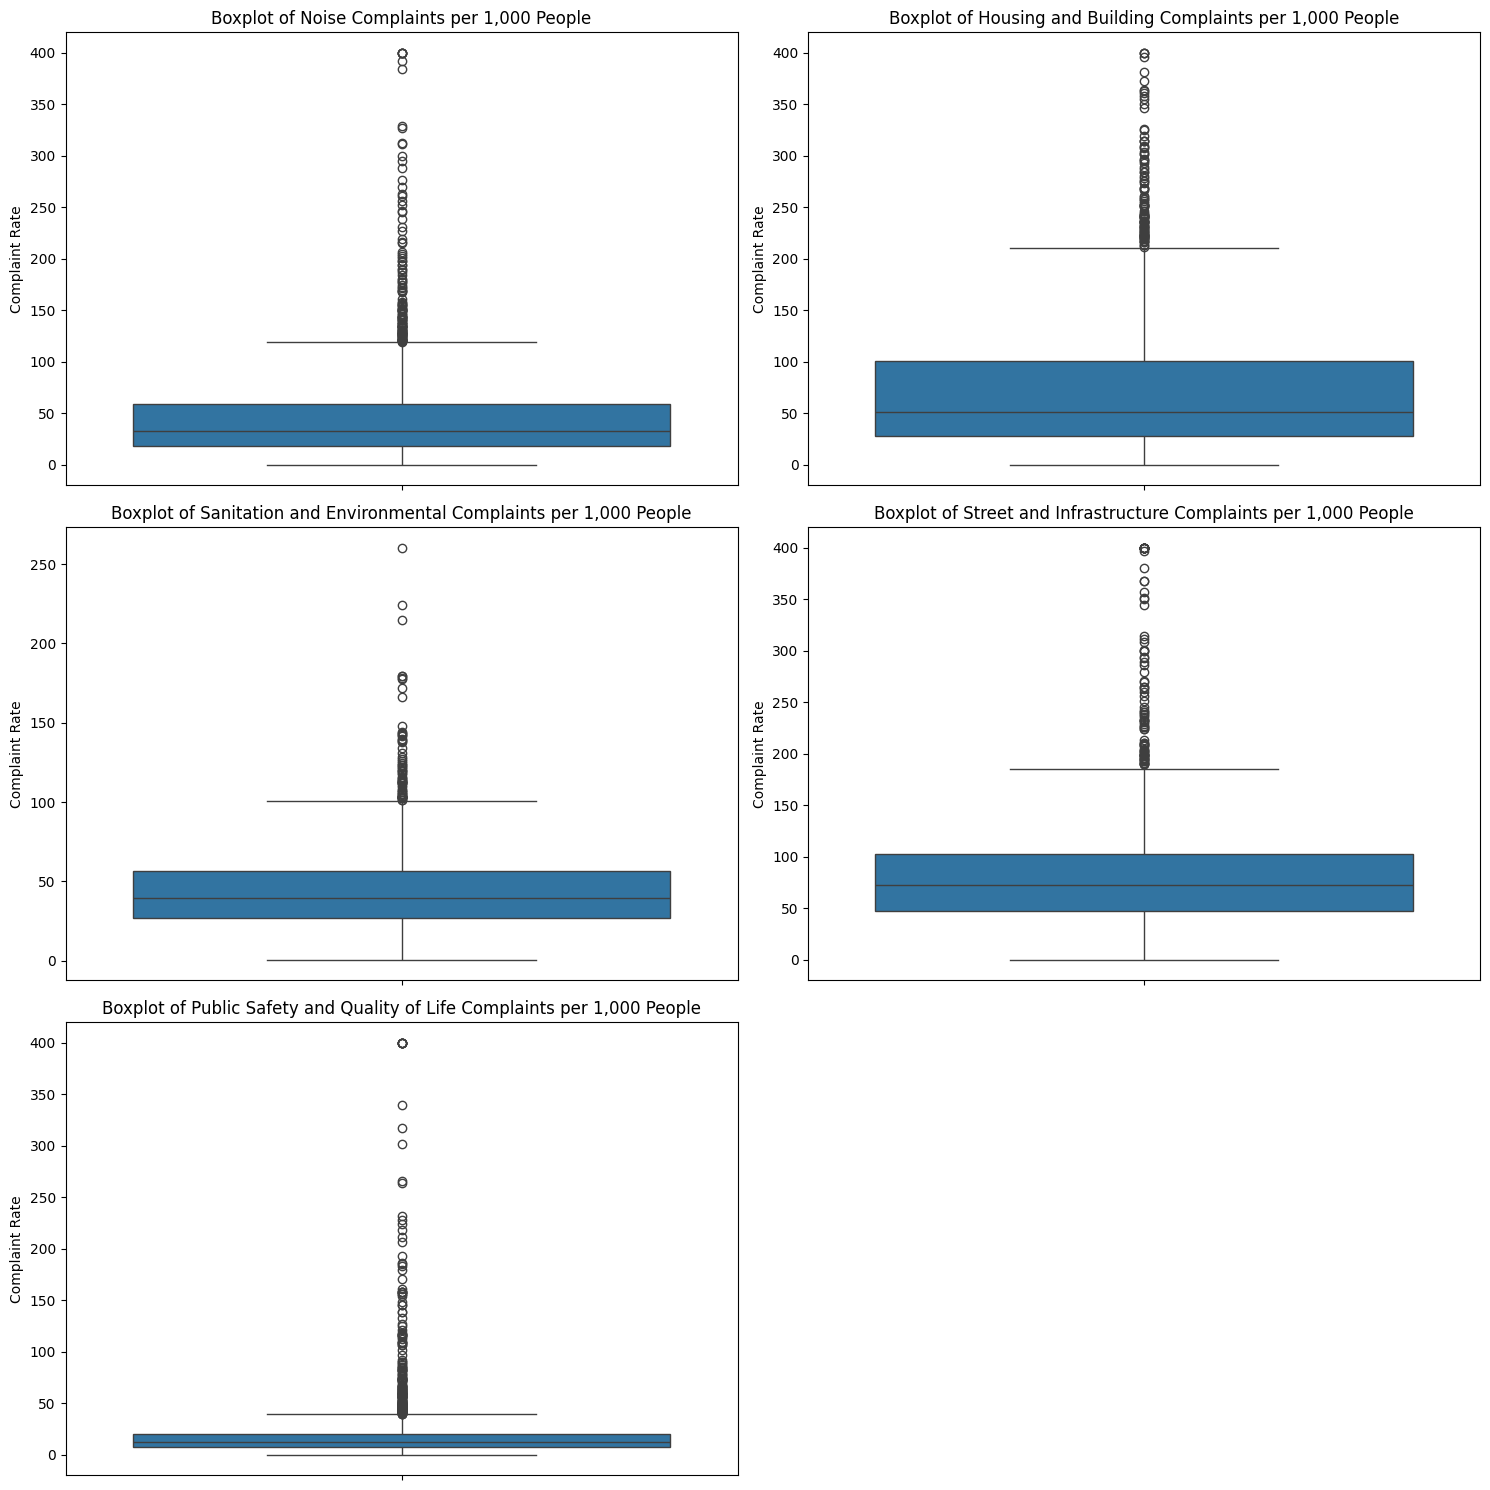

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

n_categories = len(complaint_categories_list)
n_cols = 2
n_rows = (n_categories + 1) // n_cols  


fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten() 


for i, category in enumerate(complaint_categories_list):
    column_name = f'{category}_Per_1000_PeopleCLIP'
    sns.boxplot(y=acs_tiger[column_name], ax=axes[i])
    axes[i].set_title(f'Boxplot of {category} per 1,000 People')
    axes[i].set_ylabel('Complaint Rate')


for j in range(i + 1, len(axes)):
    axes[j].axis('off')


plt.tight_layout()
plt.show()

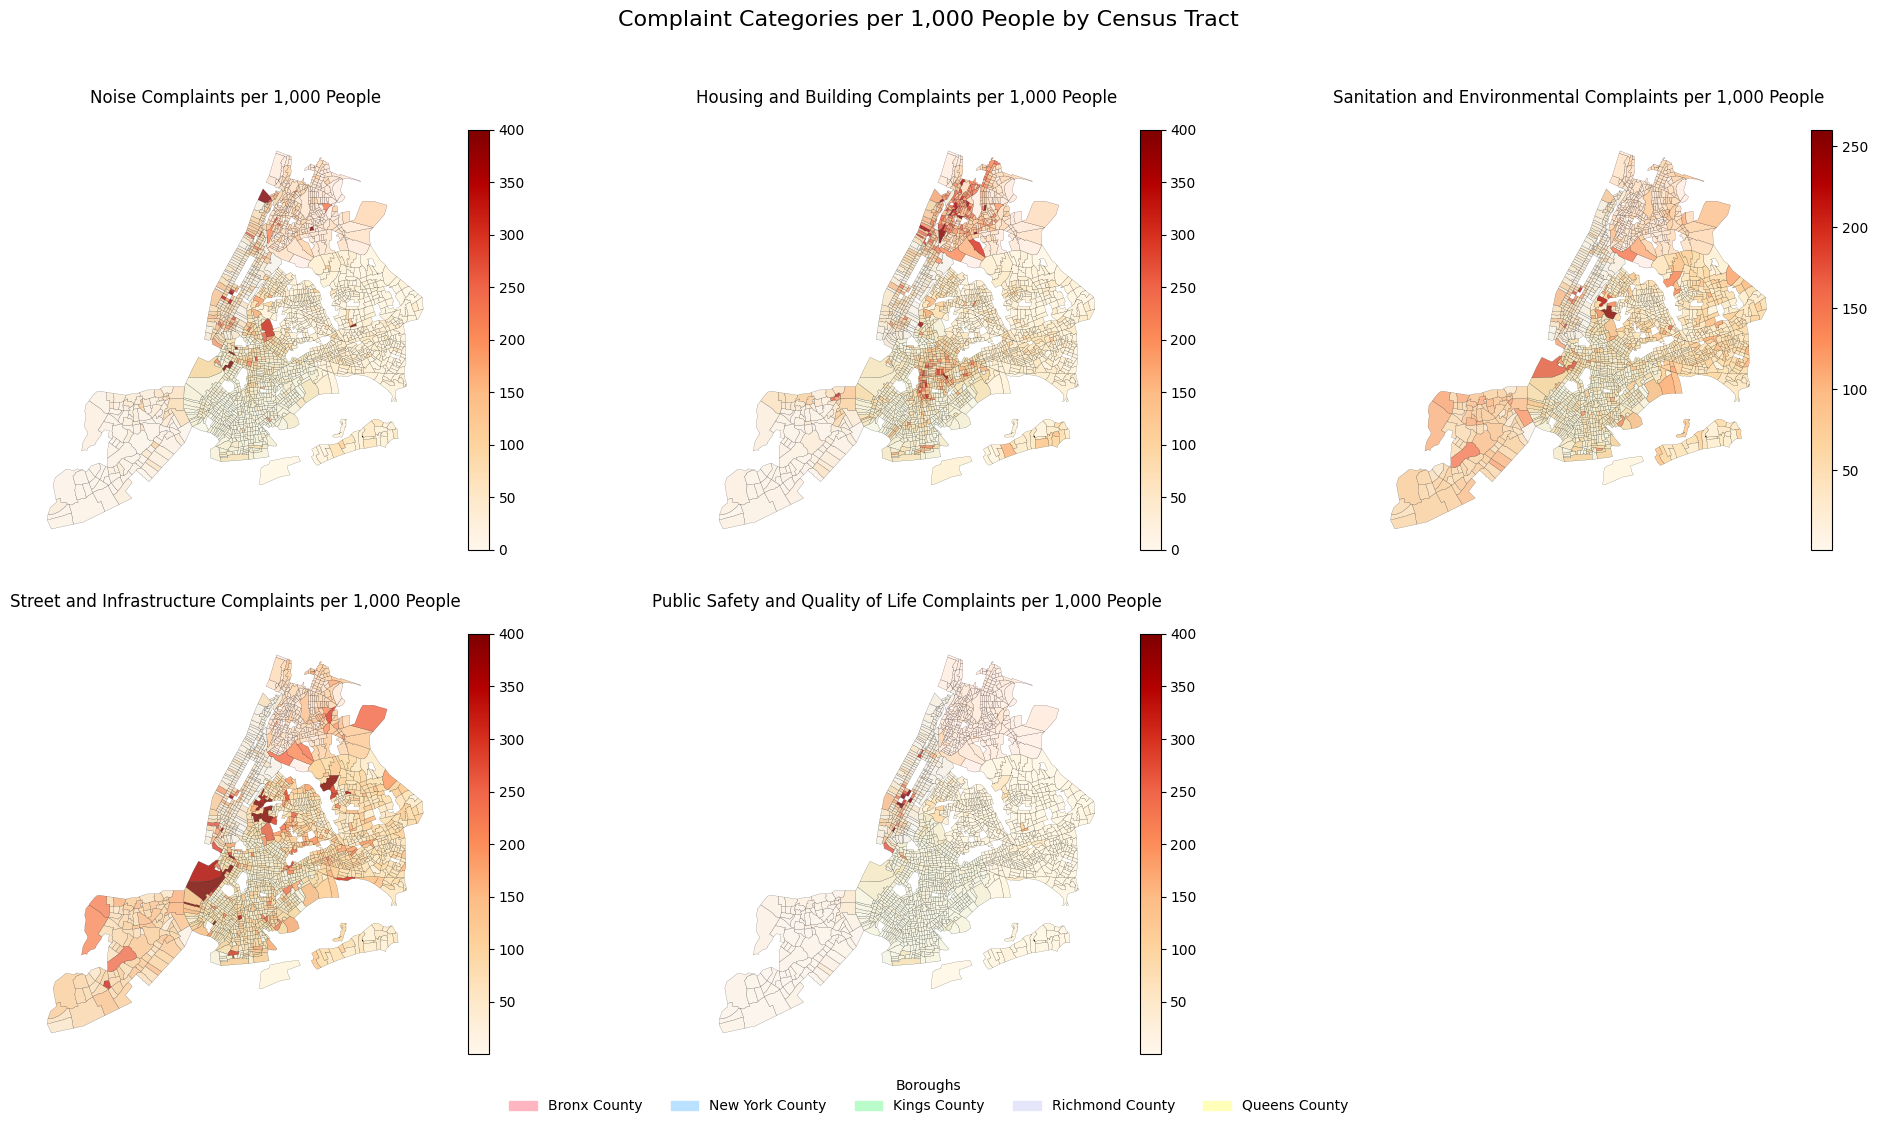

In [18]:
borough_colors = {
    'Bronx County': '#FFB6C1',  #pastel pink
    'New York County': '#BAE1FF',  #pastel blue
    'Kings County': '#B9FBC9',  #pastel green
    'Richmond County': '#E6E6FA',  #pastel lavender
    'Queens County': '#FFFFBA',  #pastel yellow
}


if 'COUNTY' in acs_tiger.columns:
    #set borough colors
    acs_tiger['Borough_Color'] = acs_tiger['COUNTY'].map(borough_colors)
else:
    print("Borough data not found. Skipping borough coloring.")


n_categories = len(complaint_categories_list)
n_cols = 3  
n_rows = -(-n_categories // n_cols) 

#subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 12))
plt.subplots_adjust(hspace=0.2, wspace=0.3)  #space between rows and columns


axes = axes.flatten()

#all complaint categories plotted
for idx, category in enumerate(complaint_categories_list):
    column_name = f"{category}_Per_1000_PeopleCLIP"
    

    if column_name in acs_tiger.columns:
        #borough boundaries with transparency
        for borough, color in borough_colors.items():
            borough_subset = acs_tiger[acs_tiger['COUNTY'] == borough]
            borough_subset.plot(
                color=color,
                ax=axes[idx],
                edgecolor='none',
                alpha=0.5  #borough shading
            )
        
        #complaint data overlay
        acs_tiger.plot(
            column=column_name,
            ax=axes[idx],
            cmap='OrRd',
            legend=True,
            missing_kwds={'color': 'lightgrey', 'label': 'No Data'},
            edgecolor='black',  #boundaries for census tracts
            linewidth=0.12,      #tract boundary lines
            alpha=0.8           #overlay transparency
        )
        
        #title and axis
        axes[idx].set_title(f"{category} per 1,000 People", fontsize=12, y=1.05)
        axes[idx].axis('off')
    else:
        axes[idx].text(0.5, 0.5, f"No Data for {category}", ha='center', va='center')
        axes[idx].set_title(f"{category}", fontsize=12)
        axes[idx].axis('off')


for i in range(len(axes)):
    if i >= n_categories:
        axes[i].axis('off')

#legend
legend_patches = [
    mpatches.Patch(color=color, label=borough)
    for borough, color in borough_colors.items()
]
fig.legend(
    handles=legend_patches,
    loc='lower center',
    ncol=5, 
    frameon=False,
    title='Boroughs',
    bbox_to_anchor=(0.5, 0.05) 
)


plt.tight_layout 
fig.suptitle('Complaint Categories per 1,000 People by Census Tract', fontsize=16)


plt.show()

In [19]:
import matplotlib.pyplot as plt

variables = [
    'Median_Household_Income', 'Percent_White', 'Percent_Black',
    'Percent_Hispanic', 'Percent_Asian', 'Percent_Other',
    'Noise Complaints_Per_1000_People',
    'Housing and Building Complaints_Per_1000_People',
    'Sanitation and Environmental Complaints_Per_1000_People',
    'Street and Infrastructure Complaints_Per_1000_People',
    'Public Safety and Quality of Life Complaints_Per_1000_People'
]


analysis_data = acs_tiger[variables].dropna()

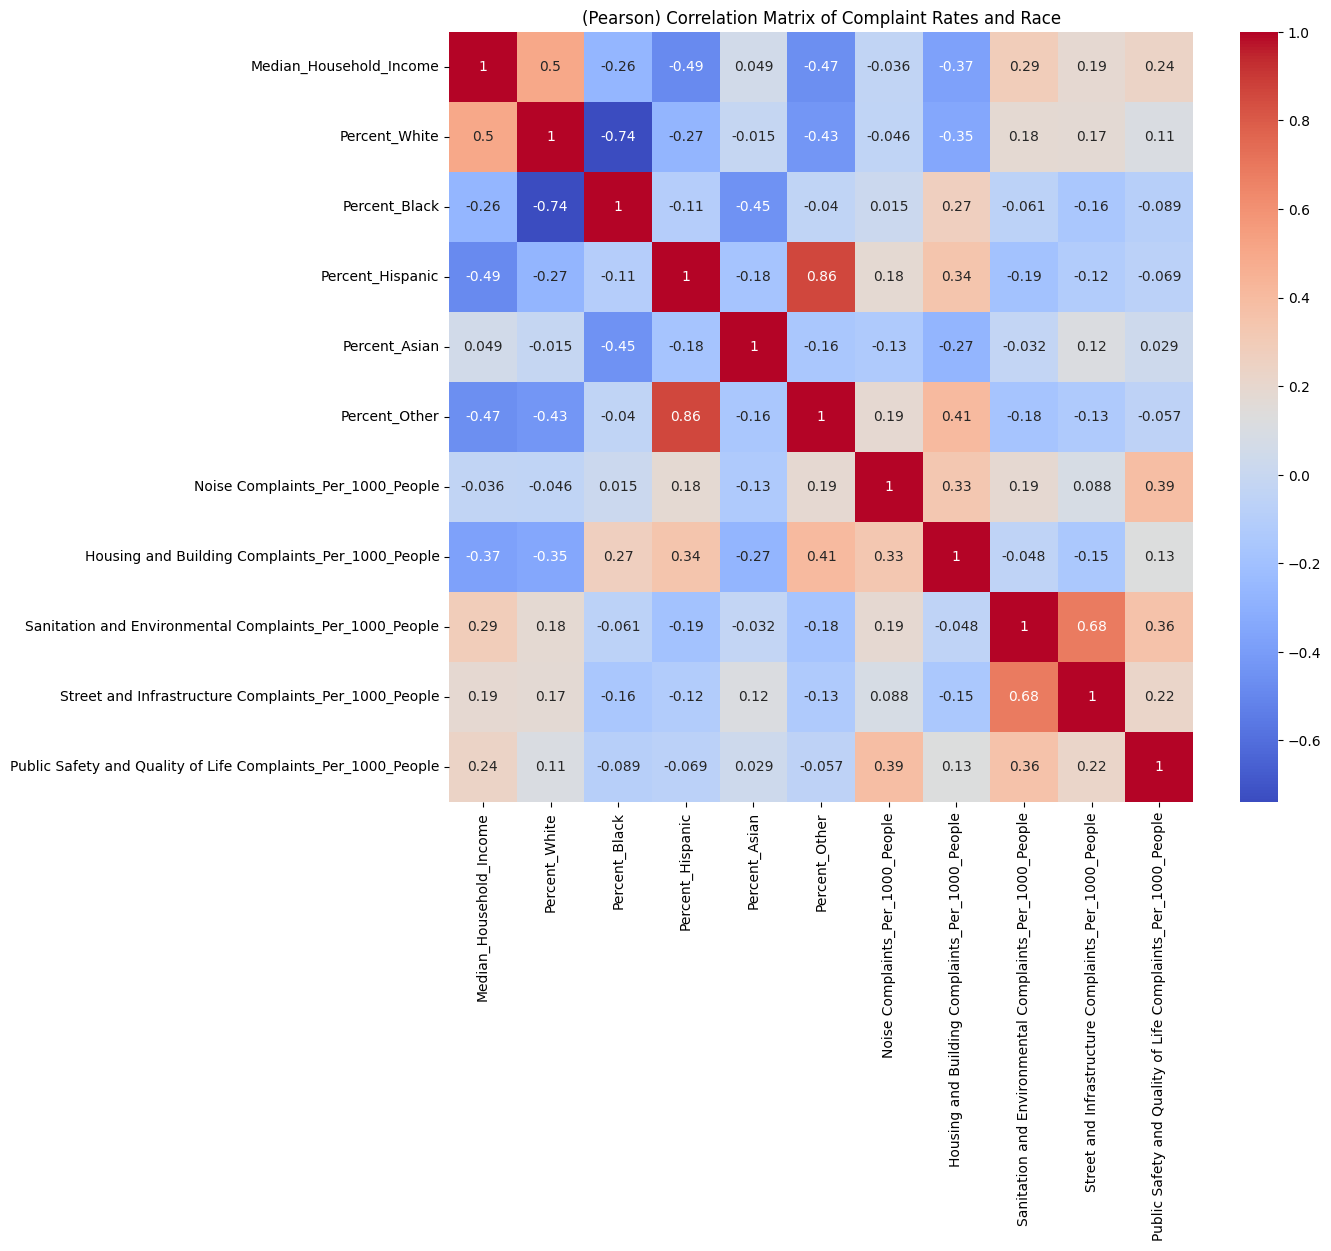

In [20]:
#Pearson
#correlation matrix
corr_matrix = analysis_data.corr(method = 'pearson')

#heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('(Pearson) Correlation Matrix of Complaint Rates and Race')
plt.show()

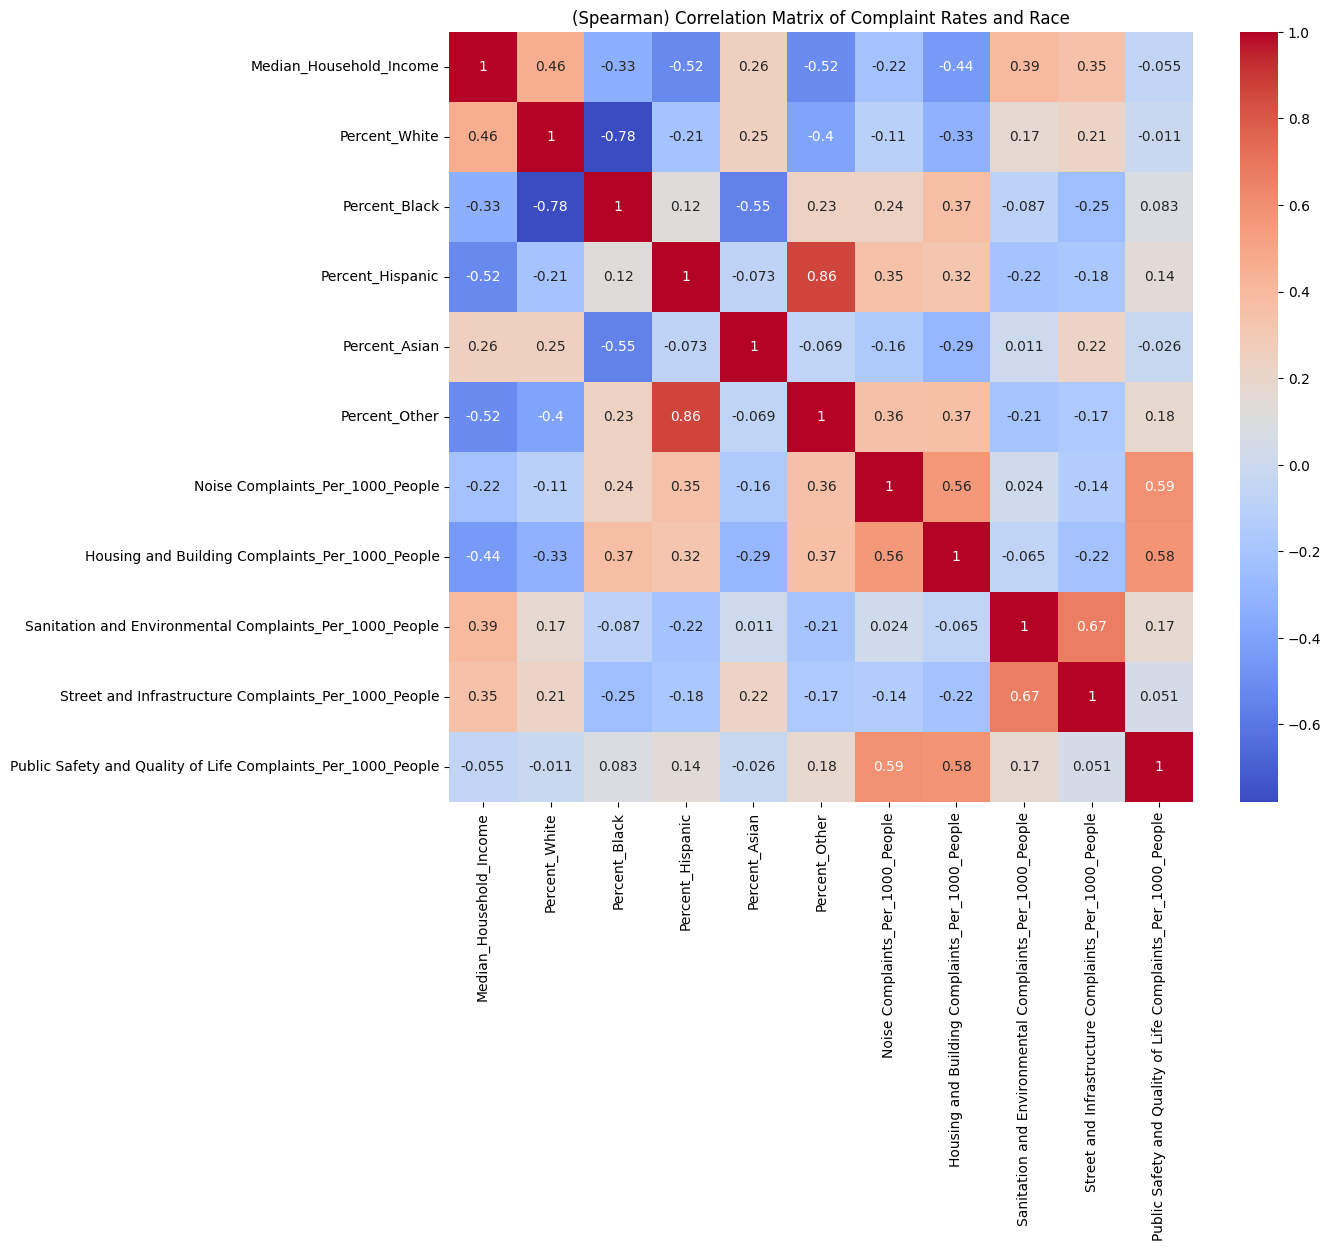

In [21]:
#Spearman
corr_matrix = analysis_data.corr(method = 'spearman')
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('(Spearman) Correlation Matrix of Complaint Rates and Race')
plt.show()

In [22]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

#Noise Complaints

#adjust for 0
analysis_data = analysis_data[analysis_data['Median_Household_Income'] > 0].copy()

#log transform median income
analysis_data['Log_Income'] = np.log(analysis_data['Median_Household_Income'])

#log-transform dependent var with +1 to handle potential zeros
analysis_data['Log_Noise_Complaints'] = np.log(analysis_data['Noise Complaints_Per_1000_People'] + 1)

#dependent
Y = analysis_data['Log_Noise_Complaints']

#independents
X = analysis_data[['Log_Income', 'Percent_Asian', 'Percent_Black', 'Percent_Hispanic']]


valid_data = pd.concat([X, Y], axis=1).dropna()
X = valid_data[['Log_Income', 'Percent_Asian', 'Percent_Black', 'Percent_Hispanic']]
Y = valid_data['Log_Noise_Complaints']


#maintain consistency
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_array, index=X.index, columns=X.columns)

X_scaled = sm.add_constant(X_scaled)
Y_aligned = Y.loc[X_scaled.index]


model = sm.OLS(Y_aligned, X_scaled).fit()

#regular OLS
print("Regular OLS Results with log-transformed dependent variable:")
print(model.summary())

#adjust for standard errors/heteroskedasticity with HC1
robust_hc1 = model.get_robustcov_results(cov_type='HC1')
print("\nOLS Results with HC1 robust standard errors (log-transformed Y):")
print(robust_hc1.summary())

#HC3
robust_hc3 = model.get_robustcov_results(cov_type='HC3')
print("\nOLS Results with HC3 robust standard errors (log-transformed Y):")
print(robust_hc3.summary())

Regular OLS Results with log-transformed dependent variable:
                             OLS Regression Results                             
Dep. Variable:     Log_Noise_Complaints   R-squared:                       0.137
Model:                              OLS   Adj. R-squared:                  0.136
Method:                   Least Squares   F-statistic:                     83.13
Date:                  Tue, 14 Jul 2026   Prob (F-statistic):           1.44e-65
Time:                          23:27:58   Log-Likelihood:                -2411.2
No. Observations:                  2093   AIC:                             4832.
Df Residuals:                      2088   BIC:                             4861.
Df Model:                             4                                         
Covariance Type:              nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------

In [23]:
#Housing and Building Complaints

#log-transform dependent var with +1 to handle potential zeros
analysis_data['Log_HNB_Complaints'] = np.log(analysis_data['Housing and Building Complaints_Per_1000_People'] + 1)

#dependent
Y = analysis_data['Log_HNB_Complaints']

#independents
X = analysis_data[['Log_Income', 'Percent_Asian', 'Percent_Black', 'Percent_Hispanic']]


valid_data = pd.concat([X, Y], axis=1).dropna()
X = valid_data[['Log_Income', 'Percent_Asian', 'Percent_Black', 'Percent_Hispanic']]
Y = valid_data['Log_HNB_Complaints']


#maintain consistency
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_array, index=X.index, columns=X.columns)

X_scaled = sm.add_constant(X_scaled)
Y_aligned = Y.loc[X_scaled.index]


model = sm.OLS(Y_aligned, X_scaled).fit()

#regular OLS
print("Regular OLS Results with log-transformed dependent variable:")
print(model.summary())

#adjust for standard errors/heteroskedasticity with HC1
robust_hc1 = model.get_robustcov_results(cov_type='HC1')
print("\nOLS Results with HC1 robust standard errors (log-transformed Y):")
print(robust_hc1.summary())

#HC3
robust_hc3 = model.get_robustcov_results(cov_type='HC3')
print("\nOLS Results with HC3 robust standard errors (log-transformed Y):")
print(robust_hc3.summary())

Regular OLS Results with log-transformed dependent variable:
                            OLS Regression Results                            
Dep. Variable:     Log_HNB_Complaints   R-squared:                       0.196
Model:                            OLS   Adj. R-squared:                  0.195
Method:                 Least Squares   F-statistic:                     127.5
Date:                Tue, 14 Jul 2026   Prob (F-statistic):           1.73e-97
Time:                        23:27:58   Log-Likelihood:                -2551.8
No. Observations:                2093   AIC:                             5114.
Df Residuals:                    2088   BIC:                             5142.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

In [24]:
#Sanitation and Environmental Complaints

#log-transform dependent var with +1 to handle potential zeros
analysis_data['Log_SNE_Complaints'] = np.log(analysis_data['Sanitation and Environmental Complaints_Per_1000_People'] + 1)

#dependent
Y = analysis_data['Log_SNE_Complaints']

#independents
X = analysis_data[['Log_Income', 'Percent_Asian', 'Percent_Black', 'Percent_Hispanic']]


valid_data = pd.concat([X, Y], axis=1).dropna()
X = valid_data[['Log_Income', 'Percent_Asian', 'Percent_Black', 'Percent_Hispanic']]
Y = valid_data['Log_SNE_Complaints']


#maintain consistency
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_array, index=X.index, columns=X.columns)

X_scaled = sm.add_constant(X_scaled)
Y_aligned = Y.loc[X_scaled.index]


model = sm.OLS(Y_aligned, X_scaled).fit()

#regular OLS
print("Regular OLS Results with log-transformed dependent variable:")
print(model.summary())

#adjust for standard errors/heteroskedasticity with HC1
robust_hc1 = model.get_robustcov_results(cov_type='HC1')
print("\nOLS Results with HC1 robust standard errors (log-transformed Y):")
print(robust_hc1.summary())

#HC3
robust_hc3 = model.get_robustcov_results(cov_type='HC3')
print("\nOLS Results with HC3 robust standard errors (log-transformed Y):")
print(robust_hc3.summary())

Regular OLS Results with log-transformed dependent variable:
                            OLS Regression Results                            
Dep. Variable:     Log_SNE_Complaints   R-squared:                       0.153
Model:                            OLS   Adj. R-squared:                  0.151
Method:                 Least Squares   F-statistic:                     94.32
Date:                Tue, 14 Jul 2026   Prob (F-statistic):           7.89e-74
Time:                        23:27:58   Log-Likelihood:                -1626.9
No. Observations:                2093   AIC:                             3264.
Df Residuals:                    2088   BIC:                             3292.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

In [25]:
#Street and Infrastructure Complaints

#log-transform dependent var with +1 to handle potential zeros
analysis_data['Log_SNI_Complaints'] = np.log(analysis_data['Street and Infrastructure Complaints_Per_1000_People'] + 1)

#dependent
Y = analysis_data['Log_SNI_Complaints']

#independents
X = analysis_data[['Log_Income', 'Percent_Asian', 'Percent_Black', 'Percent_Hispanic']]


valid_data = pd.concat([X, Y], axis=1).dropna()
X = valid_data[['Log_Income', 'Percent_Asian', 'Percent_Black', 'Percent_Hispanic']]
Y = valid_data['Log_SNI_Complaints']



#maintain consistency
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_array, index=X.index, columns=X.columns)

X_scaled = sm.add_constant(X_scaled)
Y_aligned = Y.loc[X_scaled.index]


model = sm.OLS(Y_aligned, X_scaled).fit()

#regular OLS
print("Regular OLS Results with log-transformed dependent variable:")
print(model.summary())

#adjust for standard errors/heteroskedasticity with HC1
robust_hc1 = model.get_robustcov_results(cov_type='HC1')
print("\nOLS Results with HC1 robust standard errors (log-transformed Y):")
print(robust_hc1.summary())

#HC3
robust_hc3 = model.get_robustcov_results(cov_type='HC3')
print("\nOLS Results with HC3 robust standard errors (log-transformed Y):")
print(robust_hc3.summary())

Regular OLS Results with log-transformed dependent variable:
                            OLS Regression Results                            
Dep. Variable:     Log_SNI_Complaints   R-squared:                       0.153
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     94.64
Date:                Tue, 14 Jul 2026   Prob (F-statistic):           4.59e-74
Time:                        23:27:58   Log-Likelihood:                -1937.6
No. Observations:                2093   AIC:                             3885.
Df Residuals:                    2088   BIC:                             3913.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

In [26]:
#Public Safety and Quality of Life Complaints

#log-transform dependent var with +1 to handle potential zeros
analysis_data['Log_PSQL_Complaints'] = np.log(analysis_data['Public Safety and Quality of Life Complaints_Per_1000_People'] + 1)

#dependent
Y = analysis_data['Log_PSQL_Complaints']

#independents
X = analysis_data[['Log_Income', 'Percent_Asian', 'Percent_Black', 'Percent_Hispanic']]


valid_data = pd.concat([X, Y], axis=1).dropna()
X = valid_data[['Log_Income', 'Percent_Asian', 'Percent_Black', 'Percent_Hispanic']]
Y = valid_data['Log_PSQL_Complaints']


#maintain consistency
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_array, index=X.index, columns=X.columns)

X_scaled = sm.add_constant(X_scaled)
Y_aligned = Y.loc[X_scaled.index]


model = sm.OLS(Y_aligned, X_scaled).fit()

#regular OLS
print("Regular OLS Results with log-transformed dependent variable:")
print(model.summary())

#adjust for standard errors/heteroskedasticity with HC1
robust_hc1 = model.get_robustcov_results(cov_type='HC1')
print("\nOLS Results with HC1 robust standard errors (log-transformed Y):")
print(robust_hc1.summary())

#HC3
robust_hc3 = model.get_robustcov_results(cov_type='HC3')
print("\nOLS Results with HC3 robust standard errors (log-transformed Y):")
print(robust_hc3.summary())

Regular OLS Results with log-transformed dependent variable:
                             OLS Regression Results                            
Dep. Variable:     Log_PSQL_Complaints   R-squared:                       0.031
Model:                             OLS   Adj. R-squared:                  0.029
Method:                  Least Squares   F-statistic:                     16.50
Date:                 Tue, 14 Jul 2026   Prob (F-statistic):           2.55e-13
Time:                         23:27:58   Log-Likelihood:                -2518.7
No. Observations:                 2093   AIC:                             5047.
Df Residuals:                     2088   BIC:                             5076.
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

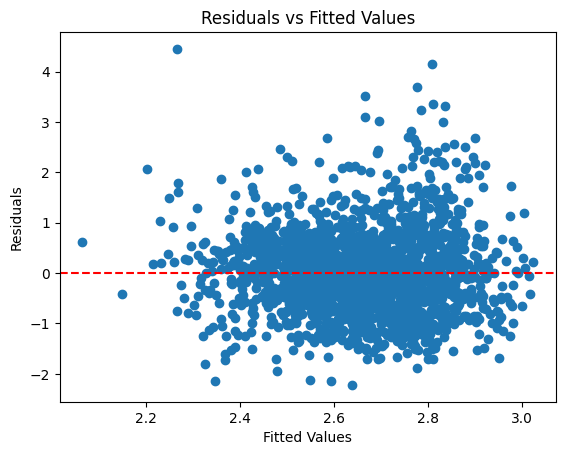

In [27]:
residuals = model.resid
fitted_values = model.fittedvalues

plt.scatter(fitted_values, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

In [28]:
from esda.moran import Moran
from esda.moran import Moran_Local
from libpysal.weights import Queen

/var/folders/dn/l049vy7s08vdd1gsbz4bq_d00000gn/T/ipykernel_16437/1414549075.py:6: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(acs_tiger)
/Users/marquiswong/Desktop/projects/nyc311urbandata/.venv/lib/python3.13/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
 There are 2 islands with ids: 550, 1593.
  W.__init__(self, neighbors, ids=ids, **kw)


('WARNING: ', 550, ' is an island (no neighbors)')
('WARNING: ', 1593, ' is an island (no neighbors)')


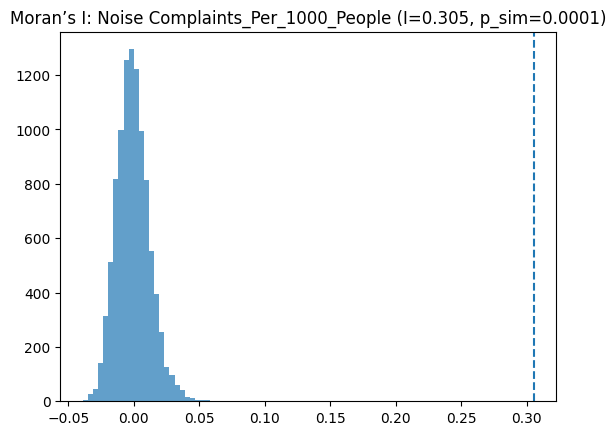

In [29]:
def moran_with_perms(gdf, col, w, permutations=9999):
    x = gdf[col].astype(float).replace([np.inf, -np.inf], np.nan).fillna(0)
    return Moran(x, w, permutations=permutations)


w = Queen.from_dataframe(acs_tiger)
w.transform = "r"


rate_cols = [f"{c}_Per_1000_People" for c in complaint_categories_list]
morans = {col: moran_with_perms(acs_tiger, col, w) for col in rate_cols}


col = rate_cols[0]
m = morans[col]
plt.hist(m.sim, bins=30, alpha=0.7)
plt.axvline(m.I, linestyle="--")
plt.title(f"Moran’s I: {col} (I={m.I:.3f}, p_sim={m.p_sim:.4f})")
plt.show()

In [30]:
#latitude and longitude range 
#plt.xlim([-74.3, -73.7]) #long
#plt.ylim([40.4, 41])     #lat

In [31]:
rate_cols = [f"{c}_Per_1000_People" for c in complaint_categories_list]

df = acs_tiger[['Median_Household_Income'] + rate_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()
df = df[df['Median_Household_Income'] > 0].copy()

# income quintiles
df['income_quintile'] = pd.qcut(df['Median_Household_Income'], 5, labels=['Q1_low','Q2','Q3','Q4','Q5_high'])

quint = df.groupby('income_quintile')[rate_cols].mean().T
quint['Q1_over_Q5'] = quint['Q1_low'] / quint['Q5_high']
quint['Q1_minus_Q5'] = quint['Q1_low'] - quint['Q5_high']

# correlations
corr_rows = []
for col in rate_cols:
    pear = df['Median_Household_Income'].corr(df[col], method='pearson')
    spear = df['Median_Household_Income'].corr(df[col], method='spearman')
    corr_rows.append([col, pear, spear])

corr_tbl = pd.DataFrame(corr_rows, columns=['metric','pearson_r','spearman_rho']).set_index('metric')

summary = quint.join(corr_tbl, how='left')
summary = summary.sort_values('Q1_over_Q5', ascending=False)
summary

,Q1_low,Q2,Q3,Q4,Q5_high,Q1_over_Q5,Q1_minus_Q5,pearson_r,spearman_rho
Housing and Building Complaints_Per_1000_People,120.307668,103.468253,63.000379,47.275288,39.724821,3.028526,80.582847,-0.374437,-0.443606
Noise Complaints_Per_1000_People,61.975067,49.020518,43.283415,37.513036,46.830727,1.323385,15.144340,-0.036486,-0.220815
Sanitation and Environmental Complaints_Per_1000_People,31.012913,39.734120,43.713210,51.471254,55.191525,0.561914,-24.178612,0.292365,0.393699
Street and Infrastructure Complaints_Per_1000_People,51.152208,78.908134,97.882191,94.890177,93.372868,0.547827,-42.220661,0.191419,0.349312
Public Safety and Quality of Life Complaints_Per_1000_People,18.880556,17.662252,15.541234,15.017963,41.101149,0.459368,-22.220593,0.237641,-0.055114


In [32]:
from sklearn.cluster import KMeans

mix = acs_tiger[rate_cols].replace([np.inf, -np.inf], np.nan).fillna(0).copy()

scaler = StandardScaler()
X = scaler.fit_transform(mix)

k = 5  # try 4–6
km = KMeans(n_clusters=k, random_state=42, n_init='auto')
acs_tiger['segment'] = km.fit_predict(X)

# segment profiles (mean rates)
seg_profile = acs_tiger.groupby('segment')[rate_cols].mean()
seg_profile

,Noise Complaints_Per_1000_People,Housing and Building Complaints_Per_1000_People,Sanitation and Environmental Complaints_Per_1000_People,Street and Infrastructure Complaints_Per_1000_People,Public Safety and Quality of Life Complaints_Per_1000_People
segment,,,,,
0,80.338924,182.136274,36.811776,50.849302,25.670481
1,33.461759,48.123757,29.739623,61.046716,14.474606
2,32.381645,43.393769,64.919569,122.976553,15.906403
3,210.359915,106.033938,159.434702,229.757557,624.099690
4,206.746094,92.702412,104.688215,250.937125,106.777859


In [33]:
def top_cats(row, cols, topn=2):
    s = row[cols].sort_values(ascending=False)
    return " + ".join([c.replace('_Per_1000_People','') for c in s.index[:topn]])

seg_profile['persona'] = seg_profile.apply(lambda r: top_cats(r, rate_cols, 2), axis=1)
seg_profile[['persona']]

,persona
segment,
0,Housing and Building Complaints + Noise Compla...
1,Street and Infrastructure Complaints + Housing...
2,Street and Infrastructure Complaints + Sanitat...
3,Public Safety and Quality of Life Complaints +...
4,Street and Infrastructure Complaints + Noise C...


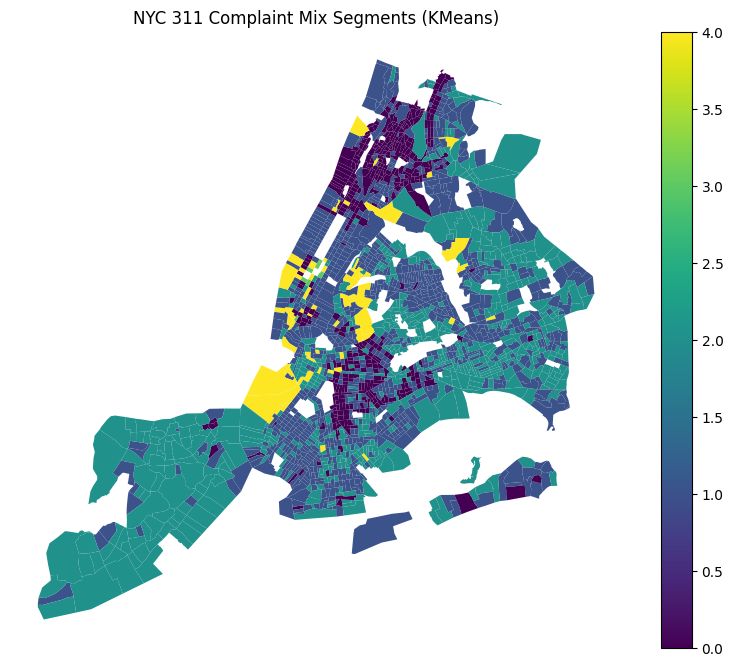

In [34]:
import matplotlib.pyplot as plt
acs_tiger.plot(column='segment', legend=True, figsize=(10,8))
plt.title("NYC 311 Complaint Mix Segments (KMeans)")
plt.axis('off')
plt.show()

In [35]:
target_metric = "Noise Complaints_Per_1000_People"  # change to any rate col
K_values = [25, 50, 100, 150, 200]
effect = 0.20  # assumed reduction in targeted tracts

df = acs_tiger[['Median_Household_Income', target_metric]].replace([np.inf, -np.inf], np.nan).dropna().copy()
df = df[df['Median_Household_Income'] > 0].copy()
df['income_quintile'] = pd.qcut(df['Median_Household_Income'], 5, labels=['Q1_low','Q2','Q3','Q4','Q5_high'])

def simulate(policy, K):
    d = df.copy()

    if policy == "efficient":
        # target highest complaint rates
        idx = d[target_metric].nlargest(K).index
    elif policy == "equity":
        # target within lowest-income quintile first, by highest rates
        low = d[d['income_quintile'] == 'Q1_low']
        idx = low[target_metric].nlargest(min(K, len(low))).index
    else:
        raise ValueError("unknown policy")

    d['reduction'] = 0.0
    d.loc[idx, 'reduction'] = effect * d.loc[idx, target_metric]

    total_reduction = d['reduction'].sum()
    by_quint = d.groupby('income_quintile')['reduction'].sum()
    equity_share_Q1 = by_quint.get('Q1_low', 0.0) / (total_reduction + 1e-12)

    return total_reduction, equity_share_Q1, by_quint

rows = []
for K in K_values:
    eff_red, eff_q1share, _ = simulate("efficient", K)
    eq_red,  eq_q1share,  _ = simulate("equity", K)
    rows.append([K, eff_red, eff_q1share, eq_red, eq_q1share])

tradeoff = pd.DataFrame(rows, columns=['K_trcts','efficient_total_reduction','efficient_Q1_share','equity_total_reduction','equity_Q1_share'])
tradeoff

,K_trcts,efficient_total_reduction,efficient_Q1_share,equity_total_reduction,equity_Q1_share
0,25,1846.810544,0.358638,1157.853768,1.0
1,50,2794.432535,0.288917,1715.663102,1.0
2,100,4215.603568,0.244573,2618.505455,1.0
3,150,5405.170544,0.266328,3284.437091,1.0
4,200,6462.569109,0.274853,3835.858127,1.0


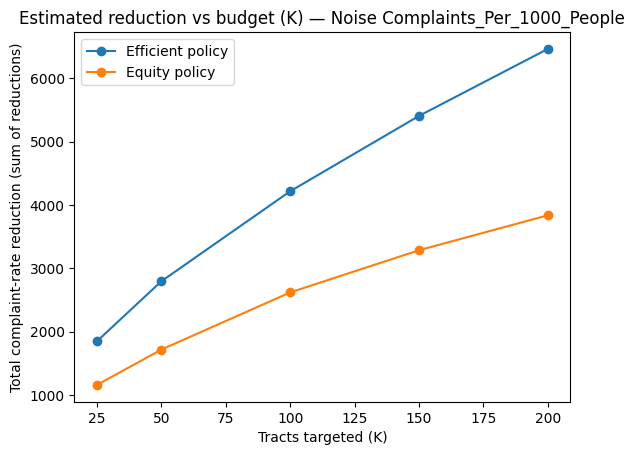

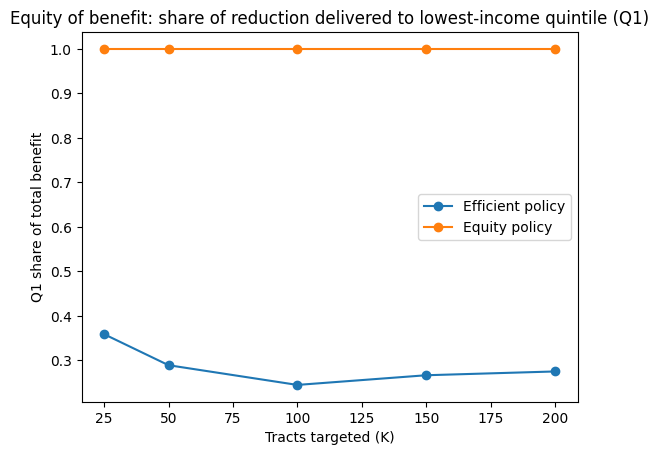

In [36]:
plt.plot(tradeoff['K_trcts'], tradeoff['efficient_total_reduction'], marker='o', label='Efficient policy')
plt.plot(tradeoff['K_trcts'], tradeoff['equity_total_reduction'], marker='o', label='Equity policy')
plt.title(f"Estimated reduction vs budget (K) — {target_metric}")
plt.xlabel("Tracts targeted (K)")
plt.ylabel("Total complaint-rate reduction (sum of reductions)")
plt.legend()
plt.show()

plt.plot(tradeoff['K_trcts'], tradeoff['efficient_Q1_share'], marker='o', label='Efficient policy')
plt.plot(tradeoff['K_trcts'], tradeoff['equity_Q1_share'], marker='o', label='Equity policy')
plt.title("Equity of benefit: share of reduction delivered to lowest-income quintile (Q1)")
plt.xlabel("Tracts targeted (K)")
plt.ylabel("Q1 share of total benefit")
plt.legend()
plt.show()

In [37]:
# pick a category where "need" is most plausible: Housing/Building
y = "Housing and Building Complaints_Per_1000_People"

d = acs_tiger[['GEOID','COUNTY','Median_Household_Income','segment', y]].replace([np.inf, -np.inf], np.nan).dropna().copy()
d = d[d['Median_Household_Income'] > 0].copy()

# log transforms to reduce heavy tails
d['log_income'] = np.log(d['Median_Household_Income'])
d['log_y'] = np.log(d[y] + 1)

# expected reporting within peer group (borough + segment) using group mean
grp = ['COUNTY','segment']
d['peer_expected'] = d.groupby(grp)['log_y'].transform('mean')

# residual vs peers (negative = under-reporting relative to peers)
d['peer_residual'] = d['log_y'] - d['peer_expected']

# underserved index: high issue burden but under-reporting vs peers
# (need proxy here is the actual housing/building rate; you can also use percentile)
d['need_proxy'] = (d['log_y'] - d['log_y'].mean()) / d['log_y'].std(ddof=0)
d['underserved_score'] = d['need_proxy'] * (-d['peer_residual'])

d.sort_values('underserved_score', ascending=False).head(20)[
    ['GEOID','COUNTY','segment', y,'Median_Household_Income','peer_residual','underserved_score']

_IncompleteInputError: incomplete input (1355987566.py, line 24)

In [38]:
# build weights if you haven't already
w = Queen.from_dataframe(acs_tiger)
w.transform = "r"

target = "Noise Complaints_Per_1000_People"
vals = acs_tiger[target].to_numpy(dtype=float)
y = np.log(vals + 1)

nbr_mean = np.full(len(y), np.nan)
nbr_std  = np.full(len(y), np.nan)
nbr_n    = np.zeros(len(y), dtype=int)

for i in range(len(y)):
    nbrs = w.neighbors.get(i, [])
    nbr_n[i] = len(nbrs)
    if len(nbrs) >= 3:  # require at least 3 neighbors
        yy = y[nbrs]
        nbr_mean[i] = np.nanmean(yy)
        nbr_std[i] = np.nanstd(yy)

# guardrail: floor std to prevent exploding z-scores
std_floor = np.nanpercentile(nbr_std, 10)  # or set a small constant like 0.05
nbr_std_safe = np.where(np.isnan(nbr_std), np.nan, np.maximum(nbr_std, std_floor))

acs_tiger['nbr_n'] = nbr_n
acs_tiger['local_z_safe'] = (y - nbr_mean) / (nbr_std_safe + 1e-6)

acs_tiger[['GEOID','COUNTY',target,'nbr_n','local_z_safe']].sort_values('local_z_safe', ascending=False).head(20)

('WARNING: ', 550, ' is an island (no neighbors)')
('WARNING: ', 1593, ' is an island (no neighbors)')


/var/folders/dn/l049vy7s08vdd1gsbz4bq_d00000gn/T/ipykernel_16437/2002258101.py:2: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(acs_tiger)
/Users/marquiswong/Desktop/projects/nyc311urbandata/.venv/lib/python3.13/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
 There are 2 islands with ids: 550, 1593.
  W.__init__(self, neighbors, ids=ids, **kw)


,GEOID,COUNTY,Noise Complaints_Per_1000_People,nbr_n,local_z_safe
255,36005007000,Bronx County,514.829208,4,11.257474
1252,36047003700,Kings County,496.705107,8,8.201503
75,36047065200,Kings County,231.111111,8,7.966921
1249,36047002901,Kings County,1016.200295,4,6.903540
47,36081094700,Queens County,143.807763,6,6.788608
329,36047011900,Kings County,696.493349,12,6.691912
1537,36081037300,Queens County,130.304168,5,6.239908
214,36047048600,Kings County,91.818182,6,5.545719
115,36047024900,Kings County,299.667300,7,5.489709
543,36005040701,Bronx County,262.738854,6,5.399474


In [39]:
islands = w.islands
print(islands)
acs_tiger.loc[islands, ['GEOID','COUNTY']].head()

[550, 1593]


,GEOID,COUNTY
550,36081015900,Queens County
1593,36081014700,Queens County


In [40]:
acs_tiger_no_islands = acs_tiger.drop(index=islands).copy()

In [41]:
from libpysal.weights import KNN
w_knn = KNN.from_dataframe(acs_tiger, k=8)
w_knn.transform = "r"

/Users/marquiswong/Desktop/projects/nyc311urbandata/.venv/lib/python3.13/site-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


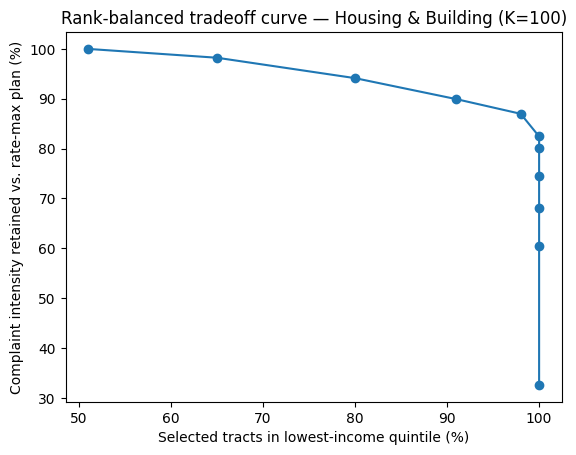

,scenario_id,scaling_mode,K,alpha_intensity,alpha_lower_income,intensity_retention_vs_rate_max_pct,selected_Q1_tract_share_pct,Q1_share_of_selected_intensity_pct
0,rank_balanced-housing_building-k100-a000,rank_balanced,100,0.0,1.0,32.602,100.0,100.000
1,rank_balanced-housing_building-k100-a010,rank_balanced,100,0.1,0.9,60.500,100.0,100.000
2,rank_balanced-housing_building-k100-a020,rank_balanced,100,0.2,0.8,68.039,100.0,100.000
3,rank_balanced-housing_building-k100-a030,rank_balanced,100,0.3,0.7,74.505,100.0,100.000
4,rank_balanced-housing_building-k100-a040,rank_balanced,100,0.4,0.6,80.095,100.0,100.000
5,rank_balanced-housing_building-k100-a050,rank_balanced,100,0.5,0.5,82.439,100.0,100.000
6,rank_balanced-housing_building-k100-a060,rank_balanced,100,0.6,0.4,86.986,98.0,97.479
7,rank_balanced-housing_building-k100-a070,rank_balanced,100,0.7,0.3,89.931,91.0,90.422
8,rank_balanced-housing_building-k100-a080,rank_balanced,100,0.8,0.2,94.138,80.0,79.378
9,rank_balanced-housing_building-k100-a090,rank_balanced,100,0.9,0.1,98.231,65.0,65.462


In [42]:

# ---------------------------------------------------------
# PRIORITY ATLAS — FINAL DUAL-SCALING SCENARIO ENGINE
# ---------------------------------------------------------
#
# Default model:
#   rank_balanced
#
# Advanced sensitivity model:
#   magnitude_sensitive
#
# Both models use the same 2,093-tract complete-case
# candidate universe. They differ only in how the two
# ranking components are scaled before alpha weighting.
# ---------------------------------------------------------


PRIORITY_DOMAINS = {
    'noise': {
        'label': 'Noise',
        'count_col': 'Noise Complaints',
        'rate_col': 'Noise Complaints_Per_1000_People',
        'property_prefix': 'noise',
    },
    'housing_building': {
        'label': 'Housing & Building',
        'count_col': 'Housing and Building Complaints',
        'rate_col': 'Housing and Building Complaints_Per_1000_People',
        'property_prefix': 'housingBuilding',
    },
    'sanitation_environmental': {
        'label': 'Sanitation & Environmental',
        'count_col': 'Sanitation and Environmental Complaints',
        'rate_col': 'Sanitation and Environmental Complaints_Per_1000_People',
        'property_prefix': 'sanitationEnvironmental',
    },
    'street_infrastructure': {
        'label': 'Street & Infrastructure',
        'count_col': 'Street and Infrastructure Complaints',
        'rate_col': 'Street and Infrastructure Complaints_Per_1000_People',
        'property_prefix': 'streetInfrastructure',
    },
    'public_safety_quality_of_life': {
        'label': 'Public Safety & Quality of Life',
        'count_col': 'Public Safety and Quality of Life Complaints',
        'rate_col': 'Public Safety and Quality of Life Complaints_Per_1000_People',
        'property_prefix': 'publicSafetyQualityOfLife',
    },
}


SCALING_MODES = {
    'rank_balanced': {
        'label': 'Rank-balanced',
        'description': (
            'Uses percentile ranks so complaint intensity and '
            'lower-income priority occupy the same 0–1 scale.'
        ),
    },
    'magnitude_sensitive': {
        'label': 'Magnitude-sensitive',
        'description': (
            'Uses z-scores so exceptionally extreme values retain '
            'additional influence based on their magnitude.'
        ),
    },
}


K_VALUES = [25, 50, 100, 150, 200]
ALPHA_VALUES = [round(float(value), 1) for value in np.linspace(0, 1, 11)]
QUINTILE_LABELS = ['Q1_low', 'Q2', 'Q3', 'Q4', 'Q5_high']


# Shared complete-case universe used by all service domains
# and both scaling modes.

_all_priority_rate_cols = [
    config['rate_col']
    for config in PRIORITY_DOMAINS.values()
]

eligible_model_tracts = (
    acs_tiger.loc[
        acs_tiger['Median_Household_Income'].notna()
        & (acs_tiger['Median_Household_Income'] > 0)
    ]
    .dropna(subset=_all_priority_rate_cols)
    .copy()
)

eligible_model_tracts['GEOID'] = (
    eligible_model_tracts['GEOID']
    .astype(str)
)

assert len(eligible_model_tracts) == 2093
assert eligible_model_tracts['GEOID'].is_unique


def _build_priority_candidate_universe(gdf, target_metric):
    """Return the constant complete-case candidate universe."""
    required_cols = [
        'GEOID',
        'Median_Household_Income',
        target_metric,
    ]

    missing_cols = [
        column
        for column in required_cols
        if column not in gdf.columns
    ]

    if missing_cols:
        raise KeyError(
            f"Missing required priority-model columns: {missing_cols}"
        )

    candidates = (
        gdf[required_cols]
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=required_cols)
        .copy()
    )

    candidates['GEOID'] = candidates['GEOID'].astype(str)

    candidates = (
        candidates.loc[
            candidates['Median_Household_Income'] > 0
        ]
        .copy()
    )

    if not candidates['GEOID'].is_unique:
        raise ValueError(
            'Duplicate GEOIDs exist in the priority-model universe.'
        )

    candidates['income_quintile'] = pd.qcut(
        candidates['Median_Household_Income'],
        5,
        labels=QUINTILE_LABELS,
    )

    income_std = float(
        candidates['Median_Household_Income'].std(ddof=0)
    )
    intensity_std = float(
        candidates[target_metric].std(ddof=0)
    )

    if income_std == 0 or intensity_std == 0:
        raise ValueError(
            'A priority-model component has zero variance.'
        )

    candidates['lower_income_priority_z'] = -(
        (
            candidates['Median_Household_Income']
            - candidates['Median_Household_Income'].mean()
        )
        / income_std
    )

    candidates['lower_income_priority_percentile'] = (
        candidates['Median_Household_Income']
        .rank(
            method='average',
            ascending=False,
            pct=True,
        )
    )

    candidates['complaint_intensity_z'] = (
        (
            candidates[target_metric]
            - candidates[target_metric].mean()
        )
        / intensity_std
    )

    candidates['complaint_intensity_percentile'] = (
        candidates[target_metric]
        .rank(
            method='average',
            ascending=True,
            pct=True,
        )
    )

    return candidates


def build_priority_tradeoff_curve(
    gdf,
    target_metric,
    domain_key,
    scaling_mode='rank_balanced',
    K=100,
    alpha_values=None,
    plot=False,
):
    """
    Build deterministic top-K selection scenarios for one
    service domain, scaling mode, and portfolio size.

    alpha is the coefficient on complaint intensity.
    1 - alpha is the coefficient on lower-income priority.
    """

    if domain_key not in PRIORITY_DOMAINS:
        raise ValueError(
            f"Unsupported domain_key: {domain_key}"
        )

    if scaling_mode not in SCALING_MODES:
        raise ValueError(
            f"Unsupported scaling_mode: {scaling_mode}"
        )

    if alpha_values is None:
        alpha_values = ALPHA_VALUES

    candidates = _build_priority_candidate_universe(
        gdf,
        target_metric,
    )

    if K > len(candidates):
        raise ValueError(
            f"K={K} exceeds the {len(candidates)} eligible tracts."
        )

    if scaling_mode == 'rank_balanced':
        intensity_component_col = 'complaint_intensity_percentile'
        lower_income_component_col = 'lower_income_priority_percentile'
    else:
        intensity_component_col = 'complaint_intensity_z'
        lower_income_component_col = 'lower_income_priority_z'

    max_intensity_sum = float(
        candidates[target_metric]
        .nlargest(K)
        .sum()
    )

    scenario_rows = []

    for alpha in alpha_values:
        alpha = round(float(alpha), 1)
        scored = candidates.copy()

        scored['priority_score'] = (
            alpha * scored[intensity_component_col]
            + (1 - alpha) * scored[lower_income_component_col]
        )

        selected = (
            scored
            .sort_values(
                ['priority_score', 'GEOID'],
                ascending=[False, True],
                kind='mergesort',
            )
            .head(K)
            .copy()
        )

        selected['selection_rank'] = np.arange(
            1,
            len(selected) + 1,
        )

        cutoff_score = float(
            selected['priority_score'].iloc[-1]
        )

        selected_intensity_sum = float(
            selected[target_metric].sum()
        )

        q1_mask = (
            selected['income_quintile'] == 'Q1_low'
        )

        scenario_rows.append({
            'scenario_id': (
                f"{scaling_mode}-{domain_key}"
                f"-k{K}-a{int(round(alpha * 100)):03d}"
            ),
            'scaling_mode': scaling_mode,
            'domain_key': domain_key,
            'K': int(K),
            'target_metric': target_metric,
            'alpha_intensity': alpha,
            'alpha_lower_income': round(1 - alpha, 1),
            'eligible_tract_count': int(len(candidates)),
            'selected_complaint_intensity_sum': (
                selected_intensity_sum
            ),
            'intensity_retention_vs_rate_max_pct': (
                100 * selected_intensity_sum / max_intensity_sum
                if max_intensity_sum > 0
                else 0.0
            ),
            'selected_Q1_tract_share_pct': (
                100 * float(q1_mask.mean())
            ),
            'Q1_share_of_selected_intensity_pct': (
                100
                * float(
                    selected.loc[
                        q1_mask,
                        target_metric,
                    ].sum()
                )
                / selected_intensity_sum
                if selected_intensity_sum > 0
                else 0.0
            ),
            'selection_cutoff_score': cutoff_score,
            'selected_tracts': [
                {
                    'geoid': str(row.GEOID),
                    'rank': int(row.selection_rank),
                    'priority_score': round(
                        float(row.priority_score),
                        8,
                    ),
                    'margin_above_cutoff': round(
                        float(row.priority_score - cutoff_score),
                        8,
                    ),
                }
                for row in selected.itertuples()
            ],
        })

    curve = pd.DataFrame(scenario_rows)

    if plot:
        plt.plot(
            curve['selected_Q1_tract_share_pct'],
            curve['intensity_retention_vs_rate_max_pct'],
            marker='o',
        )
        plt.xlabel(
            'Selected tracts in lowest-income quintile (%)'
        )
        plt.ylabel(
            'Complaint intensity retained vs. rate-max plan (%)'
        )
        plt.title(
            f"{SCALING_MODES[scaling_mode]['label']} "
            f"tradeoff curve — {PRIORITY_DOMAINS[domain_key]['label']} "
            f"(K={K})"
        )
        plt.show()

    return curve


# Default notebook demonstration: Housing & Building,
# rank-balanced, K=100.

tradeoff_housing = build_priority_tradeoff_curve(
    acs_tiger,
    target_metric=(
        PRIORITY_DOMAINS['housing_building']['rate_col']
    ),
    domain_key='housing_building',
    scaling_mode='rank_balanced',
    K=100,
    plot=True,
)


assert len(tradeoff_housing) == 11
assert tradeoff_housing['scenario_id'].is_unique
assert tradeoff_housing['selected_tracts'].apply(len).eq(100).all()


tradeoff_housing[
    [
        'scenario_id',
        'scaling_mode',
        'K',
        'alpha_intensity',
        'alpha_lower_income',
        'intensity_retention_vs_rate_max_pct',
        'selected_Q1_tract_share_pct',
        'Q1_share_of_selected_intensity_pct',
    ]
].round(3)


In [43]:

# Inspect one tract explanation payload for the default
# rank-balanced Housing & Building scenario.

balanced_plan = (
    tradeoff_housing.loc[
        tradeoff_housing['scenario_id']
        == 'rank_balanced-housing_building-k100-a050',
        'selected_tracts',
    ]
    .iloc[0]
)

balanced_plan[0]


{'geoid': '36005020502',
 'rank': 1,
 'priority_score': 0.98924988,
 'margin_above_cutoff': 0.09125657}

In [44]:

# ---------------------------------------------------------
# FINAL CROSS-DOMAIN / DUAL-SCALING SMOKE TEST
# ---------------------------------------------------------

smoke_rows = []

for scaling_mode in SCALING_MODES:
    for domain_key, config in PRIORITY_DOMAINS.items():
        curve = build_priority_tradeoff_curve(
            acs_tiger,
            target_metric=config['rate_col'],
            domain_key=domain_key,
            scaling_mode=scaling_mode,
            K=100,
            plot=False,
        )

        assert len(curve) == 11
        assert curve['scenario_id'].is_unique
        assert curve['selected_tracts'].apply(len).eq(100).all()

        smoke_rows.append({
            'scalingMode': scaling_mode,
            'domainKey': domain_key,
            'domainLabel': config['label'],
            'scenarios': len(curve),
            'eligibleTracts': int(
                curve['eligible_tract_count'].iloc[0]
            ),
            'alpha0IntensityRetention': float(
                curve.loc[
                    curve['alpha_intensity'] == 0.0,
                    'intensity_retention_vs_rate_max_pct',
                ].iloc[0]
            ),
            'alpha1IntensityRetention': float(
                curve.loc[
                    curve['alpha_intensity'] == 1.0,
                    'intensity_retention_vs_rate_max_pct',
                ].iloc[0]
            ),
        })

smoke_test = pd.DataFrame(smoke_rows)

assert smoke_test['alpha1IntensityRetention'].round(8).eq(100).all()
assert smoke_test['eligibleTracts'].eq(2093).all()

smoke_test.round(3)


,scalingMode,domainKey,domainLabel,scenarios,eligibleTracts,alpha0IntensityRetention,alpha1IntensityRetention
0,rank_balanced,noise,Noise,11,2093,31.416,100.0
1,rank_balanced,housing_building,Housing & Building,11,2093,32.602,100.0
2,rank_balanced,sanitation_environmental,Sanitation & Environmental,11,2093,19.395,100.0
3,rank_balanced,street_infrastructure,Street & Infrastructure,11,2093,13.506,100.0
4,rank_balanced,public_safety_quality_of_life,Public Safety & Quality of Life,11,2093,14.589,100.0
5,magnitude_sensitive,noise,Noise,11,2093,31.416,100.0
6,magnitude_sensitive,housing_building,Housing & Building,11,2093,32.602,100.0
7,magnitude_sensitive,sanitation_environmental,Sanitation & Environmental,11,2093,19.395,100.0
8,magnitude_sensitive,street_infrastructure,Street & Infrastructure,11,2093,13.506,100.0
9,magnitude_sensitive,public_safety_quality_of_life,Public Safety & Quality of Life,11,2093,14.589,100.0


In [45]:
# ---------------------------------------------------------
# BOROUGH CONTEXT PROFILES
# ---------------------------------------------------------
#
# Population:
#   Derived borough population calculated by summing
#   local 2012–2016 ACS/NHGIS tract population estimates
#   (AF2LE001) across all tracts in each NYC county.
#
#   The allocation model's population >= 500 filter is NOT
#   applied to borough context.
#
# Median household income:
#   Official county-level 2012–2016 ACS 5-year estimate
#   (B19013_001E).
#
#   Borough median income is not derived by averaging tract
#   medians because medians are not additive.
#
# Complaint rates:
#   all successfully matched 2016 requests in each borough
#   -------------------------------------------------------
#   derived borough population from local tract estimates
#
# Tract-level allocation remains separate:
#   - tract population uses local AF2LE001
#   - tract median income uses local AF49E001
#   - population >= 500 applies only to allocation eligibility
# ---------------------------------------------------------


NYC_COUNTY_FIPS_TO_NAME = {
    '005': 'Bronx County',
    '047': 'Kings County',
    '061': 'New York County',
    '081': 'Queens County',
    '085': 'Richmond County',
}


NYC_COUNTY_ORDER = [
    'Bronx County',
    'Kings County',
    'New York County',
    'Queens County',
    'Richmond County',
]


BOROUGH_DISPLAY_NAMES = {
    'Bronx County': 'Bronx',
    'Kings County': 'Brooklyn',
    'New York County': 'Manhattan',
    'Queens County': 'Queens',
    'Richmond County': 'Staten Island',
}


# ---------------------------------------------------------
# BOROUGH DATA PROVENANCE
# ---------------------------------------------------------

BOROUGH_CONTEXT_METADATA = {

    'population': {
        'dataset': (
            '2012–2016 ACS 5-year via local NHGIS extract'
        ),
        'source_field': 'AF2LE001',
        'source_geography': 'census tract',
        'aggregation': (
            'sum of all tract population estimates '
            'within each NYC county'
        ),
        'allocation_population_filter_applied': False,
        'limitation': (
            'This is a derived sum of tract-level estimates '
            'and may differ slightly from an independently '
            'published county-level population estimate.'
        ),
    },

    'median_household_income': {
        'dataset': '2012–2016 ACS 5-year',
        'variable': 'B19013_001E',
        'source_geography': 'county',
        'aggregation': None,
        'note': (
            'Values are official county-level estimates and '
            'are not calculated from tract medians.'
        ),
    },

    'complaint_rate': {
        'numerator': (
            'successfully spatially matched 2016 requests '
            'within the borough'
        ),
        'denominator': (
            'derived borough population from summed '
            'tract-level AF2LE001 estimates'
        ),
        'unit': 'requests per 1,000 residents',
    },
}


# ---------------------------------------------------------
# 1. BUILD BOROUGH POPULATION FROM RAW LOCAL NHGIS DATA
# ---------------------------------------------------------

borough_population_source = (
    totalpop[
        [
            'GEOID',
            'AF2LE001',
        ]
    ]
    .copy()
)


# Clean NHGIS tract GEOID.

borough_population_source['GEOID'] = (
    borough_population_source['GEOID']
    .astype('string')
    .str.strip()
    .str.replace(
        '14000US',
        '',
        regex=False,
    )
)


# Convert population to numeric.

borough_population_source['AF2LE001'] = (
    pd.to_numeric(
        borough_population_source['AF2LE001'],
        errors='coerce',
    )
)


# Keep valid 11-digit tract GEOIDs only.

borough_population_source = (
    borough_population_source.loc[
        borough_population_source[
            'GEOID'
        ].str.fullmatch(
            r'\d{11}',
            na=False,
        )
    ]
    .copy()
)


# Validate one population record per tract.

if not borough_population_source['GEOID'].is_unique:
    raise ValueError(
        "Duplicate tract GEOIDs found in totalpop."
    )


if borough_population_source['AF2LE001'].isna().any():
    raise ValueError(
        "Missing or non-numeric population values "
        "found in totalpop."
    )


# Derive state and county FIPS from 11-digit tract GEOID.
#
# SS CCC TTTTTT
#
# SS       = state FIPS
# CCC      = county FIPS
# TTTTTT   = census tract

borough_population_source['state_fips'] = (
    borough_population_source['GEOID']
    .str[:2]
)


borough_population_source['county_fips'] = (
    borough_population_source['GEOID']
    .str[2:5]
)


# Keep only the five NYC counties.

borough_population_source = (
    borough_population_source.loc[
        (
            borough_population_source[
                'state_fips'
            ] == '36'
        )
        &
        (
            borough_population_source[
                'county_fips'
            ].isin(
                NYC_COUNTY_FIPS_TO_NAME.keys()
            )
        )
    ]
    .copy()
)


borough_population_source['COUNTY'] = (
    borough_population_source[
        'county_fips'
    ]
    .map(
        NYC_COUNTY_FIPS_TO_NAME
    )
)


# Sum tract population estimates to borough/county.

borough_population_by_county = (
    borough_population_source
    .groupby(
        'COUNTY',
        observed=True,
    )['AF2LE001']
    .sum()
    .reindex(
        NYC_COUNTY_ORDER
    )
    .rename(
        'borough_population'
    )
)


# ---------------------------------------------------------
# 2. OFFICIAL COUNTY-LEVEL MEDIAN HOUSEHOLD INCOME
# ---------------------------------------------------------
#
# ACS variable:
#
#   B19013_001E
#
# These are county-level 2012–2016 ACS 5-year estimates.
#
# Do not calculate borough income by averaging tract-level
# AF49E001 values.
# ---------------------------------------------------------


borough_income_by_county = pd.Series(
    {
        'Bronx County': 35_302,
        'Kings County': 50_640,
        'New York County': 75_513,
        'Queens County': 59_758,
        'Richmond County': 74_021,
    },
    name='borough_median_household_income',
    dtype='int64',
).reindex(
    NYC_COUNTY_ORDER
)


# ---------------------------------------------------------
# 3. COMBINE BOROUGH CONTEXT DATA
# ---------------------------------------------------------


county_acs = pd.concat(
    [
        borough_population_by_county,
        borough_income_by_county,
    ],
    axis=1,
).reindex(
    NYC_COUNTY_ORDER
)


assert county_acs.shape == (5, 2)

assert not county_acs.isna().any().any()

assert (
    county_acs[
        'borough_population'
    ] > 0
).all()

assert (
    county_acs[
        'borough_median_household_income'
    ] > 0
).all()


# ---------------------------------------------------------
# 4. COUNT MATCHED 311 REQUESTS BY BOROUGH AND DOMAIN
# ---------------------------------------------------------


required_borough_request_cols = {
    'COUNTY',
    'Complaint Category',
}


missing_borough_request_cols = (
    required_borough_request_cols
    - set(gdf_merged.columns)
)


if missing_borough_request_cols:
    raise KeyError(
        "Missing required columns in gdf_merged: "
        f"{sorted(missing_borough_request_cols)}"
    )


# Each retained request should appear only once after the
# spatial join.

if not gdf_merged.index.is_unique:
    raise ValueError(
        "gdf_merged contains duplicated request rows "
        "after the spatial join."
    )


borough_complaint_counts = (
    gdf_merged
    .groupby(
        [
            'COUNTY',
            'Complaint Category',
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reindex(
        index=NYC_COUNTY_ORDER,
        columns=complaint_categories_list,
        fill_value=0,
    )
)


assert (
    int(
        borough_complaint_counts
        .to_numpy()
        .sum()
    )
    ==
    len(gdf_merged)
)


# ---------------------------------------------------------
# 5. BUILD FINAL BOROUGH PROFILES
# ---------------------------------------------------------


borough_profiles = {}


for county_name in NYC_COUNTY_ORDER:

    population = int(
        county_acs.at[
            county_name,
            'borough_population',
        ]
    )


    median_household_income = int(
        county_acs.at[
            county_name,
            'borough_median_household_income',
        ]
    )


    complaint_counts = {}

    complaint_rates_per_1000 = {}


    for category in complaint_categories_list:

        complaint_count = int(
            borough_complaint_counts.at[
                county_name,
                category,
            ]
        )


        complaint_rate = (
            complaint_count
            / population
            * 1000
        )


        complaint_counts[
            category
        ] = complaint_count


        complaint_rates_per_1000[
            category
        ] = round(
            float(complaint_rate),
            2,
        )


    borough_profiles[
        county_name
    ] = {

        'borough': (
            BOROUGH_DISPLAY_NAMES[
                county_name
            ]
        ),

        'county': county_name,

        'population': population,

        'median_household_income': (
            median_household_income
        ),

        'complaint_counts': (
            complaint_counts
        ),

        'complaint_rates_per_1000': (
            complaint_rates_per_1000
        ),
    }


# ---------------------------------------------------------
# 6. HUMAN-READABLE VALIDATION TABLE
# ---------------------------------------------------------


borough_profile_check = (
    pd.DataFrame.from_dict(
        {
            county_name: {

                'Borough': (
                    borough_profiles[
                        county_name
                    ]['borough']
                ),

                (
                    'Derived population '
                    '(sum of tract estimates)'
                ): (
                    borough_profiles[
                        county_name
                    ]['population']
                ),

                (
                    'Official county median '
                    'household income'
                ): (
                    borough_profiles[
                        county_name
                    ][
                        'median_household_income'
                    ]
                ),

                **{
                    f'{category} per 1,000': (
                        borough_profiles[
                            county_name
                        ][
                            'complaint_rates_per_1000'
                        ][category]
                    )

                    for category
                    in complaint_categories_list
                },
            }

            for county_name
            in NYC_COUNTY_ORDER
        },
        orient='index',
    )
)


borough_profile_check.index.name = 'COUNTY'


display(
    borough_profile_check
)


print(
    "Borough profiles built:",
    len(borough_profiles),
    "boroughs."
)

,Borough,Derived population (sum of tract estimates),Official county median household income,"Noise Complaints per 1,000","Housing and Building Complaints per 1,000","Sanitation and Environmental Complaints per 1,000","Street and Infrastructure Complaints per 1,000","Public Safety and Quality of Life Complaints per 1,000"
COUNTY,,,,,,,,
Bronx County,Bronx,1436785,35302,54.12,137.78,30.87,52.23,14.58
Kings County,Brooklyn,2606852,50640,48.19,82.99,38.76,76.93,15.66
New York County,Manhattan,1634989,75513,81.28,87.79,34.38,43.97,51.30
Queens County,Queens,2310011,59758,30.45,42.66,43.14,87.69,11.90
Richmond County,Staten Island,473324,74021,22.37,30.20,66.33,95.85,8.25


Borough profiles built: 5 boroughs.


In [46]:
# ---------------------------------------------------------
# PRIORITY ATLAS — COMPLAINT-INTENSITY OUTLIER AUDIT
# ---------------------------------------------------------
#
# Purpose:
#
#   1. quantify the tail of each domain's tract-rate
#      distribution
#
#   2. inspect whether extreme z-scores are supported by
#      substantial complaint counts or are primarily driven
#      by small denominators
#
# This cell does not alter the production model.
# ---------------------------------------------------------


import numpy as np
import pandas as pd


outlier_summary_rows = []

top_outlier_frames = []


for domain_key, config in PRIORITY_DOMAINS.items():

    count_col = config['count_col']

    rate_col = config['rate_col']


    domain_data = (
        eligible_model_tracts[
            [
                'GEOID',
                'NAME',
                'COUNTY',
                'Total_Population',
                'Median_Household_Income',
                count_col,
                rate_col,
            ]
        ]
        .copy()
    )


    intensity_mean = float(
        domain_data[
            rate_col
        ].mean()
    )


    intensity_std = float(
        domain_data[
            rate_col
        ].std(ddof=0)
    )


    domain_data[
        'z_complaint_intensity'
    ] = (
        (
            domain_data[
                rate_col
            ]
            - intensity_mean
        )
        / intensity_std
    )


    z_values = domain_data[
        'z_complaint_intensity'
    ]


    outlier_summary_rows.append({

        'domainKey':
            domain_key,

        'domainLabel':
            config['label'],

        'eligibleTracts':
            int(
                len(domain_data)
            ),

        'meanRatePer1000':
            intensity_mean,

        'stdRatePer1000':
            intensity_std,

        'medianRatePer1000':
            float(
                domain_data[
                    rate_col
                ].median()
            ),

        'p95RatePer1000':
            float(
                domain_data[
                    rate_col
                ].quantile(0.95)
            ),

        'p99RatePer1000':
            float(
                domain_data[
                    rate_col
                ].quantile(0.99)
            ),

        'maxRatePer1000':
            float(
                domain_data[
                    rate_col
                ].max()
            ),

        'maxZ':
            float(
                z_values.max()
            ),

        'tractsAbove3Z':
            int(
                (z_values > 3).sum()
            ),

        'tractsAbove5Z':
            int(
                (z_values > 5).sum()
            ),

        'tractsAbove8Z':
            int(
                (z_values > 8).sum()
            ),
    })


    top_domain_outliers = (
        domain_data
        .nlargest(
            10,
            'z_complaint_intensity'
        )
        .copy()
    )


    top_domain_outliers.insert(
        0,
        'domainKey',
        domain_key
    )


    top_domain_outliers.insert(
        1,
        'domainLabel',
        config['label']
    )


    top_domain_outliers = (
        top_domain_outliers.rename(
            columns={
                count_col:
                    'complaintCount',

                rate_col:
                    'complaintRatePer1000',
            }
        )
    )


    top_outlier_frames.append(
        top_domain_outliers[
            [
                'domainKey',
                'domainLabel',
                'GEOID',
                'NAME',
                'COUNTY',
                'Total_Population',
                'Median_Household_Income',
                'complaintCount',
                'complaintRatePer1000',
                'z_complaint_intensity',
            ]
        ]
    )


outlier_summary = (
    pd.DataFrame(
        outlier_summary_rows
    )
)


top_outlier_details = (
    pd.concat(
        top_outlier_frames,
        ignore_index=True,
    )
)


display(
    outlier_summary.round(3)
)


display(
    top_outlier_details.round(3)
)

,domainKey,domainLabel,eligibleTracts,meanRatePer1000,stdRatePer1000,medianRatePer1000,p95RatePer1000,p99RatePer1000,maxRatePer1000,maxZ,tractsAbove3Z,tractsAbove5Z,tractsAbove8Z
0,noise,Noise,2093,47.729,54.453,32.810,126.330,245.225,1016.200,17.786,28,9,5
1,housing_building,Housing & Building,2093,74.755,68.472,51.282,213.225,307.935,742.328,9.750,34,3,1
2,sanitation_environmental,Sanitation & Environmental,2093,44.223,25.409,39.652,89.762,128.599,260.135,8.498,29,8,1
3,street_infrastructure,Street & Infrastructure,2093,83.238,61.906,72.780,175.612,309.163,1022.523,15.173,32,12,3
4,public_safety_quality_of_life,Public Safety & Quality of Life,2093,21.646,46.414,12.477,60.850,183.692,1051.304,22.184,25,12,7


,domainKey,domainLabel,GEOID,NAME,COUNTY,Total_Population,Median_Household_Income,complaintCount,complaintRatePer1000,z_complaint_intensity
0,noise,Noise,36047002901,29.01,Kings County,4074.0,21226.0,4140.0,1016.200,17.786
1,noise,Noise,36081126500,1265,Queens County,1473.0,55882.0,1184.0,803.802,13.885
2,noise,Noise,36047011900,119,Kings County,1654.0,75682.0,1152.0,696.493,11.914
3,noise,Noise,36005007000,70,Bronx County,4889.0,33412.0,2517.0,514.829,8.578
4,noise,Noise,36047003700,37,Kings County,1214.0,128917.0,603.0,496.705,8.245
5,noise,Noise,36061028700,287,New York County,3960.0,47477.0,1551.0,391.667,6.316
6,noise,Noise,36061011900,119,New York County,996.0,12903.0,383.0,384.538,6.185
7,noise,Noise,36061007600,76,New York County,1980.0,102153.0,651.0,328.788,5.162
8,noise,Noise,36061010300,103,New York County,1797.0,88929.0,587.0,326.656,5.122
9,noise,Noise,36047044900,449,Kings County,3468.0,28750.0,1085.0,312.860,4.869


In [47]:
# ---------------------------------------------------------
# PRIORITY ATLAS — POPULATION-THRESHOLD SENSITIVITY
# ---------------------------------------------------------
#
# Compare the full scenario grid under:
#
#   population >= 250
#   population >= 500  (production baseline)
#   population >= 1000
#
# This test does not alter the production model.
# ---------------------------------------------------------


import numpy as np
import pandas as pd


THRESHOLD_TEST_VALUES = [
    250,
    500,
    1000,
]


def build_threshold_plan_sets(
    source,
    population_threshold_test,
):

    rate_cols = [
        config['rate_col']
        for config
        in PRIORITY_DOMAINS.values()
    ]


    required_cols = [

        'GEOID',

        'Total_Population',

        'Median_Household_Income',

        *rate_cols,
    ]


    d = (
        source[
            required_cols
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    d['GEOID'] = (
        d['GEOID']
        .astype(str)
    )


    # Use one constant complete-case universe for every
    # domain at this threshold.

    d = (
        d.loc[
            (
                d[
                    'Total_Population'
                ]
                >= population_threshold_test
            )
            &
            (
                d[
                    'Median_Household_Income'
                ]
                > 0
            )
        ]
        .dropna(
            subset=rate_cols
        )
        .copy()
    )


    if not d['GEOID'].is_unique:

        raise ValueError(
            "Duplicate GEOIDs in threshold test."
        )


    income_std = float(

        d[
            'Median_Household_Income'
        ]
        .std(ddof=0)
    )


    if income_std == 0:

        raise ValueError(
            "Income has zero variance."
        )


    d[
        'z_lower_income_priority'
    ] = -(

        (
            d[
                'Median_Household_Income'
            ]
            -
            d[
                'Median_Household_Income'
            ].mean()
        )

        / income_std
    )


    plans = {}


    for (
        domain_key,
        config,
    ) in PRIORITY_DOMAINS.items():


        rate_col = config[
            'rate_col'
        ]


        intensity_std = float(

            d[
                rate_col
            ]
            .std(ddof=0)
        )


        if intensity_std == 0:

            raise ValueError(

                f"{domain_key} intensity "
                "has zero variance."
            )


        domain_data = (
            d[
                [
                    'GEOID',
                    rate_col,
                    'z_lower_income_priority',
                ]
            ]
            .copy()
        )


        domain_data[
            'z_complaint_intensity'
        ] = (

            (
                domain_data[
                    rate_col
                ]
                -
                domain_data[
                    rate_col
                ].mean()
            )

            / intensity_std
        )


        for alpha in ALPHA_VALUES:


            domain_data[
                'priority_score'
            ] = (

                alpha
                * domain_data[
                    'z_complaint_intensity'
                ]

                +

                (1 - alpha)
                * domain_data[
                    'z_lower_income_priority'
                ]
            )


            ordered = (

                domain_data
                .sort_values(
                    [
                        'priority_score',
                        'GEOID',
                    ],
                    ascending=[
                        False,
                        True,
                    ],
                    kind='mergesort',
                )
            )


            for K in K_VALUES:


                if K > len(ordered):

                    raise ValueError(

                        f"K={K} exceeds the "
                        f"{len(ordered)} tracts "
                        f"available at threshold "
                        f"{population_threshold_test}."
                    )


                plans[
                    (
                        domain_key,
                        int(K),
                        round(
                            float(alpha),
                            1,
                        ),
                    )
                ] = set(

                    ordered
                    .head(K)[
                        'GEOID'
                    ]
                )


    return {

        'eligibleTractCount':
            int(
                len(d)
            ),

        'plans':
            plans,
    }


threshold_results = {}


for threshold in THRESHOLD_TEST_VALUES:

    threshold_results[
        threshold
    ] = (
        build_threshold_plan_sets(

            acs_tiger_all_tracts,

            threshold,
        )
    )


baseline_plans = (

    threshold_results[
        500
    ][
        'plans'
    ]
)


threshold_comparison_rows = []


for threshold in THRESHOLD_TEST_VALUES:


    comparison_plans = (

        threshold_results[
            threshold
        ][
            'plans'
        ]
    )


    for scenario_key, baseline_set in (
        baseline_plans.items()
    ):


        comparison_set = (
            comparison_plans[
                scenario_key
            ]
        )


        intersection_count = len(

            baseline_set
            &
            comparison_set
        )


        union_count = len(

            baseline_set
            |
            comparison_set
        )


        (
            domain_key,
            K,
            alpha,
        ) = scenario_key


        threshold_comparison_rows.append({

            'threshold':
                threshold,

            'eligibleTracts':
                threshold_results[
                    threshold
                ][
                    'eligibleTractCount'
                ],

            'domainKey':
                domain_key,

            'k':
                K,

            'alphaIntensity':
                alpha,

            'overlapCount':
                intersection_count,

            'overlapPctOfK':
                (
                    100
                    * intersection_count
                    / K
                ),

            'jaccardPct':
                (
                    100
                    * intersection_count
                    / union_count
                ),
        })


threshold_sensitivity = (

    pd.DataFrame(
        threshold_comparison_rows
    )
)


threshold_summary = (

    threshold_sensitivity
    .groupby(
        [
            'threshold',
            'eligibleTracts',
        ],
        as_index=False,
    )
    .agg(

        meanOverlapPctOfK=(
            'overlapPctOfK',
            'mean',
        ),

        medianOverlapPctOfK=(
            'overlapPctOfK',
            'median',
        ),

        p10OverlapPctOfK=(
            'overlapPctOfK',
            lambda values:
                values.quantile(0.10),
        ),

        minimumOverlapPctOfK=(
            'overlapPctOfK',
            'min',
        ),

        meanJaccardPct=(
            'jaccardPct',
            'mean',
        ),
    )
)


display(
    threshold_summary.round(2)
)


display(

    threshold_sensitivity.loc[
        threshold_sensitivity[
            'threshold'
        ] != 500
    ]
    .sort_values(
        [
            'overlapPctOfK',
            'jaccardPct',
        ]
    )
    .head(15)
    .round(2)
)

,threshold,eligibleTracts,meanOverlapPctOfK,medianOverlapPctOfK,p10OverlapPctOfK,minimumOverlapPctOfK,meanJaccardPct
0,250,2096,98.24,98.67,96.0,92.0,96.62
1,500,2093,100.00,100.00,100.0,100.0,100.00
2,1000,2078,93.52,96.00,84.0,68.0,88.55


,threshold,eligibleTracts,domainKey,k,alphaIntensity,overlapCount,overlapPctOfK,jaccardPct
705,1000,2078,sanitation_environmental,25,0.9,17,68.0,51.52
710,1000,2078,sanitation_environmental,25,1.0,17,68.0,51.52
690,1000,2078,sanitation_environmental,25,0.6,18,72.0,56.25
695,1000,2078,sanitation_environmental,25,0.7,18,72.0,56.25
700,1000,2078,sanitation_environmental,25,0.8,18,72.0,56.25
685,1000,2078,sanitation_environmental,25,0.5,19,76.0,61.29
725,1000,2078,street_infrastructure,25,0.2,19,76.0,61.29
750,1000,2078,street_infrastructure,25,0.7,19,76.0,61.29
755,1000,2078,street_infrastructure,25,0.8,19,76.0,61.29
760,1000,2078,street_infrastructure,25,0.9,19,76.0,61.29


In [48]:
# ---------------------------------------------------------
# PRIORITY ATLAS — SCORE-SCALING SENSITIVITY
# ---------------------------------------------------------
#
# Compare:
#
#   production candidate:
#       z-score blend
#
#   sensitivity alternative:
#       percentile-rank blend
#
# The alternative is diagnostic only.
# ---------------------------------------------------------


import numpy as np
import pandas as pd


def build_scaling_plan_sets(
    source,
):

    rate_cols = [

        config[
            'rate_col'
        ]

        for config
        in PRIORITY_DOMAINS.values()
    ]


    required_cols = [

        'GEOID',

        'Median_Household_Income',

        *rate_cols,
    ]


    d = (
        source[
            required_cols
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna(
            subset=required_cols
        )
        .copy()
    )


    d['GEOID'] = (

        d['GEOID']
        .astype(str)
    )


    d = (
        d.loc[
            d[
                'Median_Household_Income'
            ] > 0
        ]
        .copy()
    )


    assert (
        len(d)
        == 2093
    )


    assert (
        d['GEOID']
        .is_unique
    )


    # Current production candidate:
    # negative standardized income.

    income_std = float(

        d[
            'Median_Household_Income'
        ]
        .std(ddof=0)
    )


    d[
        'z_lower_income_priority'
    ] = -(

        (
            d[
                'Median_Household_Income'
            ]
            -
            d[
                'Median_Household_Income'
            ].mean()
        )

        / income_std
    )


    # Alternative:
    # lowest income receives the highest percentile score.

    d[
        'pct_lower_income_priority'
    ] = (

        d[
            'Median_Household_Income'
        ]
        .rank(
            method='average',
            ascending=False,
            pct=True,
        )
    )


    plans = {

        'z_score':
            {},

        'percentile_rank':
            {},
    }


    for (
        domain_key,
        config,
    ) in PRIORITY_DOMAINS.items():


        rate_col = (
            config[
                'rate_col'
            ]
        )


        domain_data = (

            d[
                [
                    'GEOID',
                    rate_col,
                    'z_lower_income_priority',
                    'pct_lower_income_priority',
                ]
            ]
            .copy()
        )


        intensity_std = float(

            domain_data[
                rate_col
            ]
            .std(ddof=0)
        )


        domain_data[
            'z_complaint_intensity'
        ] = (

            (
                domain_data[
                    rate_col
                ]
                -
                domain_data[
                    rate_col
                ].mean()
            )

            / intensity_std
        )


        domain_data[
            'pct_complaint_intensity'
        ] = (

            domain_data[
                rate_col
            ]
            .rank(
                method='average',
                ascending=True,
                pct=True,
            )
        )


        for alpha in ALPHA_VALUES:


            domain_data[
                'z_score_priority'
            ] = (

                alpha
                * domain_data[
                    'z_complaint_intensity'
                ]

                +

                (1 - alpha)
                * domain_data[
                    'z_lower_income_priority'
                ]
            )


            domain_data[
                'percentile_priority'
            ] = (

                alpha
                * domain_data[
                    'pct_complaint_intensity'
                ]

                +

                (1 - alpha)
                * domain_data[
                    'pct_lower_income_priority'
                ]
            )


            z_ordered = (

                domain_data
                .sort_values(
                    [
                        'z_score_priority',
                        'GEOID',
                    ],
                    ascending=[
                        False,
                        True,
                    ],
                    kind='mergesort',
                )
            )


            percentile_ordered = (

                domain_data
                .sort_values(
                    [
                        'percentile_priority',
                        'GEOID',
                    ],
                    ascending=[
                        False,
                        True,
                    ],
                    kind='mergesort',
                )
            )


            for K in K_VALUES:


                scenario_key = (

                    domain_key,

                    int(K),

                    round(
                        float(alpha),
                        1,
                    ),
                )


                plans[
                    'z_score'
                ][
                    scenario_key
                ] = set(

                    z_ordered
                    .head(K)[
                        'GEOID'
                    ]
                )


                plans[
                    'percentile_rank'
                ][
                    scenario_key
                ] = set(

                    percentile_ordered
                    .head(K)[
                        'GEOID'
                    ]
                )


    return plans


scaling_plans = (

    build_scaling_plan_sets(
        eligible_model_tracts
    )
)


scaling_comparison_rows = []


for scenario_key, z_set in (

    scaling_plans[
        'z_score'
    ].items()
):


    percentile_set = (

        scaling_plans[
            'percentile_rank'
        ][
            scenario_key
        ]
    )


    (
        domain_key,
        K,
        alpha,
    ) = scenario_key


    intersection_count = len(

        z_set
        &
        percentile_set
    )


    union_count = len(

        z_set
        |
        percentile_set
    )


    scaling_comparison_rows.append({

        'domainKey':
            domain_key,

        'k':
            K,

        'alphaIntensity':
            alpha,

        'overlapCount':
            intersection_count,

        'overlapPctOfK':
            (
                100
                * intersection_count
                / K
            ),

        'jaccardPct':
            (
                100
                * intersection_count
                / union_count
            ),
    })


scaling_sensitivity = (

    pd.DataFrame(
        scaling_comparison_rows
    )
)


# The two models must agree at the pure endpoints,
# because both transformations preserve single-variable rank.

endpoint_rows = (

    scaling_sensitivity.loc[
        scaling_sensitivity[
            'alphaIntensity'
        ].isin(
            [
                0.0,
                1.0,
            ]
        )
    ]
)


assert (

    endpoint_rows[
        'overlapPctOfK'
    ]
    .eq(100)
    .all()
)


overall_scaling_summary = (

    scaling_sensitivity.loc[
        ~scaling_sensitivity[
            'alphaIntensity'
        ].isin(
            [
                0.0,
                1.0,
            ]
        )
    ]
    .agg({

        'overlapPctOfK': [
            'mean',
            'median',
            'min',
        ],

        'jaccardPct': [
            'mean',
            'median',
            'min',
        ],
    })
)


domain_scaling_summary = (

    scaling_sensitivity.loc[
        ~scaling_sensitivity[
            'alphaIntensity'
        ].isin(
            [
                0.0,
                1.0,
            ]
        )
    ]
    .groupby(
        'domainKey',
        as_index=False,
    )
    .agg(

        meanOverlapPctOfK=(
            'overlapPctOfK',
            'mean',
        ),

        medianOverlapPctOfK=(
            'overlapPctOfK',
            'median',
        ),

        minimumOverlapPctOfK=(
            'overlapPctOfK',
            'min',
        ),

        meanJaccardPct=(
            'jaccardPct',
            'mean',
        ),
    )
)


display(
    overall_scaling_summary.round(2)
)


display(
    domain_scaling_summary.round(2)
)


display(

    scaling_sensitivity
    .sort_values(
        [
            'overlapPctOfK',
            'jaccardPct',
        ]
    )
    .head(15)
    .round(2)
)

,overlapPctOfK,jaccardPct
mean,62.93,48.35
median,64.00,47.06
min,8.00,4.17


,domainKey,meanOverlapPctOfK,medianOverlapPctOfK,minimumOverlapPctOfK,meanJaccardPct
0,housing_building,69.95,70.00,48.0,55.14
1,noise,64.50,70.00,28.0,50.22
2,public_safety_quality_of_life,52.05,56.00,8.0,37.60
3,sanitation_environmental,64.17,64.67,32.0,49.49
4,street_infrastructure,63.99,66.00,28.0,49.30


,domainKey,k,alphaIntensity,overlapCount,overlapPctOfK,jaccardPct
255,public_safety_quality_of_life,25,0.7,2,8.0,4.17
260,public_safety_quality_of_life,25,0.8,2,8.0,4.17
265,public_safety_quality_of_life,25,0.9,3,12.0,6.38
250,public_safety_quality_of_life,25,0.6,5,20.0,11.11
256,public_safety_quality_of_life,50,0.7,10,20.0,11.11
261,public_safety_quality_of_life,50,0.8,10,20.0,11.11
245,public_safety_quality_of_life,25,0.5,6,24.0,13.64
20,noise,25,0.4,7,28.0,16.28
25,noise,25,0.5,7,28.0,16.28
190,street_infrastructure,25,0.5,7,28.0,16.28


In [49]:
# ---------------------------------------------------------
# PRIORITY ATLAS — ADMINISTRATIVE CLOSURE SEMANTICS
# AND TRACT-LEVEL FEASIBILITY AUDIT
# ---------------------------------------------------------
#
# Purpose:
#
#   1. clean invalid closure timing
#   2. test Status / Closed Date consistency
#   3. define known versus unknown closure outcomes
#   4. test 30-, 90-, and 180-day windows
#   5. determine whether tract-level response context
#      has sufficient sample support
#
# This cell does not modify the production model.
# ---------------------------------------------------------


import numpy as np
import pandas as pd


# ---------------------------------------------------------
# 1. BUILD MATCHED-REQUEST COMPLETION ANALYSIS TABLE
# ---------------------------------------------------------
#
# Use gdf_merged because future tract-level operational
# context must be based on requests successfully matched
# to a census tract.
# ---------------------------------------------------------


required_completion_cols = [
    'GEOID',
    'Created Date',
    'Closed Date',
    'Status',
    'Complaint Category',
    'Agency',
]


missing_completion_cols = [

    col
    for col in required_completion_cols
    if col not in gdf_merged.columns
]


if missing_completion_cols:

    raise KeyError(
        "Missing required completion fields: "
        f"{missing_completion_cols}"
    )


completion = (
    gdf_merged[
        required_completion_cols
    ]
    .copy()
)


completion['GEOID'] = (
    completion['GEOID']
    .astype(str)
)


completion['Created Date'] = pd.to_datetime(
    completion['Created Date'],
    errors='coerce',
)


completion['Closed Date'] = pd.to_datetime(
    completion['Closed Date'],
    errors='coerce',
)


assert (
    completion['Created Date']
    .notna()
    .all()
)


# ---------------------------------------------------------
# 2. CLEAN STATUS
# ---------------------------------------------------------


completion['status_normalized'] = (
    completion['Status']
    .astype('string')
    .fillna('')
    .str.strip()
    .str.lower()
)


completion['closed_like_status'] = (
    completion['status_normalized']
    .str.startswith('closed')
)


# ---------------------------------------------------------
# 3. CALCULATE RAW AND VALID CLOSURE TIMING
# ---------------------------------------------------------


completion['days_to_close'] = (

    completion['Closed Date']
    -
    completion['Created Date']

).dt.total_seconds() / 86400


completion['negative_close_duration'] = (

    completion['Closed Date'].notna()
    &
    completion['days_to_close'].lt(0)
)


completion['valid_close_date'] = (

    completion['Closed Date'].notna()
    &
    completion['days_to_close'].ge(0)
)


# ---------------------------------------------------------
# 4. DEFINE OBSERVATION HORIZON
# ---------------------------------------------------------
#
# The maximum valid closure date is used here only to
# establish that the dataset contains follow-up extending
# beyond every 2016 request's 180-day window.
# ---------------------------------------------------------


observation_end = (

    completion.loc[
        completion['valid_close_date'],
        'Closed Date',
    ]
    .max()
)


latest_created_date = (
    completion['Created Date']
    .max()
)


latest_30_day_window_end = (
    latest_created_date
    + pd.Timedelta(days=30)
)


latest_90_day_window_end = (
    latest_created_date
    + pd.Timedelta(days=90)
)


latest_180_day_window_end = (
    latest_created_date
    + pd.Timedelta(days=180)
)


assert (
    observation_end
    >= latest_180_day_window_end
), (
    "The data do not provide a complete 180-day "
    "observation window for all requests."
)


# ---------------------------------------------------------
# 5. IDENTIFY UNKNOWN TIMING OUTCOMES
# ---------------------------------------------------------
#
# Unknown:
#
#   - a negative/invalid closure date
#
#   - a Closed-like status without a valid closure date
#
# A request still marked Open / Assigned / Pending / Started
# after the full observation horizon can be treated as not
# closed within the tested window.
# ---------------------------------------------------------


completion['timing_outcome_unknown'] = (

    completion['negative_close_duration']

    |

    (
        completion['closed_like_status']
        &
        ~completion['valid_close_date']
    )
)


# ---------------------------------------------------------
# 6. BUILD WINDOW OUTCOMES
# ---------------------------------------------------------


for window_days in [
    30,
    90,
    180,
]:

    known_col = (
        f'closure_{window_days}d_outcome_known'
    )

    closed_col = (
        f'closed_within_{window_days}d'
    )


    completion[known_col] = (
        ~completion['timing_outcome_unknown']
    )


    completion[closed_col] = (

        completion[known_col]

        &

        completion['valid_close_date']

        &

        completion[
            'days_to_close'
        ].le(window_days)
    )


# ---------------------------------------------------------
# 7. OBSERVATION-HORIZON SUMMARY
# ---------------------------------------------------------


observation_summary = pd.Series(
    {

        'matched_requests':
            int(
                len(completion)
            ),

        'observation_end':
            observation_end,

        'latest_created_date':
            latest_created_date,

        'latest_30_day_window_end':
            latest_30_day_window_end,

        'latest_90_day_window_end':
            latest_90_day_window_end,

        'latest_180_day_window_end':
            latest_180_day_window_end,

        'valid_close_dates':
            int(
                completion[
                    'valid_close_date'
                ].sum()
            ),

        'negative_close_durations':
            int(
                completion[
                    'negative_close_duration'
                ].sum()
            ),

        'timing_outcome_unknown':
            int(
                completion[
                    'timing_outcome_unknown'
                ].sum()
            ),

        'timing_outcome_known_pct':
            (
                100
                * float(
                    (
                        ~completion[
                            'timing_outcome_unknown'
                        ]
                    ).mean()
                )
            ),
    },
    name='value',
)


display(
    observation_summary.to_frame()
)


# ---------------------------------------------------------
# 8. STATUS / CLOSED-DATE CONSISTENCY
# ---------------------------------------------------------


status_date_consistency = pd.crosstab(

    completion[
        'closed_like_status'
    ],

    completion[
        'valid_close_date'
    ],

    rownames=[
        'Closed-like status'
    ],

    colnames=[
        'Valid Closed Date'
    ],

    margins=True,
)


display(
    status_date_consistency
)


# ---------------------------------------------------------
# 9. DATA ANOMALIES BY DOMAIN
# ---------------------------------------------------------


anomaly_by_domain_rows = []


for (
    domain,
    group,
) in completion.groupby(
    'Complaint Category',
    observed=True,
):


    anomaly_by_domain_rows.append({

        'domain':
            domain,

        'requests':
            int(
                len(group)
            ),

        'negativeCloseDurations':
            int(
                group[
                    'negative_close_duration'
                ].sum()
            ),

        'closedStatusWithoutValidDate':
            int(

                (
                    group[
                        'closed_like_status'
                    ]
                    &
                    ~group[
                        'valid_close_date'
                    ]
                )
                .sum()
            ),

        'validDateButNotClosedStatus':
            int(

                (
                    group[
                        'valid_close_date'
                    ]
                    &
                    ~group[
                        'closed_like_status'
                    ]
                )
                .sum()
            ),

        'timingUnknownPct':
            (
                100
                * float(
                    group[
                        'timing_outcome_unknown'
                    ].mean()
                )
            ),
    })


anomaly_by_domain = (
    pd.DataFrame(
        anomaly_by_domain_rows
    )
)


display(
    anomaly_by_domain.round(3)
)


# ---------------------------------------------------------
# 10. DOMAIN-LEVEL WINDOW RESULTS
# ---------------------------------------------------------


domain_window_rows = []


for (
    domain,
    group,
) in completion.groupby(
    'Complaint Category',
    observed=True,
):


    row = {

        'domain':
            domain,

        'requests':
            int(
                len(group)
            ),

        'validClosureDates':
            int(
                group[
                    'valid_close_date'
                ].sum()
            ),

        'timingKnownPct':
            (
                100
                * float(
                    (
                        ~group[
                            'timing_outcome_unknown'
                        ]
                    ).mean()
                )
            ),

        'medianValidDaysToClose':
            float(

                group.loc[
                    group[
                        'valid_close_date'
                    ],
                    'days_to_close',
                ]
                .median()
            ),
    }


    for window_days in [
        30,
        90,
        180,
    ]:

        known_col = (
            f'closure_{window_days}d_outcome_known'
        )

        closed_col = (
            f'closed_within_{window_days}d'
        )


        denominator = int(
            group[
                known_col
            ].sum()
        )


        numerator = int(
            group[
                closed_col
            ].sum()
        )


        row[
            f'known{window_days}dOutcomes'
        ] = denominator


        row[
            f'closedWithin{window_days}dPct'
        ] = (

            100
            * numerator
            / denominator

            if denominator > 0

            else np.nan
        )


    domain_window_rows.append(
        row
    )


domain_window_summary = (
    pd.DataFrame(
        domain_window_rows
    )
)


display(
    domain_window_summary.round(2)
)


# ---------------------------------------------------------
# 11. AGGREGATE TO TRACT × DOMAIN
# ---------------------------------------------------------


tract_response = (

    completion
    .groupby(
        [
            'Complaint Category',
            'GEOID',
        ],
        observed=True,
    )
    .agg(

        requests=(
            'GEOID',
            'size',
        ),

        known30=(
            'closure_30d_outcome_known',
            'sum',
        ),

        closed30=(
            'closed_within_30d',
            'sum',
        ),

        known90=(
            'closure_90d_outcome_known',
            'sum',
        ),

        closed90=(
            'closed_within_90d',
            'sum',
        ),

        known180=(
            'closure_180d_outcome_known',
            'sum',
        ),

        closed180=(
            'closed_within_180d',
            'sum',
        ),

        validClosures=(
            'valid_close_date',
            'sum',
        ),

        medianValidDaysToClose=(
            'days_to_close',
            lambda values:
                float(
                    values.loc[
                        values >= 0
                    ].median()
                )
                if (
                    values >= 0
                ).any()
                else np.nan,
        ),
    )

    .reset_index()
)


for window_days in [
    30,
    90,
    180,
]:

    tract_response[
        f'closedWithin{window_days}dPct'
    ] = np.where(

        tract_response[
            f'known{window_days}'
        ] > 0,

        (
            100
            * tract_response[
                f'closed{window_days}'
            ]
            / tract_response[
                f'known{window_days}'
            ]
        ),

        np.nan,
    )


# ---------------------------------------------------------
# 12. TRACT SAMPLE-SUPPORT SUMMARY
# ---------------------------------------------------------


tract_support_rows = []


for (
    domain,
    group,
) in tract_response.groupby(
    'Complaint Category',
    observed=True,
):


    tract_support_rows.append({

        'domain':
            domain,

        'tractDomainCells':
            int(
                len(group)
            ),

        'medianRequestsPerTract':
            float(
                group[
                    'requests'
                ].median()
            ),

        'p10RequestsPerTract':
            float(
                group[
                    'requests'
                ].quantile(0.10)
            ),

        'tractsWithAtLeast20Known180':
            int(
                (
                    group[
                        'known180'
                    ] >= 20
                ).sum()
            ),

        'tractsWithAtLeast30Known180':
            int(
                (
                    group[
                        'known180'
                    ] >= 30
                ).sum()
            ),

        'tractsWithAtLeast50Known180':
            int(
                (
                    group[
                        'known180'
                    ] >= 50
                ).sum()
            ),

        'tractsWithAtLeast100Known180':
            int(
                (
                    group[
                        'known180'
                    ] >= 100
                ).sum()
            ),
    })


tract_support_summary = (
    pd.DataFrame(
        tract_support_rows
    )
)


display(
    tract_support_summary.round(2)
)


# ---------------------------------------------------------
# 13. WHICH TIME WINDOW ACTUALLY SEPARATES TRACTS?
# ---------------------------------------------------------
#
# Only compare tract-level rates with at least 30 known
# outcomes so tiny samples do not dominate the result.
# ---------------------------------------------------------


window_variation_rows = []


for (
    domain,
    group,
) in tract_response.groupby(
    'Complaint Category',
    observed=True,
):


    for window_days in [
        30,
        90,
        180,
    ]:


        eligible_group = (

            group.loc[
                group[
                    f'known{window_days}'
                ] >= 30
            ]
        )


        rate_col = (
            f'closedWithin{window_days}dPct'
        )


        window_variation_rows.append({

            'domain':
                domain,

            'windowDays':
                window_days,

            'tractsWithAtLeast30KnownOutcomes':
                int(
                    len(
                        eligible_group
                    )
                ),

            'meanTractClosureRatePct':
                float(
                    eligible_group[
                        rate_col
                    ].mean()
                ),

            'stdTractClosureRatePct':
                float(
                    eligible_group[
                        rate_col
                    ].std(ddof=0)
                ),

            'p10TractClosureRatePct':
                float(
                    eligible_group[
                        rate_col
                    ].quantile(0.10)
                ),

            'medianTractClosureRatePct':
                float(
                    eligible_group[
                        rate_col
                    ].median()
                ),

            'p90TractClosureRatePct':
                float(
                    eligible_group[
                        rate_col
                    ].quantile(0.90)
                ),

            'p10ToP90SpreadPctPoints':
                float(

                    eligible_group[
                        rate_col
                    ].quantile(0.90)

                    -

                    eligible_group[
                        rate_col
                    ].quantile(0.10)
                ),
        })


window_variation_summary = (
    pd.DataFrame(
        window_variation_rows
    )
)


display(
    window_variation_summary.round(2)
)

,value
matched_requests,2192990
observation_end,2024-11-01 00:00:00
latest_created_date,2016-12-31 23:59:31
latest_30_day_window_end,2017-01-30 23:59:31
latest_90_day_window_end,2017-03-31 23:59:31
latest_180_day_window_end,2017-06-29 23:59:31
valid_close_dates,2139224
negative_close_durations,10992
timing_outcome_unknown,11057
timing_outcome_known_pct,99.495803


Valid Closed Date,False,True,All
Closed-like status,,,
False,53481,876,54357
True,285,2138348,2138633
All,53766,2139224,2192990


,domain,requests,negativeCloseDurations,closedStatusWithoutValidDate,validDateButNotClosedStatus,timingUnknownPct
0,Housing and Building Complaints,670675,0,0,449,0.000
1,Noise Complaints,417217,0,0,2,0.000
2,Public Safety and Quality of Life Complaints,177038,17,18,28,0.020
3,Sanitation and Environmental Complaints,332660,316,0,285,0.095
4,Street and Infrastructure Complaints,595400,10659,267,112,1.798


,domain,requests,validClosureDates,timingKnownPct,medianValidDaysToClose,known30dOutcomes,closedWithin30dPct,known90dOutcomes,closedWithin90dPct,known180dOutcomes,closedWithin180dPct
0,Housing and Building Complaints,670675,668188,100.00,5.83,670675,86.14,670675,94.63,670675,97.46
1,Noise Complaints,417217,416403,100.00,0.13,417217,99.54,417217,99.70,417217,99.80
2,Public Safety and Quality of Life Complaints,177038,171403,99.98,2.47,177003,80.12,177003,89.91,177003,94.86
3,Sanitation and Environmental Complaints,332660,309547,99.91,1.19,332344,84.20,332344,89.99,332344,91.45
4,Street and Infrastructure Complaints,595400,573683,98.20,0.34,584694,92.51,584694,94.27,584694,95.62


,domain,tractDomainCells,medianRequestsPerTract,p10RequestsPerTract,tractsWithAtLeast20Known180,tractsWithAtLeast30Known180,tractsWithAtLeast50Known180,tractsWithAtLeast100Known180
0,Housing and Building Complaints,2142,174.0,39.0,2054,1993,1846,1461
1,Noise Complaints,2156,116.0,28.0,2030,1922,1671,1176
2,Public Safety and Quality of Life Complaints,2156,44.0,12.0,1711,1431,968,410
3,Sanitation and Environmental Complaints,2159,132.0,61.0,2126,2094,2012,1516
4,Street and Infrastructure Complaints,2161,245.0,108.0,2148,2137,2101,1968


,domain,windowDays,tractsWithAtLeast30KnownOutcomes,meanTractClosureRatePct,stdTractClosureRatePct,p10TractClosureRatePct,medianTractClosureRatePct,p90TractClosureRatePct,p10ToP90SpreadPctPoints
0,Housing and Building Complaints,30,1993,80.74,11.57,64.17,84.10,92.08,27.91
1,Housing and Building Complaints,90,1993,90.26,9.43,77.78,93.45,98.19,20.41
2,Housing and Building Complaints,180,1993,94.76,6.35,87.27,97.02,99.50,12.23
3,Noise Complaints,30,1922,99.46,1.45,98.36,100.00,100.00,1.64
4,Noise Complaints,90,1922,99.65,0.96,98.85,100.00,100.00,1.15
5,Noise Complaints,180,1922,99.77,0.64,99.24,100.00,100.00,0.76
6,Public Safety and Quality of Life Complaints,30,1431,77.87,10.61,63.36,78.72,90.32,26.96
7,Public Safety and Quality of Life Complaints,90,1431,88.61,7.38,78.95,90.24,96.49,17.54
8,Public Safety and Quality of Life Complaints,180,1431,94.79,4.18,89.66,95.45,98.91,9.26
9,Sanitation and Environmental Complaints,30,2094,83.68,7.07,74.23,84.66,91.88,17.64


In [50]:
# ---------------------------------------------------------
# PRIORITY ATLAS — HISTORICAL WORKLOAD MODEL
# ---------------------------------------------------------
#
# This model uses:
#   - actual 30-day request-arrival cohorts from 2016;
#   - recorded administrative closure by request age;
#   - an age-structured rolling open-balance replay;
#   - empirical period resampling plus a Jeffreys beta
#     posterior for uncertainty.
#
# It is historical and assumption-based. It is not a
# causal intervention model or a future demand forecast.
# ---------------------------------------------------------

from hashlib import sha256

import numpy as np
import pandas as pd


PERIOD_DAYS = 30
ARRIVAL_YEAR = 2016
AGE_DAYS = list(range(30, 571, 30))
INTERVAL_AGES = [30, 180]
UNCERTAINTY_DRAWS = 1000
UNCERTAINTY_SEED = 3112016
MIN_WORKLOAD_SAMPLE = 30

WORK_ORIGIN = pd.Timestamp(f'{ARRIVAL_YEAR}-01-01')
WORK_YEAR_END = pd.Timestamp(f'{ARRIVAL_YEAR}-12-31')


def workload_sample_status(request_count, known_timing):
    """Classify tract-domain support without inventing a fallback curve."""

    if int(request_count) <= 0:
        return 'no_requests'

    if int(known_timing) <= 0:
        return 'no_known_timing'

    if int(known_timing) < MIN_WORKLOAD_SAMPLE:
        return 'insufficient_sample'

    return 'sufficient'


def workload_curve_usable(request_count, known_timing):
    return (
        workload_sample_status(
            request_count,
            known_timing,
        )
        == 'sufficient'
    )


def _domain_key_map():
    return {
        config['count_col']: domain_key
        for domain_key, config in PRIORITY_DOMAINS.items()
    }


work = completion.copy()
work['GEOID'] = work['GEOID'].astype(str)
work['domainKey'] = (
    work['Complaint Category']
    .map(_domain_key_map())
)

if work['domainKey'].isna().any():
    missing_categories = sorted(
        work.loc[
            work['domainKey'].isna(),
            'Complaint Category',
        ]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )
    raise ValueError(
        'Unmapped workload complaint categories: '
        f'{missing_categories}'
    )

work['timingKnown'] = ~work['timing_outcome_unknown']
work['periodIndex'] = (
    (
        work['Created Date'] - WORK_ORIGIN
    ).dt.days
    // PERIOD_DAYS
).astype(int)

if not work['periodIndex'].between(0, 12).all():
    raise AssertionError(
        'Arrival-period index falls outside the 2016 cohort.'
    )


# ---------------------------------------------------------
# 1. PERIOD DEFINITIONS
# ---------------------------------------------------------

periods = []

for period_index in range(13):
    start = (
        WORK_ORIGIN
        + pd.Timedelta(days=period_index * PERIOD_DAYS)
    )
    period_end = (
        start + pd.Timedelta(days=PERIOD_DAYS - 1)
    )
    observed_end = min(period_end, WORK_YEAR_END)
    days_observed = max(
        int((observed_end - start).days + 1),
        0,
    )

    periods.append({
        'index': period_index,
        'start': start,
        'periodEnd': period_end,
        'observedEnd': observed_end,
        'daysObserved': days_observed,
        'isFullPeriod': days_observed == PERIOD_DAYS,
    })

full_period_indices = [
    item['index']
    for item in periods
    if item['isFullPeriod']
]

assert len(full_period_indices) == 12
assert periods[-1]['daysObserved'] == 6


# ---------------------------------------------------------
# 2. TRACT × DOMAIN ARRIVAL MATRICES
# ---------------------------------------------------------

map_geoids = sorted(
    acs_tiger_all_tracts['GEOID']
    .astype(str)
    .unique()
    .tolist()
)

domain_keys = list(PRIORITY_DOMAINS.keys())

pair_index = pd.MultiIndex.from_product(
    [map_geoids, domain_keys],
    names=['GEOID', 'domainKey'],
)

arrival_counts = (
    work
    .groupby(
        ['GEOID', 'domainKey', 'periodIndex'],
        observed=True,
    )
    .size()
    .unstack(
        'periodIndex',
        fill_value=0,
    )
    .reindex(
        index=pair_index,
        columns=range(13),
        fill_value=0,
    )
    .astype(int)
)

arrival_counts.columns = [
    f'period{int(column)}'
    for column in arrival_counts.columns
]

full_arrival_matrix = arrival_counts[
    [f'period{index}' for index in full_period_indices]
]

arrival_summary = pd.DataFrame(
    index=pair_index,
)
arrival_summary['requestCount'] = arrival_counts.sum(axis=1)
arrival_summary['meanFullPeriodArrivals'] = (
    full_arrival_matrix.mean(axis=1)
)
arrival_summary['medianFullPeriodArrivals'] = (
    full_arrival_matrix.median(axis=1)
)
arrival_summary['p10FullPeriodArrivals'] = (
    full_arrival_matrix.quantile(0.10, axis=1)
)
arrival_summary['p90FullPeriodArrivals'] = (
    full_arrival_matrix.quantile(0.90, axis=1)
)


# ---------------------------------------------------------
# 3. REQUEST-AGE CLOSURE CURVES
# ---------------------------------------------------------

known_counts = (
    work
    .groupby(
        ['GEOID', 'domainKey'],
        observed=True,
    )['timingKnown']
    .sum()
    .reindex(pair_index, fill_value=0)
    .astype(int)
)

valid_closure_counts = (
    work.loc[
        work['timingKnown']
        & work['valid_close_date']
    ]
    .groupby(
        ['GEOID', 'domainKey'],
        observed=True,
    )
    .size()
    .reindex(pair_index, fill_value=0)
    .astype(int)
)

closed_by_age = pd.DataFrame(
    index=pair_index,
)

for age_days in AGE_DAYS:
    closed_mask = (
        work['timingKnown']
        & work['valid_close_date']
        & work['days_to_close'].le(age_days)
    )

    closed_by_age[f'day{age_days}'] = (
        work.loc[closed_mask]
        .groupby(
            ['GEOID', 'domainKey'],
            observed=True,
        )
        .size()
        .reindex(pair_index, fill_value=0)
        .astype(int)
    )

# Closure counts must be monotone by request age.
closed_age_values = closed_by_age.to_numpy(dtype=int)

if (np.diff(closed_age_values, axis=1) < 0).any():
    raise AssertionError(
        'Closed-by-age counts are not monotone.'
    )

if (closed_age_values > known_counts.to_numpy()[:, None]).any():
    raise AssertionError(
        'Closed-by-age count exceeds known timing outcomes.'
    )


# ---------------------------------------------------------
# 4. UNCERTAINTY FOR 30- AND 180-DAY COHORT OPEN COUNTS
# ---------------------------------------------------------
#
# Arrival variation:
#   sample one of the 12 complete historical 30-day periods.
#
# Closure uncertainty:
#   p | data ~ Beta(closed + 0.5, open + 0.5)
#
# The resulting intervals reflect within-2016 period
# variation and finite-sample closure uncertainty. They do
# not include year-to-year structural change.
# ---------------------------------------------------------


def _stable_seed(geoid, domain_key, age_days):
    token = (
        f'{UNCERTAINTY_SEED}|{geoid}|'
        f'{domain_key}|{age_days}'
    )
    return int(
        sha256(token.encode('utf-8')).hexdigest()[:8],
        16,
    )


def _interval_record(
    full_period_arrivals,
    known,
    closed,
    geoid,
    domain_key,
    age_days,
):
    if known < MIN_WORKLOAD_SAMPLE:
        return None

    rng = np.random.default_rng(
        _stable_seed(
            geoid,
            domain_key,
            age_days,
        )
    )

    arrivals_draw = rng.choice(
        np.asarray(full_period_arrivals, dtype=float),
        size=UNCERTAINTY_DRAWS,
        replace=True,
    )

    closure_draw = rng.beta(
        closed + 0.5,
        known - closed + 0.5,
        size=UNCERTAINTY_DRAWS,
    )

    open_draw = arrivals_draw * (1 - closure_draw)

    open_q = np.quantile(
        open_draw,
        [0.025, 0.10, 0.50, 0.90, 0.975],
    )
    closure_q = np.quantile(
        closure_draw,
        [0.025, 0.10, 0.50, 0.90, 0.975],
    )

    return {
        'openMedian': float(open_q[2]),
        'open80': [
            float(open_q[1]),
            float(open_q[3]),
        ],
        'open95': [
            float(open_q[0]),
            float(open_q[4]),
        ],
        'closureMedianPct': float(100 * closure_q[2]),
        'closure80Pct': [
            float(100 * closure_q[1]),
            float(100 * closure_q[3]),
        ],
        'closure95Pct': [
            float(100 * closure_q[0]),
            float(100 * closure_q[4]),
        ],
    }


workload_by_pair = {}

for geoid, domain_key in pair_index:
    key = (str(geoid), str(domain_key))
    period_arrivals = (
        arrival_counts.loc[key]
        .astype(int)
        .tolist()
    )
    full_period_arrivals = [
        period_arrivals[index]
        for index in full_period_indices
    ]
    known = int(known_counts.loc[key])
    closed_values = [
        int(closed_by_age.loc[key, f'day{age}'])
        for age in AGE_DAYS
    ]

    closure_curve = []

    for age_days, closed in zip(
        AGE_DAYS,
        closed_values,
    ):
        closure_curve.append({
            'ageDays': int(age_days),
            'closedByAge': int(closed),
            'closurePct': (
                float(100 * closed / known)
                if known > 0
                else None
            ),
            'remainingPct': (
                float(100 * (known - closed) / known)
                if known > 0
                else None
            ),
            'betaAlpha': float(closed + 0.5),
            'betaBeta': float(known - closed + 0.5),
        })

    uncertainty = {}

    for age_days in INTERVAL_AGES:
        closed = int(
            closed_by_age.loc[
                key,
                f'day{age_days}',
            ]
        )
        uncertainty[str(age_days)] = _interval_record(
            full_period_arrivals=full_period_arrivals,
            known=known,
            closed=closed,
            geoid=geoid,
            domain_key=domain_key,
            age_days=age_days,
        )

    request_count = int(
        arrival_summary.loc[key, 'requestCount']
    )
    sample_status = workload_sample_status(
        request_count,
        known,
    )
    supports_tract_curve = (
        sample_status == 'sufficient'
    )

    workload_by_pair[key] = {
        'requestCount': request_count,
        'periodArrivals': period_arrivals,
        'meanFullPeriodArrivals': float(
            arrival_summary.loc[
                key,
                'meanFullPeriodArrivals',
            ]
        ),
        'medianFullPeriodArrivals': float(
            arrival_summary.loc[
                key,
                'medianFullPeriodArrivals',
            ]
        ),
        'p10FullPeriodArrivals': float(
            arrival_summary.loc[
                key,
                'p10FullPeriodArrivals',
            ]
        ),
        'p90FullPeriodArrivals': float(
            arrival_summary.loc[
                key,
                'p90FullPeriodArrivals',
            ]
        ),
        'knownTiming': known,
        'validClosures': int(
            valid_closure_counts.loc[key]
        ),
        'closedByAge': closed_values,
        'sampleStatus': sample_status,
        'supportsTractSpecificCurve': supports_tract_curve,
        'supportsTractSpecificReplay': supports_tract_curve,
        'curveSource': (
            'tract_observed'
            if supports_tract_curve
            else None
        ),
        'uncertainty': uncertainty,
    }


# ---------------------------------------------------------
# 5. AGE-STRUCTURED REPLAY
# ---------------------------------------------------------

AGE_BUCKETS = [
    ('0_30', 0, 30),
    ('31_60', 31, 60),
    ('61_90', 61, 90),
    ('91_180', 91, 180),
    ('181_360', 181, 360),
    ('361_plus', 361, None),
]


def _survival_at_age(
    known,
    closed_values,
    age_days,
    minimum_known=MIN_WORKLOAD_SAMPLE,
):
    if known < minimum_known:
        return None

    checkpoint_index = min(
        max(int(np.ceil(age_days / PERIOD_DAYS)) - 1, 0),
        len(AGE_DAYS) - 1,
    )
    closed = closed_values[checkpoint_index]
    return max((known - closed) / known, 0.0)


def build_replay(
    period_arrivals,
    known,
    closed_values,
    minimum_known=MIN_WORKLOAD_SAMPLE,
):
    if known < minimum_known:
        return []

    replay_period_count = len(period_arrivals) + 6
    replay = []
    prior_open = 0.0

    for period_index in range(replay_period_count):
        new_requests = (
            int(period_arrivals[period_index])
            if period_index < len(period_arrivals)
            else 0
        )

        open_by_age = {
            label: 0.0
            for label, _, _ in AGE_BUCKETS
        }
        open_total = 0.0

        for cohort_index, cohort_size in enumerate(
            period_arrivals
        ):
            if cohort_index > period_index:
                break

            age_days = (
                period_index - cohort_index + 1
            ) * PERIOD_DAYS

            survival = _survival_at_age(
                known,
                closed_values,
                age_days,
                minimum_known=minimum_known,
            )

            if survival is None:
                continue

            cohort_open = float(cohort_size) * survival
            open_total += cohort_open

            for label, lower, upper in AGE_BUCKETS:
                if age_days >= lower and (
                    upper is None or age_days <= upper
                ):
                    open_by_age[label] += cohort_open
                    break

        expected_closures = max(
            prior_open + new_requests - open_total,
            0.0,
        )
        net_change = open_total - prior_open

        period_start = (
            WORK_ORIGIN
            + pd.Timedelta(
                days=period_index * PERIOD_DAYS
            )
        )
        period_end = (
            period_start
            + pd.Timedelta(days=PERIOD_DAYS - 1)
        )

        replay.append({
            'periodIndex': int(period_index),
            'periodStart': period_start,
            'periodEnd': period_end,
            'newRequests': new_requests,
            'expectedRecordedClosures': float(
                expected_closures
            ),
            'expectedOpenBalance': float(open_total),
            'netOpenChange': float(net_change),
            'openByAge': {
                key: float(value)
                for key, value in open_by_age.items()
            },
        })

        prior_open = open_total

    return replay


# ---------------------------------------------------------
# 6. CITY / DOMAIN SUMMARIES
# ---------------------------------------------------------

city_workload = {}

for domain_key, config in PRIORITY_DOMAINS.items():
    domain_pair_index = pd.MultiIndex.from_product(
        [map_geoids, [domain_key]],
        names=['GEOID', 'domainKey'],
    )

    city_arrivals = (
        arrival_counts.loc[domain_pair_index]
        .sum(axis=0)
        .astype(int)
        .tolist()
    )
    city_known = int(
        known_counts.loc[domain_pair_index].sum()
    )
    city_closed_values = [
        int(
            closed_by_age.loc[
                domain_pair_index,
                f'day{age_days}',
            ].sum()
        )
        for age_days in AGE_DAYS
    ]

    city_closure_curve = []

    for age_days, closed in zip(
        AGE_DAYS,
        city_closed_values,
    ):
        city_closure_curve.append({
            'ageDays': int(age_days),
            'closedByAge': int(closed),
            'closurePct': (
                float(100 * closed / city_known)
                if city_known > 0
                else None
            ),
            'remainingPct': (
                float(
                    100
                    * (city_known - closed)
                    / city_known
                )
                if city_known > 0
                else None
            ),
        })

    city_workload[domain_key] = {
        'label': config['label'],
        'requestCount': int(sum(city_arrivals)),
        'periodArrivals': city_arrivals,
        'knownTiming': city_known,
        'closedByAge': city_closed_values,
        'closureCurve': city_closure_curve,
        'replay': build_replay(
            city_arrivals,
            city_known,
            city_closed_values,
            minimum_known=1,
        ),
    }


# ---------------------------------------------------------
# 7. CITYWIDE OBSERVED 2016-COHORT FLOW BY DOMAIN
# ---------------------------------------------------------

observed_period_count = 19
city_observed_flow = {}

for domain_key, config in PRIORITY_DOMAINS.items():
    domain_rows = work.loc[
        work['domainKey'] == domain_key
    ].copy()

    created_counts = (
        domain_rows
        .groupby('periodIndex')
        .size()
        .reindex(range(observed_period_count), fill_value=0)
        .astype(int)
    )

    known_created_counts = (
        domain_rows.loc[domain_rows['timingKnown']]
        .groupby('periodIndex')
        .size()
        .reindex(range(observed_period_count), fill_value=0)
        .astype(int)
    )

    valid_closures = domain_rows.loc[
        domain_rows['valid_close_date']
        & domain_rows['timingKnown']
    ].copy()

    valid_closures['closePeriodIndex'] = (
        (
            valid_closures['Closed Date']
            - WORK_ORIGIN
        ).dt.days
        // PERIOD_DAYS
    ).astype(int)

    closure_counts = (
        valid_closures.loc[
            valid_closures['closePeriodIndex'].between(
                0,
                observed_period_count - 1,
            )
        ]
        .groupby('closePeriodIndex')
        .size()
        .reindex(range(observed_period_count), fill_value=0)
        .astype(int)
    )

    flow = []
    open_balance = 0

    for period_index in range(observed_period_count):
        new_all = int(created_counts.loc[period_index])
        new_known = int(
            known_created_counts.loc[period_index]
        )
        closed = int(closure_counts.loc[period_index])
        open_balance += new_known - closed

        start = (
            WORK_ORIGIN
            + pd.Timedelta(
                days=period_index * PERIOD_DAYS
            )
        )
        end = start + pd.Timedelta(days=PERIOD_DAYS - 1)

        flow.append({
            'periodIndex': int(period_index),
            'periodStart': start,
            'periodEnd': end,
            'newRequests': new_all,
            'newRequestsWithKnownTiming': new_known,
            'recordedClosures': closed,
            'netKnownOpenChange': int(
                new_known - closed
            ),
            'knownOpenBalance': int(open_balance),
        })

    city_observed_flow[domain_key] = flow


# ---------------------------------------------------------
# 8. COMPACT LOOKUP USED BY THE EXPORTER
# ---------------------------------------------------------


def get_workload_record(geoid, domain_key):
    return workload_by_pair.get(
        (str(geoid), str(domain_key)),
        {
            'requestCount': 0,
            'periodArrivals': [0] * len(periods),
            'meanFullPeriodArrivals': 0.0,
            'medianFullPeriodArrivals': 0.0,
            'p10FullPeriodArrivals': 0.0,
            'p90FullPeriodArrivals': 0.0,
            'knownTiming': 0,
            'validClosures': 0,
            'closedByAge': [0] * len(AGE_DAYS),
            'sampleStatus': 'no_requests',
            'supportsTractSpecificCurve': False,
            'supportsTractSpecificReplay': False,
            'curveSource': None,
            'uncertainty': {
                str(age): None
                for age in INTERVAL_AGES
            },
        },
    )


workload_summary = pd.DataFrame(
    [
        {
            'domainKey': domain_key,
            'requests': city_data['requestCount'],
            'knownTiming': city_data['knownTiming'],
            'meanFullPeriodArrivals': float(
                np.mean(
                    [
                        city_data['periodArrivals'][index]
                        for index in full_period_indices
                    ]
                )
            ),
            'medianFullPeriodArrivals': float(
                np.median(
                    [
                        city_data['periodArrivals'][index]
                        for index in full_period_indices
                    ]
                )
            ),
        }
        for domain_key, city_data in city_workload.items()
    ]
)


display(workload_summary.round(2))
print(
    'Historical workload model ready:',
    f'{len(workload_by_pair):,} tract-domain records,',
    f'{len(periods)} arrival periods,',
    f'{len(AGE_DAYS)} request-age checkpoints.',
)


,domainKey,requests,knownTiming,meanFullPeriodArrivals,medianFullPeriodArrivals
0,noise,417217,417217,34334.08,33755.5
1,housing_building,670675,670675,54885.25,49740.5
2,sanitation_environmental,332660,332344,27427.17,24795.0
3,street_infrastructure,595400,584694,48925.92,47738.0
4,public_safety_quality_of_life,177038,177003,14573.42,14439.5


Historical workload model ready: 10,835 tract-domain records, 13 arrival periods, 19 request-age checkpoints.


## Final export

In [55]:

# ---------------------------------------------------------
# PRIORITY ATLAS — EXPORT
# ---------------------------------------------------------
#
# Run this cell only after:
#   - the full tract pipeline
#   - the dual-scaling scenario engine
#   - borough context
#   - administrative-closure feasibility analysis
#   - historical workload model
#
# Final contract:
#
#   2 scoring modes
#   × 5 service domains
#   × 5 priority-portfolio sizes
#   × 11 alpha settings
#   = 550 deterministic selection scenarios
#
# The production contract contains no uniform intervention-
# effect assumption and no causal forecast.
# ---------------------------------------------------------


from pathlib import Path
from datetime import datetime, timezone
from uuid import uuid4
import hashlib
import json
import math
import re
import shutil

import geopandas as gpd
import numpy as np
import pandas as pd
from libpysal.weights import Queen


# ---------------------------------------------------------
# 0. CONTRACT
# ---------------------------------------------------------


SCHEMA_VERSION = '4.0.0'
MODEL_VERSION = 'atlas'
ARTIFACT_SET_ID = (
    datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')
    + '-'
    + uuid4().hex[:8]
)

DEFAULT_DOMAIN_KEY = 'housing_building'
DEFAULT_SCALING_MODE = 'rank_balanced'
DEFAULT_K = 100
DEFAULT_ALPHA_INTENSITY = 0.5
MIN_RESPONSE_SAMPLE = 30

if MIN_RESPONSE_SAMPLE != MIN_WORKLOAD_SAMPLE:
    raise AssertionError(
        'Response and workload minimum samples must match.'
    )

EXPORT_ROOT = Path('atlas_export')
PUBLIC_DATA_DIR = EXPORT_ROOT / 'public' / 'data'
SERVER_DATA_DIR = EXPORT_ROOT / 'server' / 'data'

if EXPORT_ROOT.exists():
    shutil.rmtree(EXPORT_ROOT)

PUBLIC_DATA_DIR.mkdir(parents=True, exist_ok=True)
SERVER_DATA_DIR.mkdir(parents=True, exist_ok=True)

REQUIRED_EXPORT_GLOBALS = [
    'acs_tiger',
    'acs_tiger_all_tracts',
    'gdf_merged',
    'data_audit',
    'population_threshold',
    'PRIORITY_DOMAINS',
    'SCALING_MODES',
    'K_VALUES',
    'ALPHA_VALUES',
    'build_priority_tradeoff_curve',
    'borough_profiles',
    'BOROUGH_CONTEXT_METADATA',
    'borough_population_by_county',
    'completion',
    'tract_response',
    'observation_summary',
    'anomaly_by_domain',
    'domain_window_summary',
    'tract_support_summary',
    'window_variation_summary',
    'periods',
    'full_period_indices',
    'AGE_DAYS',
    'INTERVAL_AGES',
    'UNCERTAINTY_DRAWS',
    'UNCERTAINTY_SEED',
    'MIN_WORKLOAD_SAMPLE',
    '_interval_record',
    'workload_by_pair',
    'get_workload_record',
    'city_workload',
    'city_observed_flow',
    'workload_summary',
]

missing_export_globals = [
    name
    for name in REQUIRED_EXPORT_GLOBALS
    if name not in globals()
]

if missing_export_globals:
    raise RuntimeError(
        'Exporter is missing required notebook state:\n'
        + '\n'.join(
            f'  - {name}'
            for name in missing_export_globals
        )
        + '\n\nRestart the kernel and run the notebook in order.'
    )


# ---------------------------------------------------------
# 1. SERIALIZATION HELPERS
# ---------------------------------------------------------


def json_safe(value):
    """Convert pandas/numpy values to strict JSON values."""

    if isinstance(value, np.generic):
        return json_safe(value.item())

    if isinstance(value, pd.Timestamp):
        return value.isoformat()

    if isinstance(value, dict):
        return {
            str(key): json_safe(item)
            for key, item in value.items()
        }

    if isinstance(value, (list, tuple, set)):
        return [
            json_safe(item)
            for item in value
        ]

    if value is None:
        return None

    if isinstance(value, float):
        if math.isnan(value) or math.isinf(value):
            return None

    try:
        if pd.isna(value):
            return None
    except (TypeError, ValueError):
        pass

    return value


def write_json(path, payload, indent=2):
    with open(path, 'w', encoding='utf-8') as file:
        json.dump(
            json_safe(payload),
            file,
            ensure_ascii=False,
            indent=indent,
            allow_nan=False,
        )


def slugify(value):
    return (
        re.sub(
            r'[^a-z0-9]+',
            '_',
            str(value).lower(),
        )
        .strip('_')
    )


def file_sha256(path):
    digest = hashlib.sha256()
    with open(path, 'rb') as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()


def contract_meta():
    return {
        'schemaVersion': SCHEMA_VERSION,
        'modelVersion': MODEL_VERSION,
        'artifactSetId': ARTIFACT_SET_ID,
    }


# ---------------------------------------------------------
# 2. CONSTANT ALLOCATION-ELIGIBLE UNIVERSE
# ---------------------------------------------------------


all_rate_cols = [
    config['rate_col']
    for config in PRIORITY_DOMAINS.values()
]


eligible_model_tracts = (
    acs_tiger.loc[
        acs_tiger['Median_Household_Income'].notna()
        & (acs_tiger['Median_Household_Income'] > 0)
    ]
    .dropna(subset=all_rate_cols)
    .copy()
)


eligible_model_tracts['GEOID'] = (
    eligible_model_tracts['GEOID']
    .astype(str)
)


if not eligible_model_tracts['GEOID'].is_unique:
    raise ValueError(
        'Duplicate GEOIDs in allocation-eligible universe.'
    )


if len(eligible_model_tracts) != 2093:
    raise ValueError(
        'Expected 2,093 allocation-eligible tracts; '
        f'found {len(eligible_model_tracts)}.'
    )


eligible_model_geoids = set(
    eligible_model_tracts['GEOID']
)


# Shared income components.

income_std = float(
    eligible_model_tracts[
        'Median_Household_Income'
    ].std(ddof=0)
)


eligible_model_tracts[
    'lowerIncomePriorityZ'
] = -(
    (
        eligible_model_tracts[
            'Median_Household_Income'
        ]
        - eligible_model_tracts[
            'Median_Household_Income'
        ].mean()
    )
    / income_std
)


eligible_model_tracts[
    'lowerIncomePriorityPercentile'
] = (
    eligible_model_tracts[
        'Median_Household_Income'
    ]
    .rank(
        method='average',
        ascending=False,
        pct=True,
    )
)


eligible_model_tracts['incomeQuintile'] = pd.qcut(
    eligible_model_tracts[
        'Median_Household_Income'
    ],
    5,
    labels=QUINTILE_LABELS,
).astype(str)


# Domain-specific intensity components.

for domain_key, config in PRIORITY_DOMAINS.items():
    prefix = config['property_prefix']
    rate_col = config['rate_col']

    intensity_std = float(
        eligible_model_tracts[
            rate_col
        ].std(ddof=0)
    )

    eligible_model_tracts[
        f'{prefix}ComplaintIntensityZ'
    ] = (
        (
            eligible_model_tracts[
                rate_col
            ]
            - eligible_model_tracts[
                rate_col
            ].mean()
        )
        / intensity_std
    )

    eligible_model_tracts[
        f'{prefix}ComplaintIntensityPercentile'
    ] = (
        eligible_model_tracts[
            rate_col
        ]
        .rank(
            method='average',
            ascending=True,
            pct=True,
        )
    )


eligible_lookup = (
    eligible_model_tracts
    .set_index('GEOID')
)


# ---------------------------------------------------------
# 3. ADMINISTRATIVE-RESPONSE LOOKUP
# ---------------------------------------------------------


domain_key_by_category = {
    config['count_col']: domain_key
    for domain_key, config in PRIORITY_DOMAINS.items()
}


response_source = tract_response.copy()
response_source['GEOID'] = response_source['GEOID'].astype(str)
response_source['domainKey'] = (
    response_source['Complaint Category']
    .map(domain_key_by_category)
)
response_source = (
    response_source.loc[
        response_source['domainKey'].notna()
    ]
    .copy()
)


response_lookup = {}


for row in response_source.itertuples():
    known30 = int(row.known30)
    closed30 = int(row.closed30)
    known180 = int(row.known180)
    closed180 = int(row.closed180)

    response_lookup[
        (str(row.GEOID), str(row.domainKey))
    ] = {
        'requests': int(row.requests),
        'known30': known30,
        'closed30': closed30,
        'known180': known180,
        'closed180': closed180,
        'notClosed30': max(known30 - closed30, 0),
        'notClosed180': max(known180 - closed180, 0),
        'validClosures': int(row.validClosures),
        'closedWithin30dPct': (
            100 * closed30 / known30
            if known30 > 0
            else None
        ),
        'closedWithin180dPct': (
            100 * closed180 / known180
            if known180 > 0
            else None
        ),
        'medianValidDaysToClose': (
            float(row.medianValidDaysToClose)
            if pd.notna(row.medianValidDaysToClose)
            else None
        ),
    }


def get_response_record(geoid, domain_key):
    return response_lookup.get(
        (str(geoid), domain_key),
        {
            'requests': 0,
            'known30': 0,
            'closed30': 0,
            'known180': 0,
            'closed180': 0,
            'notClosed30': 0,
            'notClosed180': 0,
            'validClosures': 0,
            'closedWithin30dPct': None,
            'closedWithin180dPct': None,
            'medianValidDaysToClose': None,
        },
    )


# ---------------------------------------------------------
# 4. CITYWIDE REFERENCE TOTALS
# ---------------------------------------------------------


city_population = int(
    round(
        float(
            borough_population_by_county.sum()
        )
    )
)


city_domain_totals = {}


for domain_key, config in PRIORITY_DOMAINS.items():
    count_col = config['count_col']

    mapped_complaints = int(
        round(
            float(
                acs_tiger_all_tracts[
                    count_col
                ]
                .fillna(0)
                .sum()
            )
        )
    )

    matched_request_total = int(
        (
            gdf_merged['Complaint Category']
            == count_col
        )
        .sum()
    )

    if mapped_complaints != matched_request_total:
        raise ValueError(
            f'Mapped complaint mismatch for {domain_key}: '
            f'{mapped_complaints} vs. {matched_request_total}.'
        )

    domain_response_rows = (
        response_source.loc[
            response_source['domainKey'] == domain_key
        ]
    )

    city_domain_totals[domain_key] = {
        'mappedComplaints': mapped_complaints,
        'known30': int(domain_response_rows['known30'].sum()),
        'closed30': int(domain_response_rows['closed30'].sum()),
        'notClosed30': int(
            (
                domain_response_rows['known30']
                - domain_response_rows['closed30']
            )
            .clip(lower=0)
            .sum()
        ),
        'known180': int(domain_response_rows['known180'].sum()),
        'closed180': int(domain_response_rows['closed180'].sum()),
        'notClosed180': int(
            (
                domain_response_rows['known180']
                - domain_response_rows['closed180']
            )
            .clip(lower=0)
            .sum()
        ),
    }


# ---------------------------------------------------------
# 5. ALL-TRACT MAP SOURCE + ELIGIBILITY
# ---------------------------------------------------------


map_source = acs_tiger_all_tracts.copy()
map_source['GEOID'] = map_source['GEOID'].astype(str)
map_source = map_source.reset_index(drop=True)


if not map_source['GEOID'].is_unique:
    raise ValueError(
        'Duplicate GEOIDs in full map geography.'
    )


if map_source.crs is None:
    raise ValueError(
        'Full map geography has no CRS.'
    )


def allocation_ineligibility_reason(row):
    population = row['Total_Population']
    income = row['Median_Household_Income']

    if pd.isna(population):
        return 'missing_population'

    if population < population_threshold:
        return 'population_below_500'

    if pd.isna(income) or income <= 0:
        return 'missing_income'

    return None


map_source['allocationIneligibilityReason'] = (
    map_source.apply(
        allocation_ineligibility_reason,
        axis=1,
    )
)


map_source['allocationEligible'] = (
    map_source['allocationIneligibilityReason']
    .isna()
)


borough_display_lookup = {
    'Bronx County': 'Bronx',
    'Kings County': 'Brooklyn',
    'New York County': 'Manhattan',
    'Queens County': 'Queens',
    'Richmond County': 'Staten Island',
}


map_source['borough'] = (
    map_source['COUNTY']
    .map(borough_display_lookup)
)


map_source['incomeQuintile'] = (
    map_source['GEOID']
    .map(
        eligible_lookup['incomeQuintile']
        .to_dict()
    )
)


map_source['lowerIncomePriorityZ'] = (
    map_source['GEOID']
    .map(
        eligible_lookup['lowerIncomePriorityZ']
        .to_dict()
    )
)


map_source['lowerIncomePriorityPercentile'] = (
    map_source['GEOID']
    .map(
        eligible_lookup[
            'lowerIncomePriorityPercentile'
        ]
        .to_dict()
    )
)


# ---------------------------------------------------------
# 6. QUEEN ADJACENCY FOR 1–5 HOP EXPLORATION
# ---------------------------------------------------------


try:
    queen_weights = Queen.from_dataframe(
        map_source,
        use_index=False,
        silence_warnings=True,
    )
except TypeError:
    queen_weights = Queen.from_dataframe(
        map_source,
        use_index=False,
    )


geoid_by_position = {
    int(position): str(geoid)
    for position, geoid in enumerate(
        map_source['GEOID']
    )
}


queen_neighbors_by_geoid = {}


for position, geoid in geoid_by_position.items():
    neighbor_positions = queen_weights.neighbors.get(
        position,
        [],
    )

    queen_neighbors_by_geoid[geoid] = sorted(
        geoid_by_position[int(neighbor_position)]
        for neighbor_position in neighbor_positions
    )


# Enforce symmetry.

for geoid, neighbors in queen_neighbors_by_geoid.items():
    for neighbor_geoid in neighbors:
        if geoid not in queen_neighbors_by_geoid.get(
            neighbor_geoid,
            [],
        ):
            raise ValueError(
                'Queen adjacency is not symmetric: '
                f'{geoid} ↔ {neighbor_geoid}.'
            )


map_source['queenNeighborGeoids'] = (
    map_source['GEOID']
    .map(queen_neighbors_by_geoid)
)


# ---------------------------------------------------------
# 7. MAP METRICS
# ---------------------------------------------------------


for domain_key, config in PRIORITY_DOMAINS.items():
    prefix = config['property_prefix']
    count_col = config['count_col']
    rate_col = config['rate_col']

    map_source[f'{prefix}ComplaintCount'] = (
        pd.to_numeric(
            map_source[count_col],
            errors='coerce',
        )
        .fillna(0)
    )

    map_source[f'{prefix}ComplaintRatePer1000'] = (
        pd.to_numeric(
            map_source[rate_col],
            errors='coerce',
        )
    )

    map_source[f'{prefix}ComplaintIntensityZ'] = (
        map_source['GEOID'].map(
            eligible_lookup[
                f'{prefix}ComplaintIntensityZ'
            ].to_dict()
        )
    )

    map_source[
        f'{prefix}ComplaintIntensityPercentile'
    ] = map_source['GEOID'].map(
        eligible_lookup[
            f'{prefix}ComplaintIntensityPercentile'
        ].to_dict()
    )

    response_records = [
        get_response_record(geoid, domain_key)
        for geoid in map_source['GEOID']
    ]
    workload_records = [
        get_workload_record(geoid, domain_key)
        for geoid in map_source['GEOID']
    ]

    map_source[f'{prefix}KnownClosureTimingOutcomes30d'] = [
        record['known30']
        for record in response_records
    ]
    map_source[f'{prefix}KnownClosureTimingOutcomes180d'] = [
        record['known180']
        for record in response_records
    ]
    map_source[f'{prefix}ValidRecordedClosures'] = [
        record['validClosures']
        for record in response_records
    ]

    map_source[f'{prefix}ResponseSampleStatus'] = [
        record['sampleStatus']
        for record in workload_records
    ]
    map_source[f'{prefix}SupportsTractSpecificReplay'] = [
        record['supportsTractSpecificReplay']
        for record in workload_records
    ]

    sufficient30 = (
        map_source[f'{prefix}KnownClosureTimingOutcomes30d']
        >= MIN_RESPONSE_SAMPLE
    )
    sufficient180 = (
        map_source[f'{prefix}KnownClosureTimingOutcomes180d']
        >= MIN_RESPONSE_SAMPLE
    )
    median_sufficient = (
        map_source[f'{prefix}ValidRecordedClosures']
        >= MIN_RESPONSE_SAMPLE
    )

    map_source[f'{prefix}ResponseSampleSufficient30d'] = (
        sufficient30
    )
    map_source[f'{prefix}ResponseSampleSufficient180d'] = (
        sufficient180
    )
    map_source[f'{prefix}MedianClosureSampleSufficient'] = (
        median_sufficient
    )

    raw_closure30 = pd.Series(
        [
            record['closedWithin30dPct']
            for record in response_records
        ],
        index=map_source.index,
        dtype='float64',
    )
    raw_closure180 = pd.Series(
        [
            record['closedWithin180dPct']
            for record in response_records
        ],
        index=map_source.index,
        dtype='float64',
    )
    raw_median_days = pd.Series(
        [
            record['medianValidDaysToClose']
            for record in response_records
        ],
        index=map_source.index,
        dtype='float64',
    )

    # Public tract-specific rates and replay fields are
    # deliberately suppressed below the minimum sample.
    # Raw numerator/denominator counts remain available in
    # workload.json for transparent pooled group analysis.
    map_source[f'{prefix}RecordedClosureWithin30dPct'] = (
        raw_closure30.where(sufficient30)
    )
    map_source[f'{prefix}RecordedClosureWithin180dPct'] = (
        raw_closure180.where(sufficient180)
    )
    map_source[f'{prefix}MedianRecordedDaysToClose'] = (
        raw_median_days.where(median_sufficient)
    )

    map_source[f'{prefix}NotRecordedClosedWithin30dCount'] = [
        record['notClosed30']
        for record in response_records
    ]
    map_source[f'{prefix}NotRecordedClosedWithin180dCount'] = [
        record['notClosed180']
        for record in response_records
    ]

    population = pd.to_numeric(
        map_source['Total_Population'],
        errors='coerce',
    )

    map_source[f'{prefix}NotRecordedClosedWithin30dPer1000'] = np.where(
        population > 0,
        1000
        * map_source[f'{prefix}NotRecordedClosedWithin30dCount']
        / population,
        np.nan,
    )

    map_source[f'{prefix}NotRecordedClosedWithin180dPer1000'] = np.where(
        population > 0,
        1000
        * map_source[f'{prefix}NotRecordedClosedWithin180dCount']
        / population,
        np.nan,
    )

    map_source[f'{prefix}Mean30dArrivals'] = [
        record['meanFullPeriodArrivals']
        for record in workload_records
    ]
    map_source[f'{prefix}Median30dArrivals'] = [
        record['medianFullPeriodArrivals']
        for record in workload_records
    ]
    map_source[f'{prefix}P10_30dArrivals'] = [
        record['p10FullPeriodArrivals']
        for record in workload_records
    ]
    map_source[f'{prefix}P90_30dArrivals'] = [
        record['p90FullPeriodArrivals']
        for record in workload_records
    ]

    closure30 = (
        map_source[f'{prefix}RecordedClosureWithin30dPct']
        / 100
    )
    closure180 = (
        map_source[f'{prefix}RecordedClosureWithin180dPct']
        / 100
    )

    map_source[f'{prefix}OpenAt30d'] = np.where(
        sufficient30 & closure30.notna(),
        map_source[f'{prefix}Mean30dArrivals']
        * (1 - closure30),
        np.nan,
    )
    map_source[f'{prefix}OpenAt180d'] = np.where(
        sufficient180 & closure180.notna(),
        map_source[f'{prefix}Mean30dArrivals']
        * (1 - closure180),
        np.nan,
    )


# ---------------------------------------------------------
# 8. GENERATE ALL 550 SCENARIOS
# ---------------------------------------------------------


scenario_records = []
tradeoff_points = []


for scaling_mode in SCALING_MODES:
    for domain_key, config in PRIORITY_DOMAINS.items():
        count_col = config['count_col']
        rate_col = config['rate_col']
        prefix = config['property_prefix']
        city_totals = city_domain_totals[domain_key]

        for K in K_VALUES:
            curve = build_priority_tradeoff_curve(
                acs_tiger,
                target_metric=rate_col,
                domain_key=domain_key,
                scaling_mode=scaling_mode,
                K=K,
                alpha_values=ALPHA_VALUES,
                plot=False,
            )

            if len(curve) != 11:
                raise ValueError(
                    f'{scaling_mode}/{domain_key}/K={K} '
                    'did not produce 11 alpha scenarios.'
                )

            for curve_row in curve.to_dict(
                orient='records'
            ):
                ranked_selected_geoids = [
                    str(item['geoid'])
                    for item in curve_row['selected_tracts']
                ]

                if (
                    len(ranked_selected_geoids) != K
                    or len(set(ranked_selected_geoids)) != K
                ):
                    raise ValueError(
                        f"Invalid membership in "
                        f"{curve_row['scenario_id']}."
                    )

                selected_rows = eligible_lookup.loc[
                    ranked_selected_geoids
                ]

                selected_mapped_complaints = int(
                    round(
                        float(
                            selected_rows[
                                count_col
                            ]
                            .fillna(0)
                            .sum()
                        )
                    )
                )

                selected_population = int(
                    round(
                        float(
                            selected_rows[
                                'Total_Population'
                            ]
                            .sum()
                        )
                    )
                )

                selected_response = [
                    get_response_record(
                        geoid,
                        domain_key,
                    )
                    for geoid in ranked_selected_geoids
                ]

                selected_known30 = sum(
                    item['known30']
                    for item in selected_response
                )
                selected_closed30 = sum(
                    item['closed30']
                    for item in selected_response
                )
                selected_not_closed30 = sum(
                    item['notClosed30']
                    for item in selected_response
                )

                selected_known180 = sum(
                    item['known180']
                    for item in selected_response
                )
                selected_closed180 = sum(
                    item['closed180']
                    for item in selected_response
                )
                selected_not_closed180 = sum(
                    item['notClosed180']
                    for item in selected_response
                )

                selected_workload = [
                    get_workload_record(
                        geoid,
                        domain_key,
                    )
                    for geoid in ranked_selected_geoids
                ]

                selected_period_arrivals = [
                    int(
                        sum(
                            record['periodArrivals'][period_index]
                            for record in selected_workload
                        )
                    )
                    for period_index in range(len(periods))
                ]
                selected_full_period_arrivals = [
                    selected_period_arrivals[index]
                    for index in full_period_indices
                ]
                selected_mean30d_arrivals = float(
                    np.mean(selected_full_period_arrivals)
                )

                selected_status30 = (
                    'sufficient'
                    if selected_known30 >= MIN_WORKLOAD_SAMPLE
                    else 'insufficient_sample'
                )
                selected_status180 = (
                    'sufficient'
                    if selected_known180 >= MIN_WORKLOAD_SAMPLE
                    else 'insufficient_sample'
                )

                selected_open30 = (
                    selected_mean30d_arrivals
                    * (
                        1
                        - selected_closed30
                        / selected_known30
                    )
                    if selected_status30 == 'sufficient'
                    else None
                )
                selected_open180 = (
                    selected_mean30d_arrivals
                    * (
                        1
                        - selected_closed180
                        / selected_known180
                    )
                    if selected_status180 == 'sufficient'
                    else None
                )

                selected_uncertainty30 = _interval_record(
                    full_period_arrivals=(
                        selected_full_period_arrivals
                    ),
                    known=selected_known30,
                    closed=selected_closed30,
                    geoid=curve_row['scenario_id'],
                    domain_key=domain_key,
                    age_days=30,
                )
                selected_uncertainty180 = _interval_record(
                    full_period_arrivals=(
                        selected_full_period_arrivals
                    ),
                    known=selected_known180,
                    closed=selected_closed180,
                    geoid=curve_row['scenario_id'],
                    domain_key=domain_key,
                    age_days=180,
                )

                selected_tract_count_by_borough = (
                    selected_rows
                    .groupby('COUNTY')
                    .size()
                    .reindex(
                        list(borough_profiles.keys()),
                        fill_value=0,
                    )
                )

                selected_population_by_borough = (
                    selected_rows
                    .groupby('COUNTY')[
                        'Total_Population'
                    ]
                    .sum()
                    .reindex(
                        list(borough_profiles.keys()),
                        fill_value=0,
                    )
                )

                geography = {
                    'selectedTractCountByBorough': {},
                    'selectedPopulationByBorough': {},
                    'boroughPopulationInSelectedTractsPct': {},
                }

                for county_name in borough_profiles:
                    borough_label = (
                        borough_profiles[
                            county_name
                        ]['borough']
                    )

                    borough_selected_population = int(
                        round(
                            float(
                                selected_population_by_borough.loc[
                                    county_name
                                ]
                            )
                        )
                    )

                    borough_total_population = int(
                        borough_profiles[
                            county_name
                        ]['population']
                    )

                    geography[
                        'selectedTractCountByBorough'
                    ][borough_label] = int(
                        selected_tract_count_by_borough.loc[
                            county_name
                        ]
                    )

                    geography[
                        'selectedPopulationByBorough'
                    ][borough_label] = (
                        borough_selected_population
                    )

                    geography[
                        'boroughPopulationInSelectedTractsPct'
                    ][borough_label] = (
                        100
                        * borough_selected_population
                        / borough_total_population
                        if borough_total_population > 0
                        else 0.0
                    )

                metrics = {
                    'selectedComplaintIntensitySum': float(
                        curve_row[
                            'selected_complaint_intensity_sum'
                        ]
                    ),
                    'intensityRetentionVsRateMaxPct': float(
                        curve_row[
                            'intensity_retention_vs_rate_max_pct'
                        ]
                    ),
                    'selectedQ1TractSharePct': float(
                        curve_row[
                            'selected_Q1_tract_share_pct'
                        ]
                    ),
                    'q1ShareOfSelectedIntensityPct': float(
                        curve_row[
                            'Q1_share_of_selected_intensity_pct'
                        ]
                    ),
                    'selectedMappedComplaintCount': (
                        selected_mapped_complaints
                    ),
                    'mappedComplaintVolumeCapturedPct': (
                        100
                        * selected_mapped_complaints
                        / city_totals['mappedComplaints']
                        if city_totals['mappedComplaints'] > 0
                        else 0.0
                    ),
                    'selectedNotClosedBy30dCount': (
                        selected_not_closed30
                    ),
                    'cityNotClosedBy30dCapturedPct': (
                        100
                        * selected_not_closed30
                        / city_totals['notClosed30']
                        if city_totals['notClosed30'] > 0
                        else 0.0
                    ),
                    'selectedNotClosedBy180dCount': (
                        selected_not_closed180
                    ),
                    'cityNotClosedBy180dCapturedPct': (
                        100
                        * selected_not_closed180
                        / city_totals['notClosed180']
                        if city_totals['notClosed180'] > 0
                        else 0.0
                    ),
                    'pooledRecordedClosureWithin30dPct': (
                        100
                        * selected_closed30
                        / selected_known30
                        if selected_known30 > 0
                        else None
                    ),
                    'pooledRecordedClosureWithin180dPct': (
                        100
                        * selected_closed180
                        / selected_known180
                        if selected_known180 > 0
                        else None
                    ),
                    'selectedMean30dArrivals': (
                        selected_mean30d_arrivals
                    ),
                    'selectedOpenAt30d': selected_open30,
                    'selectedOpenAt180d': selected_open180,
                    'selectedOpenAt30dSampleStatus': (
                        selected_status30
                    ),
                    'selectedOpenAt180dSampleStatus': (
                        selected_status180
                    ),
                    'selectedOpenAt30dUncertainty': (
                        selected_uncertainty30
                    ),
                    'selectedOpenAt180dUncertainty': (
                        selected_uncertainty180
                    ),
                    'selectedKnownTimingOutcomes30d': (
                        selected_known30
                    ),
                    'selectedKnownTimingOutcomes180d': (
                        selected_known180
                    ),
                    'selectedPopulation': selected_population,
                    'cityPopulationInSelectedTractsPct': (
                        100
                        * selected_population
                        / city_population
                    ),
                    'meanSelectedTractMedianIncome': float(
                        selected_rows[
                            'Median_Household_Income'
                        ].mean()
                    ),
                    'medianSelectedTractMedianIncome': float(
                        selected_rows[
                            'Median_Household_Income'
                        ].median()
                    ),
                }

                scenario = {
                    'id': curve_row['scenario_id'],
                    'scalingMode': scaling_mode,
                    'domainKey': domain_key,
                    'domainLabel': config['label'],
                    'k': int(K),
                    'alphaIntensity': float(
                        curve_row['alpha_intensity']
                    ),
                    'alphaLowerIncome': float(
                        curve_row['alpha_lower_income']
                    ),
                    'targetMetric': rate_col,
                    'countMetric': count_col,
                    'selection': {
                        'eligibleTractCount': int(
                            curve_row[
                                'eligible_tract_count'
                            ]
                        ),
                        'selectionCutoffScore': float(
                            curve_row[
                                'selection_cutoff_score'
                            ]
                        ),
                        'rankedSelectedGeoids': (
                            ranked_selected_geoids
                        ),
                    },
                    'metrics': metrics,
                    'geography': geography,
                }

                scenario_records.append(scenario)

                tradeoff_points.append({
                    'scenarioId': scenario['id'],
                    'scalingMode': scaling_mode,
                    'domainKey': domain_key,
                    'k': int(K),
                    'alphaIntensity': scenario[
                        'alphaIntensity'
                    ],
                    'alphaLowerIncome': scenario[
                        'alphaLowerIncome'
                    ],
                    **{
                        key: metrics[key]
                        for key in [
                            'intensityRetentionVsRateMaxPct',
                            'selectedQ1TractSharePct',
                            'q1ShareOfSelectedIntensityPct',
                            'mappedComplaintVolumeCapturedPct',
                            'cityNotClosedBy30dCapturedPct',
                            'cityNotClosedBy180dCapturedPct',
                            'pooledRecordedClosureWithin30dPct',
                            'pooledRecordedClosureWithin180dPct',
                            'cityPopulationInSelectedTractsPct',
                        ]
                    },
                })


expected_scenarios = (
    len(SCALING_MODES)
    * len(PRIORITY_DOMAINS)
    * len(K_VALUES)
    * len(ALPHA_VALUES)
)


if expected_scenarios != 550:
    raise AssertionError(
        f'Expected scenario grid should be 550, not '
        f'{expected_scenarios}.'
    )


if len(scenario_records) != expected_scenarios:
    raise AssertionError(
        f'Generated {len(scenario_records)} scenarios; '
        f'expected {expected_scenarios}.'
    )


scenario_ids = [
    scenario['id']
    for scenario in scenario_records
]


if len(scenario_ids) != len(set(scenario_ids)):
    raise ValueError(
        'Duplicate final scenario IDs.'
    )


# ---------------------------------------------------------
# 9. MAP GEOJSON
# ---------------------------------------------------------


map_export_columns = {
    'geoid': map_source['GEOID'],
    'tractName': map_source['NAME'],
    'borough': map_source['borough'],
    'county': map_source['COUNTY'],
    'population': map_source['Total_Population'],
    'medianHouseholdIncome': map_source['Median_Household_Income'],
    'incomeQuintile': map_source['incomeQuintile'],
    'allocationEligible': map_source['allocationEligible'],
    'allocationIneligibilityReason': (
        map_source['allocationIneligibilityReason']
    ),
    'lowerIncomePriorityZ': map_source['lowerIncomePriorityZ'],
    'lowerIncomePriorityPercentile': (
        map_source['lowerIncomePriorityPercentile']
    ),
    'queenNeighborGeoids': map_source['queenNeighborGeoids'],
}

for domain_key, config in PRIORITY_DOMAINS.items():
    prefix = config['property_prefix']

    for suffix in [
        'ComplaintCount',
        'ComplaintRatePer1000',
        'ComplaintIntensityZ',
        'ComplaintIntensityPercentile',
        'KnownClosureTimingOutcomes30d',
        'RecordedClosureWithin30dPct',
        'KnownClosureTimingOutcomes180d',
        'RecordedClosureWithin180dPct',
        'ValidRecordedClosures',
        'MedianRecordedDaysToClose',
        'NotRecordedClosedWithin30dCount',
        'NotRecordedClosedWithin180dCount',
        'NotRecordedClosedWithin30dPer1000',
        'NotRecordedClosedWithin180dPer1000',
        'Mean30dArrivals',
        'Median30dArrivals',
        'P10_30dArrivals',
        'P90_30dArrivals',
        'OpenAt30d',
        'OpenAt180d',
        'ResponseSampleStatus',
        'SupportsTractSpecificReplay',
        'ResponseSampleSufficient30d',
        'ResponseSampleSufficient180d',
        'MedianClosureSampleSufficient',
    ]:
        column_name = f'{prefix}{suffix}'
        map_export_columns[column_name] = map_source[column_name]

map_export = gpd.GeoDataFrame(
    map_export_columns,
    geometry=map_source.geometry,
    crs=map_source.crs,
)
map_export = map_export.to_crs('EPSG:4326')
map_export['geometry'] = map_export.geometry.simplify(
    tolerance=0.0001,
    preserve_topology=True,
)

if len(map_export) != 2167:
    raise AssertionError(
        f'Expected 2,167 map tracts; found {len(map_export)}.'
    )

if int(map_export['allocationEligible'].sum()) != 2093:
    raise AssertionError('Final map eligibility count is not 2,093.')

tracts_geojson = json.loads(
    map_export.to_json(drop_id=True)
)
tracts_geojson.update(contract_meta())


# ---------------------------------------------------------
# 10. LAZY TRACT DETAILS
# ---------------------------------------------------------


detail_required_cols = [
    'GEOID',
    'Complaint Category',
    'Complaint Type',
    'Agency',
]


missing_detail_cols = [
    column
    for column in detail_required_cols
    if column not in gdf_merged.columns
]


if missing_detail_cols:
    raise KeyError(
        f'Missing tract-detail fields: {missing_detail_cols}'
    )


detail_source = (
    gdf_merged[
        detail_required_cols
    ]
    .copy()
)


detail_source['GEOID'] = detail_source['GEOID'].astype(str)
detail_source['domainKey'] = (
    detail_source['Complaint Category']
    .map(domain_key_by_category)
)
detail_source = (
    detail_source.loc[
        detail_source['domainKey'].notna()
    ]
    .copy()
)


type_counts = (
    detail_source
    .groupby(
        [
            'GEOID',
            'domainKey',
            'Complaint Type',
        ],
        observed=True,
    )
    .size()
    .rename('count')
    .reset_index()
)


agency_counts = (
    detail_source
    .groupby(
        [
            'GEOID',
            'domainKey',
            'Agency',
        ],
        observed=True,
    )
    .size()
    .rename('count')
    .reset_index()
)


tract_details = {
    geoid: {
        'topComplaintTypesByDomain': {
            domain_key: []
            for domain_key in PRIORITY_DOMAINS
        },
        'topAgenciesByDomain': {
            domain_key: []
            for domain_key in PRIORITY_DOMAINS
        },
    }
    for geoid in map_source['GEOID']
}


for (geoid, domain_key), group in type_counts.groupby(
    ['GEOID', 'domainKey'],
    observed=True,
):
    group = group.sort_values(
        ['count', 'Complaint Type'],
        ascending=[False, True],
    )

    total = int(group['count'].sum())

    tract_details[str(geoid)][
        'topComplaintTypesByDomain'
    ][str(domain_key)] = [
        {
            'complaintType': str(row['Complaint Type']),
            'count': int(row['count']),
            'sharePct': (
                100 * int(row['count']) / total
                if total > 0
                else 0.0
            ),
        }
        for _, row in group.head(10).iterrows()
    ]


for (geoid, domain_key), group in agency_counts.groupby(
    ['GEOID', 'domainKey'],
    observed=True,
):
    group = group.sort_values(
        ['count', 'Agency'],
        ascending=[False, True],
    )

    total = int(group['count'].sum())

    tract_details[str(geoid)][
        'topAgenciesByDomain'
    ][str(domain_key)] = [
        {
            'agency': str(row['Agency']),
            'count': int(row['count']),
            'sharePct': (
                100 * int(row['count']) / total
                if total > 0
                else 0.0
            ),
        }
        for _, row in group.head(5).iterrows()
    ]


# ---------------------------------------------------------
# 11. DESCRIPTIVE CONTEXT
# ---------------------------------------------------------


domain_context = {}


for domain_key, config in PRIORITY_DOMAINS.items():
    rate_col = config['rate_col']
    count_col = config['count_col']

    grouped = (
        eligible_model_tracts
        .groupby(
            'incomeQuintile',
            observed=False,
        )
    )

    mean_intensity = (
        grouped[rate_col]
        .mean()
        .reindex(QUINTILE_LABELS)
    )

    median_intensity = (
        grouped[rate_col]
        .median()
        .reindex(QUINTILE_LABELS)
    )

    complaint_count = (
        grouped[count_col]
        .sum()
        .reindex(QUINTILE_LABELS)
    )

    population = (
        grouped['Total_Population']
        .sum()
        .reindex(QUINTILE_LABELS)
    )

    q1_mean = float(
        mean_intensity.loc['Q1_low']
    )
    q5_mean = float(
        mean_intensity.loc['Q5_high']
    )

    domain_context[domain_key] = {
        'label': config['label'],
        'eligibleTractCount': int(
            len(eligible_model_tracts)
        ),
        'meanTractComplaintIntensityByIncomeQuintile': {
            quintile: float(mean_intensity.loc[quintile])
            for quintile in QUINTILE_LABELS
        },
        'medianTractComplaintIntensityByIncomeQuintile': {
            quintile: float(median_intensity.loc[quintile])
            for quintile in QUINTILE_LABELS
        },
        'complaintCountByIncomeQuintile': {
            quintile: int(
                round(
                    complaint_count.loc[quintile]
                )
            )
            for quintile in QUINTILE_LABELS
        },
        'populationByIncomeQuintile': {
            quintile: int(
                round(
                    population.loc[quintile]
                )
            )
            for quintile in QUINTILE_LABELS
        },
        'q1OverQ5MeanIntensityRatio': (
            q1_mean / q5_mean
            if q5_mean != 0
            else None
        ),
        'q1MinusQ5MeanIntensity': (
            q1_mean - q5_mean
        ),
        'pearsonIncomeIntensityCorrelation': float(
            eligible_model_tracts[
                [
                    'Median_Household_Income',
                    rate_col,
                ]
            ]
            .corr(method='pearson')
            .iloc[0, 1]
        ),
        'spearmanIncomeIntensityCorrelation': float(
            eligible_model_tracts[
                [
                    'Median_Household_Income',
                    rate_col,
                ]
            ]
            .corr(method='spearman')
            .iloc[0, 1]
        ),
    }


context_payload = {
    **contract_meta(),
    'serviceDomains': {
        domain_key: {
            'label': config['label'],
            'countMetric': config['count_col'],
            'intensityMetric': config['rate_col'],
            'propertyPrefix': config['property_prefix'],
        }
        for domain_key, config in PRIORITY_DOMAINS.items()
    },
    'scalingModes': SCALING_MODES,
    'incomeQuintileAnalysis': domain_context,
    'boroughProfiles': borough_profiles,
    'boroughContextMetadata': BOROUGH_CONTEXT_METADATA,
}


# ---------------------------------------------------------
# 12. WORKLOAD
# ---------------------------------------------------------


def dataframe_records(frame):
    normalized = frame.reset_index()
    return json_safe(
        normalized.to_dict(orient='records')
    )


workload_tracts = {
    geoid: {
        domain_key: get_workload_record(
            geoid,
            domain_key,
        )
        for domain_key in PRIORITY_DOMAINS
    }
    for geoid in map_source['GEOID']
}

workload_payload = {
    **contract_meta(),
    'semantics': {
        'arrivalPattern': (
            'Actual non-overlapping 30-day request-arrival '
            'periods from the 2016 creation cohort.'
        ),
        'requestAge': (
            'Open-at-age values follow one arrival cohort '
            'until requests reach the stated age. A 180-day '
            'value is not six months of accumulated arrivals.'
        ),
        'replay': (
            'The rolling replay carries surviving portions '
            'of historical arrival cohorts into later periods.'
        ),
        'closureTerm': 'recorded administrative closure',
        'closureWarning': (
            'A recorded Closed Date is an administrative '
            'field and does not prove physical resolution.'
        ),
        'notForecast': True,
        'notCausal': True,
        'sparseTractDomainPolicy': (
            'Every tract-domain pair is retained. Tract-specific '
            'closure rates, open-at-age estimates, uncertainty, '
            'and replay are unavailable when known timing outcomes '
            'are below the minimum sample. Missing or sparse '
            'closure evidence is never treated as a zero closure '
            'probability.'
        ),
        'groupPooling': (
            'Users may pool raw arrival and closure counts across '
            'multiple selected tracts, neighborhoods, or scenarios. '
            'A pooled curve is usable only when the combined known '
            'timing sample meets the minimum threshold.'
        ),
        'pooledFallback': None,
    },
    'periods': [
        {
            'index': item['index'],
            'start': item['start'],
            'periodEnd': item['periodEnd'],
            'observedEnd': item['observedEnd'],
            'daysObserved': item['daysObserved'],
            'isFullPeriod': item['isFullPeriod'],
        }
        for item in periods
    ],
    'fullPeriodIndices': full_period_indices,
    'ageCheckpointsDays': AGE_DAYS,
    'uncertainty': {
        'method': (
            'Empirical resampling of the 12 complete 30-day '
            'arrival periods combined with a Jeffreys beta '
            'posterior for recorded-closure probability.'
        ),
        'draws': UNCERTAINTY_DRAWS,
        'seed': UNCERTAINTY_SEED,
        'intervalAgesDays': INTERVAL_AGES,
        'minimumKnownTimingSample': MIN_WORKLOAD_SAMPLE,
        'tractSpecificFallback': None,
        'allowAggregatePooling': True,
        'scope': (
            'Intervals reflect within-2016 period variation '
            'and finite-sample closure uncertainty. They do '
            'not include year-to-year structural change.'
        ),
    },
    'observationSummary': json_safe(
        observation_summary.to_dict()
    ),
    'anomalyByDomain': dataframe_records(anomaly_by_domain),
    'domainWindowSummary': dataframe_records(
        domain_window_summary
    ),
    'tractSupportSummary': dataframe_records(
        tract_support_summary
    ),
    'windowVariationSummary': dataframe_records(
        window_variation_summary
    ),
    'city': {
        domain_key: {
            **city_data,
            'observedFlow': city_observed_flow[domain_key],
        }
        for domain_key, city_data in city_workload.items()
    },
    'tracts': workload_tracts,
}


# ---------------------------------------------------------
# 13. KNOWLEDGE + CLAUDE BOUNDARIES
# ---------------------------------------------------------


limitations = [
    {
        'id': 'historical_snapshot',
        'title': 'Historical snapshot',
        'statement': (
            'The analysis reflects 2016 conditions and is '
            'not a current NYC operational recommendation.'
        ),
    },
    {
        'id': 'reporting_behavior',
        'title': 'Reporting behavior',
        'statement': (
            '311 records reflect both underlying conditions '
            'and reporting behavior. Complaint activity is '
            'not a direct measurement of true need.'
        ),
    },
    {
        'id': 'administrative_closure_semantics',
        'title': 'Administrative closure semantics',
        'statement': (
            'Closed Date records administrative closure and '
            'does not necessarily mean the physical condition '
            'was fully resolved.'
        ),
    },
    {
        'id': 'sparse_tract_domain_response',
        'title': 'Sparse tract-domain response samples',
        'statement': (
            'Every tract-domain pair is retained, including '
            'zero-request and low-sample combinations. '
            'Tract-specific closure curves and workload replay '
            'are suppressed below 30 known timing outcomes. '
            'The product does not silently treat missing or '
            'sparse closure evidence as a zero closure rate.'
        ),
    },
    {
        'id': 'invalid_closure_dates',
        'title': 'Invalid closure timing',
        'statement': (
            'Approximately 0.5% of matched requests have a '
            'Closed Date earlier than Created Date. They are '
            'excluded from closure-time measures; anomalies '
            'are concentrated in Street & Infrastructure.'
        ),
    },
    {
        'id': 'workload_history',
        'title': 'Historical period pattern',
        'statement': (
            'The workload model uses actual 30-day arrival '
            'periods from one year. It describes the 2016 '
            'period pattern, not stable seasonality or a '
            'future arrival forecast.'
        ),
    },
    {
        'id': 'request_age',
        'title': 'Request-age interpretation',
        'statement': (
            'Open at 180 days means the surviving portion of '
            'one 30-day arrival cohort when requests reach '
            '180 days old. It is not 180 days of accumulated '
            'new arrivals.'
        ),
    },
    {
        'id': 'uncertainty_scope',
        'title': 'Uncertainty scope',
        'statement': (
            'Intervals reflect within-2016 period variation '
            'and uncertainty in recorded-closure rates. They '
            'do not capture future structural changes.'
        ),
    },
    {
        'id': 'partial_period',
        'title': 'Partial final period',
        'statement': (
            'The final 2016 arrival period contains six days. '
            'It is shown in the historical pattern but is '
            'excluded from full-period resampling.'
        ),
    },
    {
        'id': 'nycha_coverage',
        'title': 'Incomplete public-housing repair coverage',
        'statement': (
            'Standard 311 housing data do not fully represent '
            'public-housing in-unit repair workflows.'
        ),
    },
    {
        'id': 'observational',
        'title': 'Observational analysis',
        'statement': (
            'The analysis identifies descriptive patterns, '
            'selection tradeoffs, and assumption-based '
            'projections. It does not estimate causal effects.'
        ),
    },
    {
        'id': 'portfolio_size_abstraction',
        'title': 'Portfolio size is not operational capacity',
        'statement': (
            'K is the number of tracts in an analytical '
            'selection scenario. It is not staffing, budget, '
            'inspections, cases, or intervention capacity.'
        ),
    },
    {
        'id': 'population_threshold',
        'title': 'Low-population tract exclusion',
        'statement': (
            'Tracts with fewer than 500 residents remain '
            'visible but are excluded from prioritization '
            'because small denominators can create unstable '
            'per-capita rates.'
        ),
    },
    {
        'id': 'missing_income',
        'title': 'Missing income data',
        'statement': (
            'Six population-eligible tracts lack the median '
            'household income required by the two-component '
            'score and remain visible but ineligible.'
        ),
    },
    {
        'id': 'scaling_choice',
        'title': 'Scaling is a substantive model choice',
        'statement': (
            'Rank-balanced percentile scaling and '
            'Magnitude-sensitive z-score scaling can produce '
            'materially different selected sets.'
        ),
    },
    {
        'id': 'geographic_aggregation',
        'title': 'Geographic aggregation',
        'statement': (
            'Census-tract summaries can obscure variation '
            'within a tract.'
        ),
    },
]

assistant_delegation = {
    'deterministicSystemResponsibilities': [
        'calculate model components and tract scores',
        'rank tracts and select the top K',
        'calculate scenario, comparison, spatial, response, and workload metrics',
        'search the supported scenario library',
        'calculate which tracts entered, exited, or remained selected',
        'calculate workload replays and sandbox outputs from explicit assumptions',
        'calculate uncertainty from exported historical counts and beta parameters',
    ],
    'claudeResponsibilities': [
        'parse natural-language intent into supported controls',
        'explain deterministic tract, neighborhood, scenario, and workload results',
        'summarize changes between supported scenarios',
        'generate clearly labeled hypotheses from supplied evidence',
        'explain methodology, uncertainty, and limitations',
        'draft an evidence-grounded investigation brief without claiming causality',
    ],
    'humanResponsibilities': [
        'choose domains, layers, tracts, scoring assumptions, and workload assumptions',
        'review model and uncertainty assumptions',
        'decide whether to pin, compare, save, export, or act on analysis',
        'supply operational context absent from the data',
    ],
    'prohibitedClaudeActions': [
        'recalculate or alter selected tract membership',
        'invent unsupported scenarios, figures, causes, or current conditions',
        'claim a recorded closure proves physical resolution',
        'claim a historical replay is a future or causal forecast',
        'convert K into staffing, budget, inspections, or case capacity',
        'declare a normative best scenario without user criteria',
        'silently change or apply user controls',
    ],
}

knowledge_base_payload = {
    **contract_meta(),
    'project': 'NYC 311 Priority Atlas',
    'productDefinition': (
        'An explorer-first urban-service intelligence '
        'workspace with embedded comparison, deterministic '
        'selection scenarios, historical workload replay, '
        'a scenario sandbox, and an optional Claude assistant.'
    ),
    'defaults': {
        'domainKey': DEFAULT_DOMAIN_KEY,
        'scalingMode': DEFAULT_SCALING_MODE,
        'k': DEFAULT_K,
        'alphaIntensity': DEFAULT_ALPHA_INTENSITY,
    },
    'methodology': {
        'decisionUnit': 'census tract',
        'portfolioSize': {
            'symbol': 'K',
            'supportedValues': K_VALUES,
            'definition': (
                'Number of census tracts in an analytical '
                'selection scenario.'
            ),
        },
        'priorityBalance': {
            'alphaValues': ALPHA_VALUES,
            'formulaRankBalanced': (
                'alpha × complaint-intensity percentile + '
                '(1 - alpha) × lower-income-priority percentile'
            ),
            'formulaMagnitudeSensitive': (
                'alpha × complaint-intensity z-score + '
                '(1 - alpha) × lower-income-priority z-score'
            ),
        },
        'selectionRule': (
            'Score all 2,093 eligible tracts and select the '
            'top K with GEOID as a deterministic tie-breaker.'
        ),
        'responseMetrics': (
            'Recorded administrative closure excludes invalid '
            'negative-duration records and uses at least 30 '
            'known outcomes for tract comparison.'
        ),
        'workloadReplay': (
            'Actual 2016 30-day arrival cohorts are carried '
            'forward using the tract-domain recorded-closure '
            'curve by request age.'
        ),
        'uncertainty': (
            'Empirical resampling of complete 30-day arrival '
            'periods plus a Jeffreys beta posterior for '
            'recorded-closure probability.'
        ),
        'neighborGraph': (
            'Queen contiguity. The browser derives 1–5-hop '
            'neighborhoods from direct neighbor lists.'
        ),
    },
    'metricDefinitions': {
        'mappedComplaintVolumeCapturedPct': (
            'Share of mapped requests in the active domain '
            'located in selected tracts.'
        ),
        'recordedClosureWithin30dPct': (
            'Share of requests with known timing outcomes '
            'recorded closed within 30 days.'
        ),
        'mean30dArrivals': (
            'Mean request count across the twelve complete '
            '30-day arrival periods in 2016.'
        ),
        'openAt30d': (
            'Expected requests still without recorded closure '
            'when a mean 30-day arrival cohort reaches age 30.'
        ),
        'openAt180d': (
            'Expected requests still without recorded closure '
            'when the same 30-day arrival cohort reaches age 180.'
        ),
        'netOpenChange': (
            'Current period expected open balance minus the '
            'prior period expected open balance.'
        ),
        'intensityRetentionVsRateMaxPct': (
            'Selected sum of tract complaint rates divided by '
            'the highest possible rate sum at the same K.'
        ),
    },
    'assistantDelegation': assistant_delegation,
    'limitations': limitations,
}


# ---------------------------------------------------------
# 14. STATIC EVIDENCE
# ---------------------------------------------------------


evidence_items = []


def add_evidence(
    evidence_id,
    kind,
    text,
    data=None,
):
    item = {
        'id': evidence_id,
        'kind': kind,
        'text': text,
    }

    if data is not None:
        item['data'] = data

    evidence_items.append(item)


add_evidence(
    'method.priority_score.rank_balanced',
    'methodology',
    (
        'Rank-balanced scoring combines complaint-intensity '
        'and lower-income-priority percentile ranks.'
    ),
)


add_evidence(
    'method.priority_score.magnitude_sensitive',
    'methodology',
    (
        'Magnitude-sensitive scoring combines complaint-'
        'intensity and lower-income-priority z-scores.'
    ),
)


add_evidence(
    'method.selection_rule',
    'methodology',
    (
        'Every supported scenario scores the constant '
        '2,093-tract candidate universe and selects the top K.'
    ),
)


add_evidence(
    'method.administrative_closure',
    'methodology',
    (
        'Recorded administrative closure does not prove '
        'physical issue resolution.'
    ),
)

add_evidence(
    'method.workload_replay',
    'methodology',
    (
        'The workload replay uses actual 2016 30-day arrival '
        'cohorts and recorded closure survival by request age.'
    ),
)

add_evidence(
    'method.workload_uncertainty',
    'methodology',
    (
        'Workload intervals combine empirical resampling of '
        'complete 30-day arrival periods with a Jeffreys beta '
        'posterior for recorded-closure probability.'
    ),
)



for key, value in dict(data_audit).items():
    if isinstance(value, (int, float, np.integer, np.floating)):
        add_evidence(
            f'data.{key}',
            'data_quality',
            f'{key} = {json_safe(value)}',
            {'value': json_safe(value)},
        )


for domain_key, domain_data in domain_context.items():
    add_evidence(
        (
            f'context.{domain_key}.'
            'q1_q5_mean_intensity_ratio'
        ),
        'context',
        (
            f"In {domain_data['label']}, the Q1-to-Q5 "
            'mean tract-intensity ratio is '
            f"{domain_data['q1OverQ5MeanIntensityRatio']:.3f}."
        ),
        {
            'value': domain_data[
                'q1OverQ5MeanIntensityRatio'
            ],
        },
    )


for limitation in limitations:
    add_evidence(
        f"limitation.{limitation['id']}",
        'limitation',
        limitation['statement'],
    )


evidence_payload = {
    **contract_meta(),
    'items': evidence_items,
}


# ---------------------------------------------------------
# 15. METADATA
# ---------------------------------------------------------


final_data_audit = dict(data_audit)
final_data_audit.update({
    'allMapTracts': int(len(map_export)),
    'populationFilteredTracts': int(len(acs_tiger)),
    'allocationEligibleTracts': int(len(eligible_model_tracts)),
    'supportedScalingModes': int(len(SCALING_MODES)),
    'supportedServiceDomains': int(len(PRIORITY_DOMAINS)),
    'supportedKValues': int(len(K_VALUES)),
    'supportedAlphaValues': int(len(ALPHA_VALUES)),
    'totalSupportedScenarios': int(len(scenario_records)),
    'workloadTractDomainRecords': int(len(workload_by_pair)),
    'arrivalPeriods': int(len(periods)),
    'fullArrivalPeriods': int(len(full_period_indices)),
    'requestAgeCheckpoints': int(len(AGE_DAYS)),
})

metadata_payload = {
    **contract_meta(),
    'project': 'NYC 311 Priority Atlas',
    'generatedAtUtc': datetime.now(timezone.utc).isoformat(),
    'snapshotYear': 2016,
    'defaults': knowledge_base_payload['defaults'],
    'sources': {
        'serviceRequests': 'NYC 311 Service Requests, 2016 creation cohort',
        'tractDemographics': '2012–2016 ACS 5-year via local NHGIS extract',
        'tractGeometry': 'TIGER/Line census tracts',
        'boroughIncome': (
            '2012–2016 ACS 5-year county-level '
            'B19013_001E estimates'
        ),
    },
    'scenarioGrid': {
        'scalingModes': list(SCALING_MODES.keys()),
        'serviceDomains': list(PRIORITY_DOMAINS.keys()),
        'kValues': K_VALUES,
        'alphaValues': ALPHA_VALUES,
        'totalScenarios': len(scenario_records),
    },
    'eligibility': {
        'allMapTracts': int(len(map_export)),
        'populationThreshold': int(population_threshold),
        'allocationEligibleTracts': int(len(eligible_model_tracts)),
    },
    'workload': {
        'periodDays': PERIOD_DAYS,
        'arrivalPeriods': len(periods),
        'fullArrivalPeriods': len(full_period_indices),
        'ageCheckpointsDays': AGE_DAYS,
        'uncertaintyDraws': UNCERTAINTY_DRAWS,
        'minimumComparisonSample': MIN_WORKLOAD_SAMPLE,
        'sparseTractDomainFallback': None,
        'aggregatePoolingAllowed': True,
        'zeroIsNeverMissingClosureProbability': True,
        'usesActualHistoricalArrivalPeriods': True,
        'usesRecordedAdministrativeClosure': True,
        'isFutureForecast': False,
        'isCausalInterventionModel': False,
        'isFullAgencyBacklog': False,
    },
    'dataAudit': final_data_audit,
}


# ---------------------------------------------------------
# 16. WRITE ARTIFACTS
# ---------------------------------------------------------


artifact_paths = {
    'tracts.geojson': PUBLIC_DATA_DIR / 'tracts.geojson',
    'tract_details.json': PUBLIC_DATA_DIR / 'tract_details.json',
    'scenarios.json': PUBLIC_DATA_DIR / 'scenarios.json',
    'tradeoff.json': PUBLIC_DATA_DIR / 'tradeoff.json',
    'context.json': PUBLIC_DATA_DIR / 'context.json',
    'workload.json': PUBLIC_DATA_DIR / 'workload.json',
    'metadata.json': PUBLIC_DATA_DIR / 'metadata.json',
    'knowledge_base.json': SERVER_DATA_DIR / 'knowledge_base.json',
    'evidence.json': SERVER_DATA_DIR / 'evidence.json',
}

write_json(
    artifact_paths['tracts.geojson'],
    tracts_geojson,
    indent=None,
)
write_json(
    artifact_paths['tract_details.json'],
    {**contract_meta(), 'tracts': tract_details},
)
write_json(
    artifact_paths['scenarios.json'],
    {**contract_meta(), 'scenarios': scenario_records},
)
write_json(
    artifact_paths['tradeoff.json'],
    {**contract_meta(), 'points': tradeoff_points},
)
write_json(artifact_paths['context.json'], context_payload)
write_json(artifact_paths['workload.json'], workload_payload)
write_json(artifact_paths['metadata.json'], metadata_payload)
write_json(
    artifact_paths['knowledge_base.json'],
    knowledge_base_payload,
)
write_json(artifact_paths['evidence.json'], evidence_payload)


# ---------------------------------------------------------
# 17. MANIFEST
# ---------------------------------------------------------


record_counts = {
    'tracts.geojson': len(tracts_geojson['features']),
    'tract_details.json': len(tract_details),
    'scenarios.json': len(scenario_records),
    'tradeoff.json': len(tradeoff_points),
    'context.json': len(PRIORITY_DOMAINS),
    'workload.json': len(workload_by_pair),
    'metadata.json': 1,
    'knowledge_base.json': 1,
    'evidence.json': len(evidence_items),
}

manifest_files = []

for file_name, path in artifact_paths.items():
    manifest_files.append({
        'file': file_name,
        'relativePath': str(path.relative_to(EXPORT_ROOT)),
        'byteSize': int(path.stat().st_size),
        'sha256': file_sha256(path),
        'recordCount': int(record_counts[file_name]),
    })

manifest_payload = {
    **contract_meta(),
    'project': 'NYC 311 Priority Atlas',
    'generatedAtUtc': datetime.now(timezone.utc).isoformat(),
    'files': manifest_files,
}

write_json(
    EXPORT_ROOT / 'manifest.json',
    manifest_payload,
)


# ---------------------------------------------------------
# 18. SUMMARY
# ---------------------------------------------------------


print('Atlas export complete.')
print()
print('Artifact set:', ARTIFACT_SET_ID)
print('Scenarios:', f'{len(scenario_records):,}')
print('Map tracts:', f'{len(map_export):,}')
print('Tract details:', f'{len(tract_details):,}')
print('Eligible tracts:', f'{len(eligible_model_tracts):,}')
print('Workload records:', f'{len(workload_by_pair):,}')
print('Evidence items:', f'{len(evidence_items):,}')
print()
print('Files:')
for item in manifest_files:
    size_mb = item['byteSize'] / (1024 ** 2)
    print(f" - {item['relativePath']} ({size_mb:.2f} MB)")
print(' - manifest.json')


/Users/marquiswong/Desktop/projects/nyc311urbandata/.venv/lib/python3.13/site-packages/geopandas/geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/Users/marquiswong/Desktop/projects/nyc311urbandata/.venv/lib/python3.13/site-packages/geopandas/geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/Users/marquiswong/Desktop/projects/nyc311urbandata/.venv/lib/python3.13/site-packages/geopandas/geodataframe.py:1969: PerformanceWarning: D

Atlas export complete.

Artifact set: 20260715T045848Z-30e0e7f5
Scenarios: 550
Map tracts: 2,167
Tract details: 2,167
Eligible tracts: 2,093
Workload records: 10,835
Evidence items: 48

Files:
 - public/data/tracts.geojson (16.20 MB)
 - public/data/tract_details.json (18.75 MB)
 - public/data/scenarios.json (3.26 MB)
 - public/data/tradeoff.json (0.40 MB)
 - public/data/context.json (0.01 MB)
 - public/data/workload.json (21.00 MB)
 - public/data/metadata.json (0.00 MB)
 - server/data/knowledge_base.json (0.01 MB)
 - server/data/evidence.json (0.01 MB)
 - manifest.json


In [56]:
# ---------------------------------------------------------
# PRIORITY ATLAS — VALIDATE
# ---------------------------------------------------------

from pathlib import Path
from collections import Counter
from itertools import product
import hashlib
import json
import math
import re

import numpy as np

EXPORT_ROOT = Path('atlas_export')
PUBLIC_DATA_DIR = EXPORT_ROOT / 'public' / 'data'
SERVER_DATA_DIR = EXPORT_ROOT / 'server' / 'data'


def read_json(path):
    with open(path, 'r', encoding='utf-8') as file:
        return json.load(file)


def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, 'rb') as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()


def close_enough(left, right, tolerance=1e-7):
    if left is None or right is None:
        return left is None and right is None
    return math.isclose(
        float(left),
        float(right),
        rel_tol=tolerance,
        abs_tol=tolerance,
    )


manifest = read_json(EXPORT_ROOT / 'manifest.json')
manifest_by_name = {
    item['file']: item
    for item in manifest['files']
}

expected_files = {
    'tracts.geojson',
    'tract_details.json',
    'scenarios.json',
    'tradeoff.json',
    'context.json',
    'workload.json',
    'metadata.json',
    'knowledge_base.json',
    'evidence.json',
}

assert set(manifest_by_name) == expected_files

payloads = {}

for file_name, item in manifest_by_name.items():
    path = EXPORT_ROOT / item['relativePath']
    assert path.exists(), f'Missing artifact: {path}'
    assert path.stat().st_size == item['byteSize']
    assert sha256_file(path) == item['sha256']
    payloads[file_name] = read_json(path)

expected_contract = {
    'schemaVersion': manifest['schemaVersion'],
    'modelVersion': manifest['modelVersion'],
    'artifactSetId': manifest['artifactSetId'],
}

assert expected_contract['schemaVersion'] == '4.0.0'
assert expected_contract['modelVersion'] == 'atlas'

for file_name, payload in payloads.items():
    for key, value in expected_contract.items():
        assert payload.get(key) == value, (
            f'{file_name} has mismatched {key}.'
        )

tracts_payload = payloads['tracts.geojson']
details_payload = payloads['tract_details.json']
scenarios_payload = payloads['scenarios.json']
tradeoff_payload = payloads['tradeoff.json']
workload_payload = payloads['workload.json']
metadata_payload = payloads['metadata.json']
knowledge_payload = payloads['knowledge_base.json']
evidence_payload = payloads['evidence.json']

features = tracts_payload['features']
tract_details = details_payload['tracts']
scenarios = scenarios_payload['scenarios']
tradeoff = tradeoff_payload['points']
workload_tracts = workload_payload['tracts']

assert len(features) == 2167
assert len(tract_details) == 2167
assert len(workload_tracts) == 2167
assert len(scenarios) == 550
assert len(tradeoff) == 550
assert metadata_payload['scenarioGrid']['totalScenarios'] == 550

tract_by_geoid = {}

for feature in features:
    props = feature['properties']
    geoid = str(props['geoid'])
    assert re.fullmatch(r'\d{11}', geoid)
    assert geoid not in tract_by_geoid
    tract_by_geoid[geoid] = props

assert set(tract_details) == set(tract_by_geoid)
assert set(workload_tracts) == set(tract_by_geoid)

eligible_geoids = {
    geoid
    for geoid, props in tract_by_geoid.items()
    if props['allocationEligible']
}
assert len(eligible_geoids) == 2093

reasons = Counter(
    props['allocationIneligibilityReason']
    for props in tract_by_geoid.values()
    if not props['allocationEligible']
)
assert reasons == {
    'missing_population': 39,
    'population_below_500': 29,
    'missing_income': 6,
}

# Queen adjacency is symmetric. One island is expected.
islands = []
for geoid, props in tract_by_geoid.items():
    neighbors = props['queenNeighborGeoids']
    if not neighbors:
        islands.append(geoid)
    for neighbor in neighbors:
        assert geoid in tract_by_geoid[neighbor][
            'queenNeighborGeoids'
        ]
assert len(islands) == 1

# Workload contract.
assert len(workload_payload['periods']) == 13
assert workload_payload['fullPeriodIndices'] == list(range(12))
assert workload_payload['periods'][-1]['daysObserved'] == 6
assert workload_payload['periods'][-1]['isFullPeriod'] is False
assert workload_payload['ageCheckpointsDays'] == list(
    range(30, 571, 30)
)
assert workload_payload['semantics']['notForecast'] is True
assert workload_payload['semantics']['notCausal'] is True
assert workload_payload['uncertainty']['draws'] == 1000

sample_status_counts = Counter()

for geoid, domains in workload_tracts.items():
    assert set(domains) == set(PRIORITY_DOMAINS)
    for domain_key, record in domains.items():
        assert len(record['periodArrivals']) == 13
        assert len(record['closedByAge']) == len(
            workload_payload['ageCheckpointsDays']
        )
        assert sum(record['periodArrivals']) == record['requestCount']
        assert all(
            left <= right
            for left, right in zip(
                record['closedByAge'],
                record['closedByAge'][1:],
            )
        )
        assert all(
            value <= record['knownTiming']
            for value in record['closedByAge']
        )
        assert 0 <= record['validClosures'] <= record['knownTiming']

        if record['requestCount'] == 0:
            expected_status = 'no_requests'
        elif record['knownTiming'] == 0:
            expected_status = 'no_known_timing'
        elif record['knownTiming'] < 30:
            expected_status = 'insufficient_sample'
        else:
            expected_status = 'sufficient'

        assert record['sampleStatus'] == expected_status
        sample_status_counts[expected_status] += 1

        supports = expected_status == 'sufficient'
        assert record['supportsTractSpecificCurve'] is supports
        assert record['supportsTractSpecificReplay'] is supports
        assert record['curveSource'] == (
            'tract_observed' if supports else None
        )

        if not supports:
            assert record['uncertainty']['30'] is None
            assert record['uncertainty']['180'] is None

assert sum(sample_status_counts.values()) == 2167 * 5
assert workload_payload['semantics']['pooledFallback'] is None
assert workload_payload['uncertainty']['tractSpecificFallback'] is None
assert workload_payload['uncertainty']['allowAggregatePooling'] is True

# Map workload fields match workload records.
for geoid, props in tract_by_geoid.items():
    for domain_key, config in PRIORITY_DOMAINS.items():
        prefix = config['property_prefix']
        record = workload_tracts[geoid][domain_key]
        assert close_enough(
            props[f'{prefix}Mean30dArrivals'],
            record['meanFullPeriodArrivals'],
        )
        assert close_enough(
            props[f'{prefix}Median30dArrivals'],
            record['medianFullPeriodArrivals'],
        )
        closure30 = props[
            f'{prefix}RecordedClosureWithin30dPct'
        ]
        closure180 = props[
            f'{prefix}RecordedClosureWithin180dPct'
        ]
        supports = record['supportsTractSpecificReplay']

        assert props[f'{prefix}ResponseSampleStatus'] == (
            record['sampleStatus']
        )
        assert props[
            f'{prefix}SupportsTractSpecificReplay'
        ] is supports

        if supports:
            expected30 = (
                record['meanFullPeriodArrivals']
                * (1 - closure30 / 100)
            )
            expected180 = (
                record['meanFullPeriodArrivals']
                * (1 - closure180 / 100)
            )
            assert closure30 is not None
            assert closure180 is not None
        else:
            expected30 = None
            expected180 = None
            assert closure30 is None
            assert closure180 is None

        assert props[f'{prefix}ValidRecordedClosures'] == (
            record['validClosures']
        )
        median_supported = record['validClosures'] >= 30
        assert props[
            f'{prefix}MedianClosureSampleSufficient'
        ] is median_supported
        if not median_supported:
            assert props[
                f'{prefix}MedianRecordedDaysToClose'
            ] is None

        assert close_enough(
            props[f'{prefix}OpenAt30d'],
            expected30,
        )
        assert close_enough(
            props[f'{prefix}OpenAt180d'],
            expected180,
        )

# Complete scenario grid and deterministic membership.
expected_grid = set(product(
    SCALING_MODES.keys(),
    PRIORITY_DOMAINS.keys(),
    K_VALUES,
    ALPHA_VALUES,
))
actual_grid = {
    (
        scenario['scalingMode'],
        scenario['domainKey'],
        scenario['k'],
        round(float(scenario['alphaIntensity']), 1),
    )
    for scenario in scenarios
}
assert actual_grid == expected_grid

scenario_ids = [scenario['id'] for scenario in scenarios]
assert len(scenario_ids) == len(set(scenario_ids))

for scenario in scenarios:
    domain_key = scenario['domainKey']
    config = PRIORITY_DOMAINS[domain_key]
    prefix = config['property_prefix']
    mode = scenario['scalingMode']
    alpha = float(scenario['alphaIntensity'])
    k = int(scenario['k'])

    rows = []
    for geoid in eligible_geoids:
        props = tract_by_geoid[geoid]
        if mode == 'rank_balanced':
            intensity = props[
                f'{prefix}ComplaintIntensityPercentile'
            ]
            income = props['lowerIncomePriorityPercentile']
        else:
            intensity = props[f'{prefix}ComplaintIntensityZ']
            income = props['lowerIncomePriorityZ']
        score = alpha * intensity + (1 - alpha) * income
        rows.append((geoid, score))

    expected = [
        geoid
        for geoid, _ in sorted(
            rows,
            key=lambda item: (-item[1], item[0]),
        )[:k]
    ]
    actual = scenario['selection']['rankedSelectedGeoids']
    assert actual == expected

    metrics = scenario['metrics']
    stale = {
        'selected30dCarryoverCount',
        'mapped30dCarryoverCapturedPct',
        'selected180dCarryoverCount',
        'mapped180dCarryoverCapturedPct',
        'selectedProjectedHistoricalUnresolvedAfter30d',
        'selectedProjectedHistoricalUnresolvedAfter180d',
    }
    assert not stale.intersection(metrics)
    for required in [
        'selectedNotClosedBy30dCount',
        'cityNotClosedBy30dCapturedPct',
        'selectedNotClosedBy180dCount',
        'cityNotClosedBy180dCapturedPct',
        'selectedOpenAt30d',
        'selectedOpenAt180d',
    ]:
        assert required in metrics

    selected_workload_records = [
        workload_tracts[geoid][domain_key]
        for geoid in actual
    ]
    selected_response_known = sum(
        record['knownTiming']
        for record in selected_workload_records
    )
    selected_closed30 = sum(
        record['closedByAge'][0]
        for record in selected_workload_records
    )
    day180_index = (
        workload_payload['ageCheckpointsDays'].index(180)
    )
    selected_closed180 = sum(
        record['closedByAge'][day180_index]
        for record in selected_workload_records
    )
    selected_period_arrivals = [
        sum(
            record['periodArrivals'][period_index]
            for record in selected_workload_records
        )
        for period_index in range(13)
    ]
    selected_mean_arrivals = float(
        np.mean(
            [
                selected_period_arrivals[index]
                for index in workload_payload[
                    'fullPeriodIndices'
                ]
            ]
        )
    )

    expected_status = (
        'sufficient'
        if selected_response_known >= 30
        else 'insufficient_sample'
    )
    assert metrics['selectedOpenAt30dSampleStatus'] == (
        expected_status
    )
    assert metrics['selectedOpenAt180dSampleStatus'] == (
        expected_status
    )
    assert metrics['selectedKnownTimingOutcomes30d'] == (
        selected_response_known
    )
    assert metrics['selectedKnownTimingOutcomes180d'] == (
        selected_response_known
    )
    assert close_enough(
        metrics['selectedMean30dArrivals'],
        selected_mean_arrivals,
    )

    if expected_status == 'sufficient':
        expected_open30 = (
            selected_mean_arrivals
            * (
                1
                - selected_closed30
                / selected_response_known
            )
        )
        expected_open180 = (
            selected_mean_arrivals
            * (
                1
                - selected_closed180
                / selected_response_known
            )
        )
        assert metrics['selectedOpenAt30dUncertainty'] is not None
        assert metrics['selectedOpenAt180dUncertainty'] is not None
    else:
        expected_open30 = None
        expected_open180 = None
        assert metrics['selectedOpenAt30dUncertainty'] is None
        assert metrics['selectedOpenAt180dUncertainty'] is None

    assert close_enough(
        metrics['selectedOpenAt30d'],
        expected_open30,
    )
    assert close_enough(
        metrics['selectedOpenAt180d'],
        expected_open180,
    )

# Endpoint selections agree across scaling modes.
lookup = {
    (
        scenario['domainKey'],
        scenario['k'],
        round(float(scenario['alphaIntensity']), 1),
        scenario['scalingMode'],
    ): scenario['selection']['rankedSelectedGeoids']
    for scenario in scenarios
}
for domain_key in PRIORITY_DOMAINS:
    for k in K_VALUES:
        for alpha in [0.0, 1.0]:
            assert lookup[
                (domain_key, k, alpha, 'rank_balanced')
            ] == lookup[
                (domain_key, k, alpha, 'magnitude_sensitive')
            ]

# Server-side language and delegation guards.
serialized = json.dumps(
    {
        'knowledge': knowledge_payload,
        'evidence': evidence_payload,
        'metadata': metadata_payload,
    }
).lower()
assert '20% reduction' not in serialized
assert 'uniform intervention effect' not in serialized
assert knowledge_payload['assistantDelegation'][
    'prohibitedClaudeActions'
]
assert metadata_payload['workload']['isFutureForecast'] is False
assert metadata_payload['workload']['isCausalInterventionModel'] is False

print('All Atlas validation checks passed.')
print()
print('Artifact set:', manifest['artifactSetId'])
print('Scenarios:', f'{len(scenarios):,}')
print('Map tracts:', f'{len(features):,}')
print('Eligible tracts:', f'{len(eligible_geoids):,}')
print('Queen islands:', len(islands))
print('Workload records:', f'{2167 * 5:,}')
print('Evidence IDs:', f"{len(evidence_payload['items']):,}")
print('Workload sample statuses:')
for status, count in sorted(sample_status_counts.items()):
    print(f' - {status}: {count:,}')
print()
print('Ineligibility reasons:')
for reason, count in sorted(reasons.items()):
    print(f' - {reason}: {count}')


All Atlas validation checks passed.

Artifact set: 20260715T045848Z-30e0e7f5
Scenarios: 550
Map tracts: 2,167
Eligible tracts: 2,093
Queen islands: 1
Workload records: 10,835
Evidence IDs: 48
Workload sample statuses:
 - insufficient_sample: 1,197
 - no_requests: 61
 - sufficient: 9,577

Ineligibility reasons:
 - missing_income: 6
 - missing_population: 39
 - population_below_500: 29
